# belief eye neural analysis


## imports

In [36]:
%reload_ext autoreload
%autoreload 2

In [37]:
import sys
import os
from pathlib import Path
import configparser
config = configparser.ConfigParser()
config.read_file(open('privateconfig'))
resdir = Path(config['Datafolder']['data'])
workdir = Path(config['Codefolder']['workspace'])
os.chdir(workdir)

In [38]:
# analysis
from scipy.io import loadmat
from sklearn.decomposition import FastICA
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import KFold
from sklearn.linear_model import LassoCV, Lasso
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from sklearn.cross_decomposition import CCA

In [39]:
# misc
import pickle
from collections import defaultdict

In [40]:
from neural_plot_ult import *
import time
tic=time.time()
import warnings
warnings.filterwarnings('ignore')

# load data

## load standard data


In [41]:
df = pd.read_pickle(resdir/'0417_m51df.pkl')
len(df)
df=df[df.session==41]

In [42]:
def process_one(y):
    related_taskvar=np.array(normalize_z(y))
    mask=(related_taskvar > -4) & (related_taskvar < 4)
    related_taskvar[~mask]=0
    return related_taskvar, mask

def process(rawtaskvar, returnmask=False):
    # normalize each item to 0 mean 1 std
    rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
    related_taskvar=np.vstack(rawtaskvar).T
    # related_taskvar=np.clip(related_taskvar,-4,4)
    mask=(related_taskvar > -4) & (related_taskvar < 4)
    mask=np.all(mask, axis=1)
    related_taskvar=related_taskvar[mask]
    if returnmask:
        return related_taskvar, mask
    return related_taskvar
def process_list(rawtaskvar, returnmask=False):
    # normalize each item to 0 mean 1 std
    rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
    mask=[(a > -4) & (a < 4) for a in rawtaskvar]
    mask=np.all(mask)
    related_taskvar=[a[mask] for a in rawtaskvar]
    if returnmask:
        return related_taskvar, mask
    return related_taskvar

In [43]:
# error distribution
def get_stop_error(row):
    return ((row.fx[-1]-row.mx[-1])**2+(row.fy[-1]-row.my[-1])**2)**0.5
df['state_error']=df.apply(get_stop_error, axis=1)
def get_stop_error(row):
    return ((row.fx[-1]-row.bmx[-1])**2+(row.fy[-1]-row.bmy[-1])**2)**0.5
df['belief_error']=df.apply(get_stop_error, axis=1)

# time ratio
df['time_ratio']=df.apply(lambda x: x.timer/x.timer[-1], axis=1)


In [44]:
for session in sorted(df.session.unique())[:1]:
    sessdf=df[(df.session==session)]

state=np.concatenate(sessdf.belief_ff_hori.to_numpy())
belief=np.concatenate(sessdf.ff_hori.to_numpy())
eye=np.concatenate(sessdf.eye_hori.to_numpy())
timeratio=np.concatenate(sessdf.time_ratio.to_numpy())
timer=np.concatenate(sessdf.timer.to_numpy())
countdown=np.concatenate(sessdf.countdown.to_numpy())


In [45]:
# make a df by time (each row is a time, instead of a trial)
sessdf['density_t']=sessdf.apply(lambda x: np.array([[x.density]*len(x.mx)]).reshape(-1), axis=1)
sessdf['fullon_t']=sessdf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
sessdf['error_t']=sessdf.apply(lambda x: np.array([[x.error]*len(x.mx)]).reshape(-1), axis=1)

timedf=pd.DataFrame({'timer':timer})
timedf['rawcov']=list(np.vstack(sessdf['rawcov'].to_numpy()))
timedf['belief']=np.concatenate(sessdf.belief_ff_hori.to_numpy())
timedf['state']=np.concatenate(sessdf.ff_hori.to_numpy())
timedf['eye']=np.concatenate(sessdf.eye_hori.to_numpy())
timedf['timeratio']=np.concatenate(sessdf.time_ratio.to_numpy())
timedf['mv']=np.concatenate(sessdf.mv.to_numpy())
timedf['mw']=np.concatenate(sessdf.mw.to_numpy())
timedf['belief_heading']=np.concatenate(sessdf.belief_heading.to_numpy())
timedf['timer']=np.concatenate(sessdf.timer.to_numpy())
timedf['countdown']=np.concatenate(sessdf.countdown.to_numpy())
timedf['belief_angle_from_start']=np.concatenate(sessdf.belief_angle_from_start.to_numpy())
timedf['PPC']=list(np.vstack(sessdf.PPC.to_numpy()))

timedf['uncertainty']=list(np.concatenate(sessdf.relcov.to_numpy()))

timedf['density']=np.concatenate(sessdf.density_t.to_numpy())
timedf['fullon']=np.concatenate(sessdf.fullon_t.to_numpy())
timedf['error']=np.concatenate(sessdf.error_t.to_numpy())


timedf['dbelief']=np.concatenate(sessdf.apply(lambda x: np.diff(x.belief_ff_hori, prepend=x.belief_ff_hori[:1],axis=0),axis=1).to_numpy())
timedf['deye']=np.concatenate(sessdf.apply(lambda x: np.diff(x.eye_hori, prepend=x.eye_hori[:1],axis=0),axis=1).to_numpy())
timedf['dneural']=list(np.vstack(sessdf.apply(lambda x: np.diff(x.PPC, prepend=x.PPC[:1], axis=0),axis=1).to_numpy()))


timedf.head()
timedf = timedf.dropna(subset=['eye', 'state', 'belief'])

In [46]:
timedf.columns                                                           

Index(['timer', 'rawcov', 'belief', 'state', 'eye', 'timeratio', 'mv', 'mw',
       'belief_heading', 'countdown', 'belief_angle_from_start', 'PPC',
       'uncertainty', 'density', 'fullon', 'error', 'dbelief', 'deye',
       'dneural'],
      dtype='object')

## load iti data

In [47]:
itidf = pd.read_pickle(resdir/'0421iti_m51df.pkl')
len(itidf)
itidf=itidf[itidf.session==41]
itidf['time_ratio']=itidf.apply(lambda x: x.timer/x.timer[-1], axis=1)

In [48]:
for session in sorted(itidf.session.unique())[:1]:
    sessitidf=itidf[(itidf.session==session)]

# state=np.concatenate(sessitidf.belief_ff_hori.to_numpy())
belief=np.concatenate(sessitidf.ff_hori.to_numpy())
eye=np.concatenate(sessitidf.eye_hori.to_numpy())
timeratio=np.concatenate(sessitidf.time_ratio.to_numpy())
timer=np.concatenate(sessitidf.timer.to_numpy())
countdown=np.concatenate(sessitidf.countdown.to_numpy())

# make a itidf by time (each row is a time, instead of a trial)
sessitidf['density_t']=sessitidf.apply(lambda x: np.array([[x.density]*len(x.mx)]).reshape(-1), axis=1)
sessitidf['fullon_t']=sessitidf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
sessitidf['error_t']=sessitidf.apply(lambda x: np.array([[x.error]*len(x.mx)]).reshape(-1), axis=1)

timeitidf=pd.DataFrame({'timer':timer})
# timeitidf['rawcov']=list(np.vstack(sessitidf['rawcov'].to_numpy()))
# timeitidf['belief']=np.concatenate(sessitidf.belief_ff_hori.to_numpy())
timeitidf['state']=np.concatenate(sessitidf.ff_hori.to_numpy())
timeitidf['eye']=np.concatenate(sessitidf.eye_hori.to_numpy())
timeitidf['timeratio']=np.concatenate(sessitidf.time_ratio.to_numpy())
timeitidf['mv']=np.concatenate(sessitidf.mv.to_numpy())
timeitidf['mw']=np.concatenate(sessitidf.mw.to_numpy())
# timeitidf['belief_heading']=np.concatenate(sessitidf.belief_heading.to_numpy())
timeitidf['timer']=np.concatenate(sessitidf.timer.to_numpy())
timeitidf['countdown']=np.concatenate(sessitidf.countdown.to_numpy())
# timeitidf['belief_angle_from_start']=np.concatenate(sessitidf.belief_angle_from_start.to_numpy())
timeitidf['PPC']=list(np.vstack(sessitidf.PPC.to_numpy()))

# timeitidf['uncertainty']=list(np.concatenate(sessitidf.relcov.to_numpy()))

timeitidf['density']=np.concatenate(sessitidf.density_t.to_numpy())
timeitidf['fullon']=np.concatenate(sessitidf.fullon_t.to_numpy())
timeitidf['error']=np.concatenate(sessitidf.error_t.to_numpy())


# timeitidf['dbelief']=np.concatenate(sessitidf.apply(lambda x: np.diff(x.belief_ff_hori, prepend=x.belief_ff_hori[:1],axis=0),axis=1).to_numpy())
timeitidf['deye']=np.concatenate(sessitidf.apply(lambda x: np.diff(x.eye_hori, prepend=x.eye_hori[:1],axis=0),axis=1).to_numpy())
timeitidf['dneural']=list(np.vstack(sessitidf.apply(lambda x: np.diff(x.PPC, prepend=x.PPC[:1], axis=0),axis=1).to_numpy()))


timeitidf.head()
# timeitidf = timeitidf.dropna(subset=['eye', 'state'])

,timer,state,eye,timeratio,mv,mw,countdown,PPC,density,fullon,error,deye,dneural
0,0,-0.411339,28.940651,0.000000,-0.003190,-0.001378,-37,"[0.106192164, 0.19640955, 0.0, 0.0, 0.05650172...",0.005,0,174.501175,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,1,-0.470667,28.920336,0.027027,0.023303,0.007235,-36,"[0.10775572, 0.1846899, 0.0, 3.3458742e-05, 0....",0.005,0,174.501175,-0.020315,"[0.0015635565, -0.011719659, 0.0, 3.3458742e-0..."
2,2,-0.533338,28.902283,0.054054,-0.004524,-0.002155,-35,"[0.109807715, 0.16330647, 0.0, 8.815204e-05, 0...",0.005,0,174.501175,-0.018053,"[0.0020519942, -0.02138342, 0.0, 5.4693297e-05..."
3,3,-0.500699,28.880598,0.081081,-0.015537,-0.000820,-34,"[0.110675946, 0.13578184, 0.0, 0.0002181784, 0...",0.005,0,174.501175,-0.021685,"[0.00086823106, -0.027524635, 0.0, 0.000130026..."
4,4,-0.481149,28.881540,0.108108,0.015418,0.008251,-33,"[0.10878229, 0.10615871, 0.0, 0.00050727994, 0...",0.005,0,174.501175,0.000942,"[-0.0018936545, -0.029623128, 0.0, 0.000289101..."


# check ITI

In [49]:
timeitidf.eye.to_numpy().shape


(341282,)

In [53]:


def summarize_array(arr):
  """
  Prints summary statistics for a NumPy array.

  Args:
    arr: A NumPy array.
  """
  if not isinstance(arr, np.ndarray):
    print("Input must be a NumPy array.")
    return

  if arr.size == 0:
    print("The array is empty.")
    return

  print(f"Array shape: {arr.shape}")
  print(f"Number of elements: {arr.size}")
  print(f"Data type: {arr.dtype}")
  print(f"Minimum value: {np.min(arr)}")
  print(f"Maximum value: {np.max(arr)}")
  print(f"Mean: {np.mean(arr):.4f}")
  print(f"Median: {np.median(arr):.4f}")
  print(f"Standard deviation: {np.std(arr):.4f}")
  print(f"Variance: {np.var(arr):.4f}")
  print(f"Percentiles (25th, 50th, 75th): {np.percentile(arr, [25, 50, 75])}")



print('iti')
summarize_array(timeitidf.eye.to_numpy())

print('\nstandard')
summarize_array(timedf.eye.to_numpy())

iti
Array shape: (341282,)
Number of elements: 341282
Data type: float32
Minimum value: -29.156091690063477
Maximum value: 35.005401611328125
Mean: 2.3047
Median: 2.0113
Standard deviation: 5.8325
Variance: 34.0176
Percentiles (25th, 50th, 75th): [-1.20060611  2.01126254  5.34781969]

standard
Array shape: (400117,)
Number of elements: 400117
Data type: float32
Minimum value: -33.857086181640625
Maximum value: 34.340736389160156
Mean: -0.1614
Median: 0.3022
Standard deviation: 8.6274
Variance: 74.4325
Percentiles (25th, 50th, 75th): [-3.6737206   0.30219382  3.96856976]


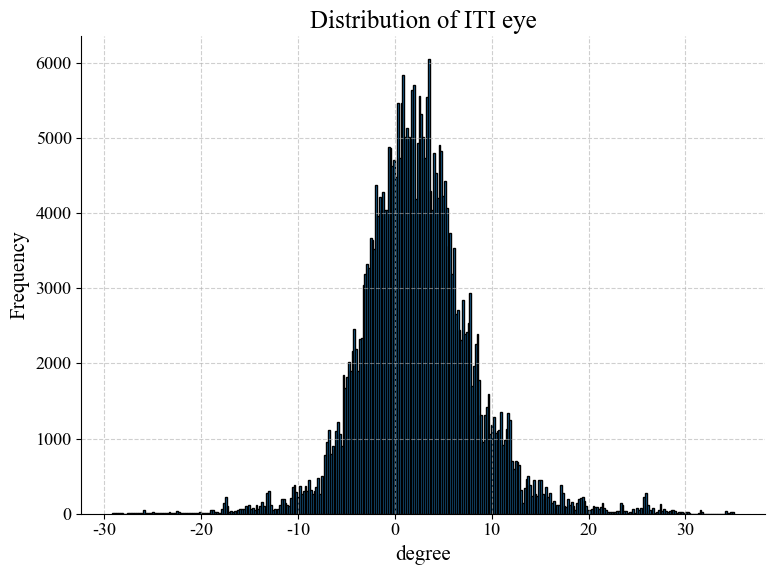

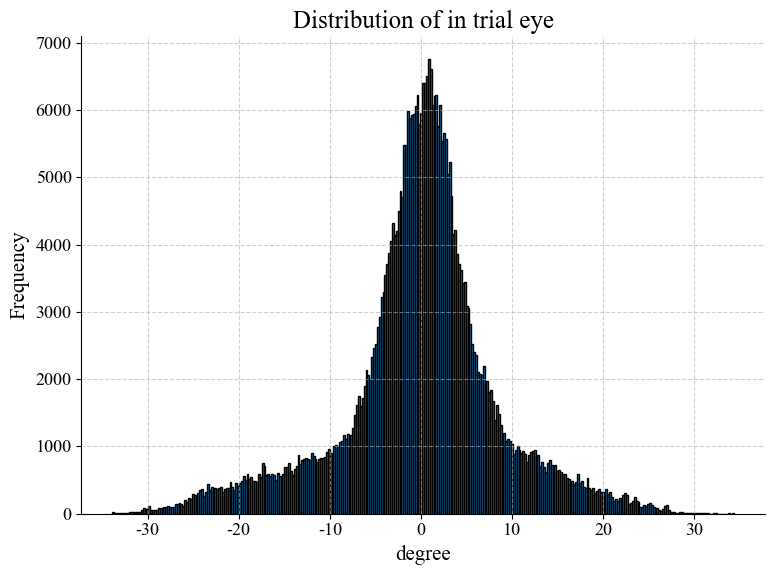

In [55]:
import numpy as np
import matplotlib.pyplot as plt

def plot_distribution(arr, title="Distribution Plot", xlabel="degree", ylabel="Frequency"):
  """
  Plots the distribution (histogram) of a NumPy array.

  Args:
    arr: A NumPy array.
    title: The title of the plot (default: "Distribution Plot").
    xlabel: The label for the x-axis (default: "Value").
    ylabel: The label for the y-axis (default: "Frequency").
  """
  if not isinstance(arr, np.ndarray):
    print("Input must be a NumPy array.")
    return

  if arr.size == 0:
    print("The array is empty, cannot plot distribution.")
    return

  plt.figure(figsize=(8, 6))
  plt.hist(arr, bins='auto', edgecolor='black')  # 'auto' determines the number of bins automatically
  plt.title(title)
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.grid(True, linestyle='--', alpha=0.6)
  plt.tight_layout()
  plt.show()


iti, standard=timeitidf.eye.to_numpy(), timedf.eye.to_numpy()




plot_distribution(iti, title="Distribution of ITI eye")

plot_distribution(standard, title="Distribution of in trial eye")


IIT eye are narrower. possibly looking forward to the next target. 

## previous CCA result

(-9.143009205206905, 7.03181253454237, -4.300880169868469, 4.3943640947341915)

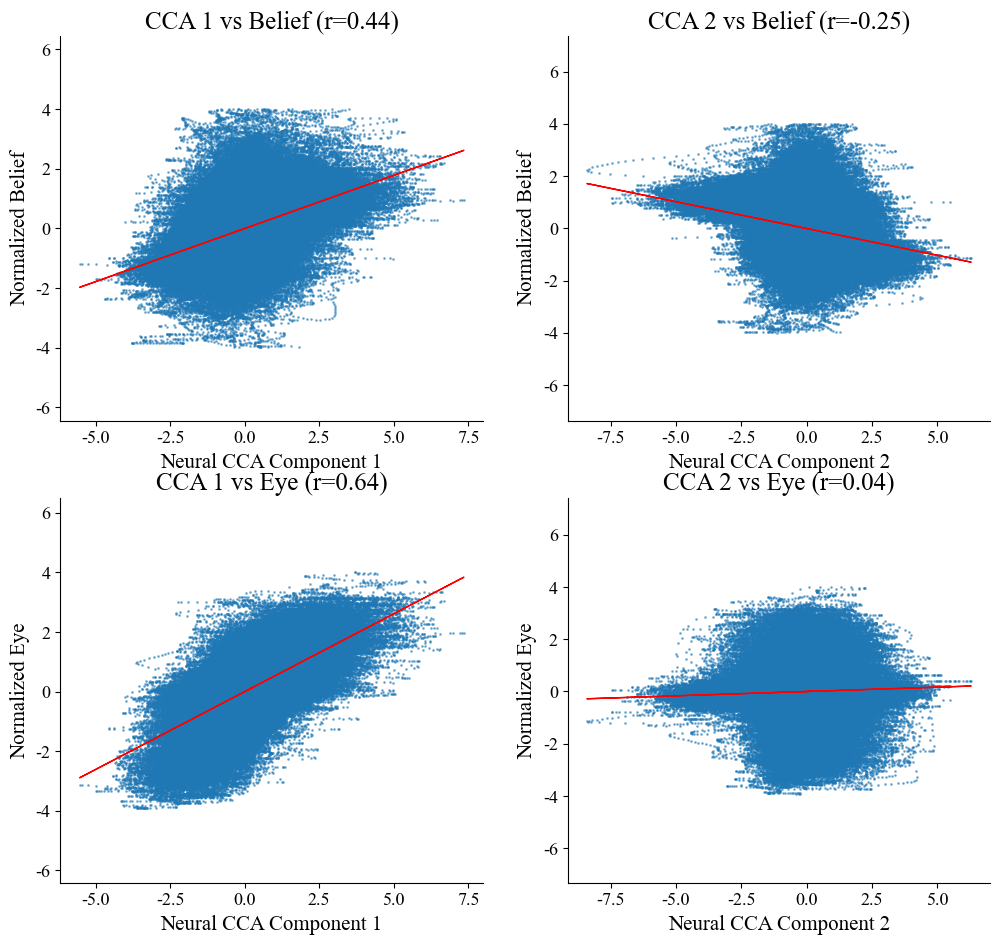

In [62]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import CCA
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def normalize_z(data):
    scaler = StandardScaler()
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

def plot_best_fit(x, y, ax):
    m, c = np.polyfit(x, y, 1)
    ax.plot(x, m*x + c, color='red', linewidth=1)



thisdf=timedf
condition='all'

neural_data=np.stack(thisdf.PPC.to_numpy())
rawtaskvar=[(thisdf.belief.to_numpy()),
        (thisdf.eye.to_numpy()),
        ]
# normalize to 0 mean 1 std
rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
related_taskvar=np.vstack(rawtaskvar).T

# related_taskvar=np.clip(related_taskvar,-4,4)
mask=(related_taskvar > -4) & (related_taskvar < 4)
mask=(mask[:,0] & mask[:,1])
# 1, set outlier to 0 (assumption, outlier is missing data, assign mean to them)
# related_taskvar[~mask]=0
# 2, remove outliers (no assumption)
related_taskvar=related_taskvar[mask]
neural_data=neural_data[mask]

# ---------------------- Multivariate Linear Regression ----------------------
model = LinearRegression()
model.fit(neural_data, related_taskvar)

belief_encoding_vector = model.coef_[0, :] # Coefficients for belief
eye_encoding_vector = model.coef_[1, :]    # Coefficients for eye

# Analyze the relationship between the encoding vectors
belief_norm = np.linalg.norm(belief_encoding_vector)
eye_norm = np.linalg.norm(eye_encoding_vector)

if belief_norm > 0 and eye_norm > 0:
    dot_product = np.dot(belief_encoding_vector, eye_encoding_vector)
    cos_theta = dot_product / (belief_norm * eye_norm)
    angle_rad = np.arccos(np.clip(cos_theta, -1.0, 1.0))
    angle_deg = np.degrees(angle_rad)
else:
    cos_theta = np.nan
    angle_deg = np.nan

# Shared component (projection)
if eye_norm > 0:
    belief_shared_on_eye = (dot_product / (eye_norm ** 2)) * eye_encoding_vector
else:
    belief_shared_on_eye = np.zeros_like(belief_encoding_vector)

if belief_norm > 0:
    eye_shared_on_belief = (dot_product / (belief_norm ** 2)) * belief_encoding_vector
else:
    eye_shared_on_belief = np.zeros_like(eye_encoding_vector)

# Distinct component (orthogonal part)
belief_distinct = belief_encoding_vector - belief_shared_on_eye
eye_distinct = eye_encoding_vector - eye_shared_on_belief

# ---------------------- CCA Analysis (for comparison) ----------------------
n_components = 2
cca = CCA(n_components=n_components)
cca.fit(neural_data, related_taskvar)
cca_neural, cca_be=cca.transform(neural_data, related_taskvar)

# Apply PCA to neural data
pca_neural = PCA(n_components=2)
neural_pca_result = pca_neural.fit_transform(neural_data)

# ---------------------- Visualization ----------------------
fig, axs = plt.subplots(2, 2, figsize=(12, 11)) # Adjusted figure size

# CCA Plots (as before)
ax = axs[0, 0]
thisx, thisy = cca_neural[:, 0], related_taskvar[:, 0]
plot_best_fit(thisx, thisy, ax)
r, _ = pearsonr(thisx, thisy)
ax.set_title(f'CCA 1 vs Belief (r={r:.2f})')
ax.scatter(thisx, thisy, s=1, alpha=0.5)
ax.set_xlabel('Neural CCA Component 1')
ax.set_ylabel('Normalized Belief')
ax.axis('equal')

ax = axs[0, 1]
thisx, thisy = cca_neural[:, 1], related_taskvar[:, 0]
plot_best_fit(thisx, thisy, ax)
r, _ = pearsonr(thisx, thisy)
ax.set_title(f'CCA 2 vs Belief (r={r:.2f})')
ax.scatter(thisx, thisy, s=1, alpha=0.5)
ax.set_xlabel('Neural CCA Component 2')
ax.set_ylabel('Normalized Belief')
ax.axis('equal')

ax = axs[1, 0]
thisx, thisy = cca_neural[:, 0], related_taskvar[:, 1]
plot_best_fit(thisx, thisy, ax)
r, _ = pearsonr(thisx, thisy)
ax.set_title(f'CCA 1 vs Eye (r={r:.2f})')
ax.scatter(thisx, thisy, s=1, alpha=0.5)
ax.set_xlabel('Neural CCA Component 1')
ax.set_ylabel('Normalized Eye')
ax.axis('equal')

ax = axs[1, 1]
thisx, thisy = cca_neural[:, 1], related_taskvar[:, 1]
plot_best_fit(thisx, thisy, ax)
r, _ = pearsonr(thisx, thisy)
ax.set_title(f'CCA 2 vs Eye (r={r:.2f})')
ax.scatter(thisx, thisy, s=1, alpha=0.5)
ax.set_xlabel('Neural CCA Component 2')
ax.set_ylabel('Normalized Eye')
ax.axis('equal')


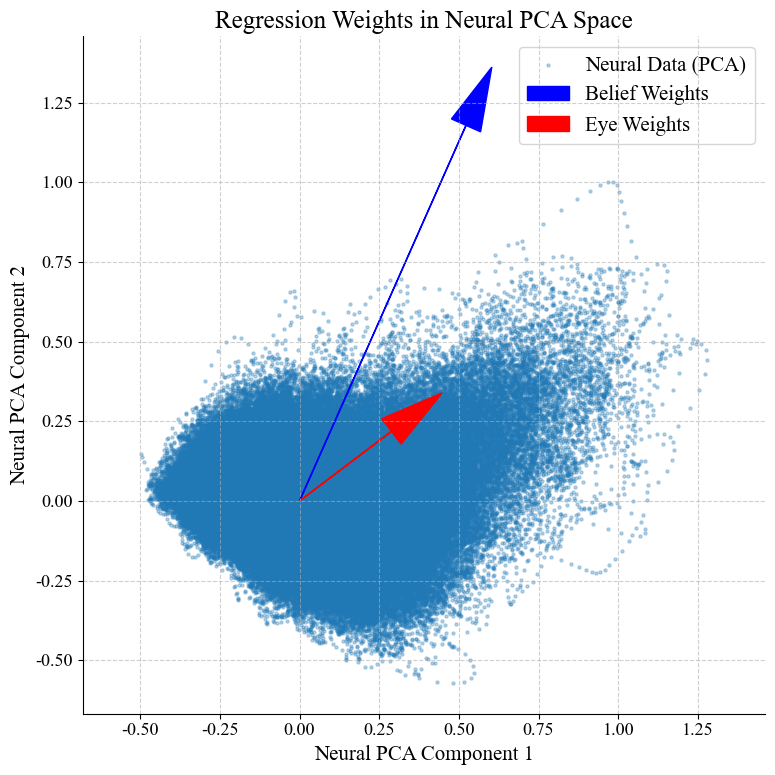

Belief weights in PCA space: [0.52233875 1.179259  ]
Eye weights in PCA space: [0.2883963  0.21866105]
Explained variance ratio of Neural PCA: [0.08752033 0.03604565]


In [61]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import CCA
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def normalize_z(data):
    scaler = StandardScaler()
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

def plot_best_fit(x, y, ax):
    m, c = np.polyfit(x, y, 1)
    ax.plot(x, m*x + c, color='red', linewidth=1)



thisdf=timedf
condition='all'

neural_data=np.stack(thisdf.PPC.to_numpy())
rawtaskvar=[(thisdf.belief.to_numpy()),
        (thisdf.eye.to_numpy()),
        ]
# normalize to 0 mean 1 std
rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
related_taskvar=np.vstack(rawtaskvar).T

# related_taskvar=np.clip(related_taskvar,-4,4)
mask=(related_taskvar > -4) & (related_taskvar < 4)
mask=(mask[:,0] & mask[:,1])
# 1, set outlier to 0 (assumption, outlier is missing data, assign mean to them)
related_taskvar=related_taskvar[mask]
neural_data=neural_data[mask]

# ---------------------- Multivariate Linear Regression ----------------------
model = LinearRegression()
model.fit(neural_data, related_taskvar)

belief_encoding_vector = model.coef_[0, :] # Coefficients for belief
eye_encoding_vector = model.coef_[1, :]    # Coefficients for eye

# ---------------------- CCA Analysis (for comparison) ----------------------
n_components = 2
cca = CCA(n_components=n_components)
cca.fit(neural_data, related_taskvar)
cca_neural, cca_be=cca.transform(neural_data, related_taskvar)

# Apply PCA to neural data
pca_neural = PCA(n_components=2)
neural_pca_result = pca_neural.fit_transform(neural_data)

# Project the encoding vectors onto the PCA space of neural data
belief_weights_pca = belief_encoding_vector @ pca_neural.components_.T
eye_weights_pca = eye_encoding_vector @ pca_neural.components_.T

# ---------------------- New Figure for Weight Vectors in PCA Space ----------------------
fig_weights_pca, ax_weights_pca = plt.subplots(1, 1, figsize=(8, 8))

# Plot the neural data in PCA space as background
ax_weights_pca.scatter(neural_pca_result[:, 0], neural_pca_result[:, 1], s=5, alpha=0.3, label='Neural Data (PCA)')

# Plot the belief weight vector
ax_weights_pca.arrow(0, 0, belief_weights_pca[0], belief_weights_pca[1], head_width=0.1, head_length=0.2, fc='blue', ec='blue', label='Belief Weights')

# Plot the eye weight vector
ax_weights_pca.arrow(0, 0, eye_weights_pca[0], eye_weights_pca[1], head_width=0.1, head_length=0.2, fc='red', ec='red', label='Eye Weights')

ax_weights_pca.set_xlabel('Neural PCA Component 1')
ax_weights_pca.set_ylabel('Neural PCA Component 2')
ax_weights_pca.set_title('Regression Weights in Neural PCA Space')
ax_weights_pca.legend()
ax_weights_pca.axis('equal')
ax_weights_pca.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Belief weights in PCA space: {belief_weights_pca}")
print(f"Eye weights in PCA space: {eye_weights_pca}")
print("Explained variance ratio of Neural PCA:", pca_neural.explained_variance_ratio_)

# The other figures will still be shown if they weren't closed.

--- Processing Original Data (timedf) ---
Original data shape after outlier removal: Neural=(42522, 112), Task=(42522, 2)
Original Belief weights in PCA space: [-0.24057266 -0.22892487]
Original Eye weights in PCA space: [-1.5547422   0.22050695]
Explained variance ratio of Original Neural PCA: [0.07392169 0.03551699]

--- Processing New Data (timeitidf) ---
New data shape after outlier removal: Neural=(187744, 112), Task=(187744, 1)
New Eye weights in PCA space: [-1.5702459 -1.0805109]
Explained variance ratio of New Neural PCA: [0.06328423 0.03435256]


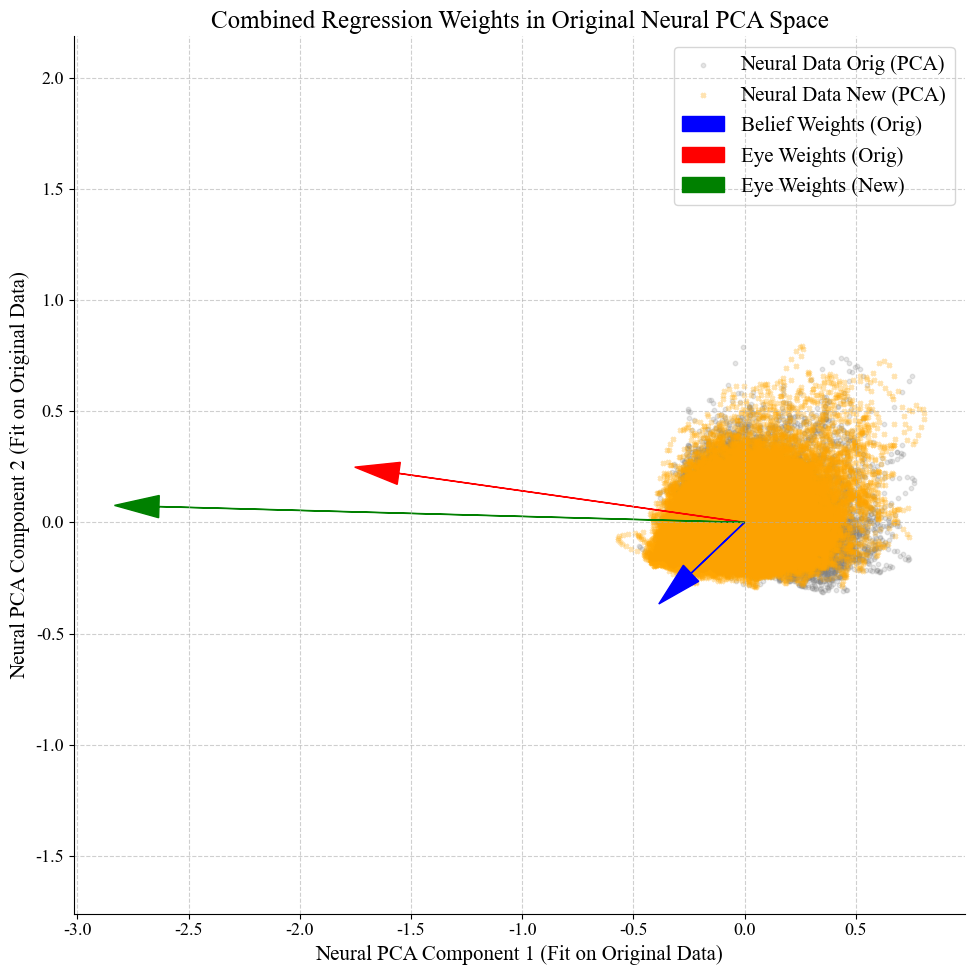

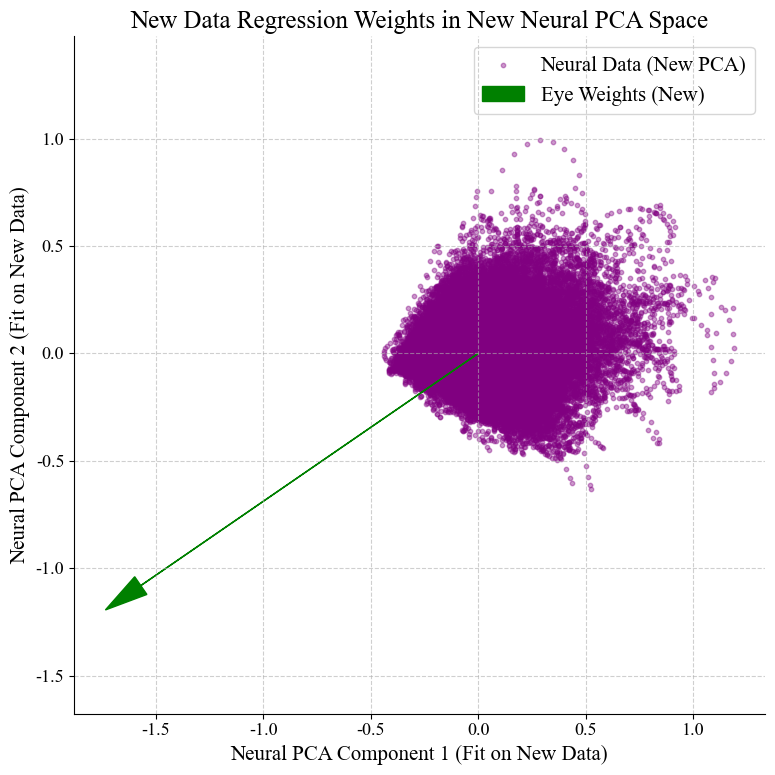

In [63]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
# from sklearn.cross_decomposition import CCA # CCA not needed for the requested plots
# from scipy.stats import pearsonr # pearsonr not needed for the requested plots
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA



def normalize_z(data):
    # Check if data is already numpy array, if not convert it
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    scaler = StandardScaler()
    # Reshape needed for scaler even with 1D array
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

def plot_best_fit(x, y, ax): # This function isn't used in the PCA plots, but kept for potential other uses
    m, c = np.polyfit(x, y, 1)
    ax.plot(x, m*x + c, color='red', linewidth=1)

# =============================================================================
# Process Original Data ('timedf')
# =============================================================================
print("--- Processing Original Data (timedf) ---")
thisdf_orig = timedf
condition_orig = 'all' # Or specific condition if needed

neural_data_orig = np.stack(thisdf_orig.PPC.to_numpy())
rawtaskvar_orig = [
    (thisdf_orig.belief.to_numpy()),
    (thisdf_orig.eye.to_numpy()),
]
# normalize to 0 mean 1 std - already done for placeholder data
# If your real data isn't pre-normalized, uncomment the next line
# rawtaskvar_orig = [np.array(normalize_z(y)) for y in rawtaskvar_orig]
related_taskvar_orig = np.vstack(rawtaskvar_orig).T

# Outlier removal
mask_orig = (related_taskvar_orig > -4) & (related_taskvar_orig < 4)
mask_orig = (mask_orig[:, 0] & mask_orig[:, 1])
related_taskvar_orig = related_taskvar_orig[mask_orig]
neural_data_orig = neural_data_orig[mask_orig]
print(f"Original data shape after outlier removal: Neural={neural_data_orig.shape}, Task={related_taskvar_orig.shape}")


# --- Multivariate Linear Regression (Original) ---
model_orig = LinearRegression()
model_orig.fit(neural_data_orig, related_taskvar_orig)

belief_encoding_vector_orig = model_orig.coef_[0, :] # Coefficients for belief
eye_encoding_vector_orig = model_orig.coef_[1, :]    # Coefficients for eye

# --- PCA Analysis (Original Neural Data) ---
pca_neural_orig = PCA(n_components=2)
neural_pca_result_orig = pca_neural_orig.fit_transform(neural_data_orig)

# --- Project Original Encoding Vectors onto Original PCA Space ---
belief_weights_pca_orig = belief_encoding_vector_orig @ pca_neural_orig.components_.T
eye_weights_pca_orig = eye_encoding_vector_orig @ pca_neural_orig.components_.T

print(f"Original Belief weights in PCA space: {belief_weights_pca_orig}")
print(f"Original Eye weights in PCA space: {eye_weights_pca_orig}")
print("Explained variance ratio of Original Neural PCA:", pca_neural_orig.explained_variance_ratio_)


# =============================================================================
# Process New Data ('timeitidf') - Only Eye Variable
# =============================================================================
print("\n--- Processing New Data (timeitidf) ---")
thisdf_new = timeitidf
condition_new = 'eye_only' # Descriptive name

neural_data_new = np.stack(thisdf_new.PPC.to_numpy())
rawtaskvar_new = [ # Only eye data
    (thisdf_new.eye.to_numpy()),
]
# normalize to 0 mean 1 std - already done for placeholder data
# If your real data isn't pre-normalized, uncomment the next line
# rawtaskvar_new = [np.array(normalize_z(y)) for y in rawtaskvar_new]
related_taskvar_new = np.vstack(rawtaskvar_new).T # Shape will be (n_samples, 1)

# Outlier removal (only checking the eye column)
mask_new = (related_taskvar_new > -4) & (related_taskvar_new < 4)
mask_new = mask_new[:, 0] # Flatten mask since only one column
related_taskvar_new = related_taskvar_new[mask_new]
neural_data_new = neural_data_new[mask_new]
print(f"New data shape after outlier removal: Neural={neural_data_new.shape}, Task={related_taskvar_new.shape}")


# --- Linear Regression (New Data - Predicting Eye Only) ---
model_new = LinearRegression()
# Fit neural data to predict the single eye variable
model_new.fit(neural_data_new, related_taskvar_new)

# model.coef_ will be shape (1, n_features) since only one target variable
eye_encoding_vector_new = model_new.coef_[0, :]

# --- PCA Analysis (New Neural Data) ---
pca_neural_new = PCA(n_components=2)
neural_pca_result_new = pca_neural_new.fit_transform(neural_data_new)

# --- Project New Eye Encoding Vector onto New PCA Space ---
# Project using the PCA components derived *from the new neural data*
eye_weights_pca_new = eye_encoding_vector_new @ pca_neural_new.components_.T

print(f"New Eye weights in PCA space: {eye_weights_pca_new}")
print("Explained variance ratio of New Neural PCA:", pca_neural_new.explained_variance_ratio_)


# =============================================================================
# Plotting
# =============================================================================

# --- Plot 1: Combined Data in Original PCA Space ---
# Note: Projecting the new vector onto the *original* PCA space for direct comparison
#       This assumes the neural *feature space* is comparable.
#       If the underlying features/neurons measured are different, this comparison might be less meaningful.
# Project the new eye vector onto the *original* PCA basis for the combined plot
eye_weights_pca_new_on_orig_pca = eye_encoding_vector_new @ pca_neural_orig.components_.T

fig_combined, ax_combined = plt.subplots(1, 1, figsize=(10, 10))

# Plot original neural data in PCA space
ax_combined.scatter(neural_pca_result_orig[:, 0], neural_pca_result_orig[:, 1],
                    s=10, alpha=0.2, label='Neural Data Orig (PCA)', color='grey')

# Plot new neural data projected onto *original* PCA space
# We need to transform the new neural data using the *original* PCA fit
neural_pca_result_new_on_orig_pca = pca_neural_orig.transform(neural_data_new)
ax_combined.scatter(neural_pca_result_new_on_orig_pca[:, 0], neural_pca_result_new_on_orig_pca[:, 1],
                    s=10, alpha=0.3, label='Neural Data New (PCA)', color='orange', marker='x')


# Plot original belief weight vector
ax_combined.arrow(0, 0, belief_weights_pca_orig[0], belief_weights_pca_orig[1],
                  head_width=0.1, head_length=0.2, fc='blue', ec='blue', label='Belief Weights (Orig)')

# Plot original eye weight vector
ax_combined.arrow(0, 0, eye_weights_pca_orig[0], eye_weights_pca_orig[1],
                  head_width=0.1, head_length=0.2, fc='red', ec='red', label='Eye Weights (Orig)')

# Plot new eye weight vector (projected onto original PCA space)
ax_combined.arrow(0, 0, eye_weights_pca_new_on_orig_pca[0], eye_weights_pca_new_on_orig_pca[1],
                  head_width=0.1, head_length=0.2, fc='green', ec='green', label='Eye Weights (New)')

ax_combined.set_xlabel('Neural PCA Component 1 (Fit on Original Data)')
ax_combined.set_ylabel('Neural PCA Component 2 (Fit on Original Data)')
ax_combined.set_title('Combined Regression Weights in Original Neural PCA Space')
ax_combined.legend()
ax_combined.axis('equal')
ax_combined.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()


# --- Plot 2: Separate Plot for New Data Only in its Own PCA Space ---
fig_new_only, ax_new_only = plt.subplots(1, 1, figsize=(8, 8))

# Plot the new neural data in its *own* PCA space
ax_new_only.scatter(neural_pca_result_new[:, 0], neural_pca_result_new[:, 1],
                    s=10, alpha=0.4, label='Neural Data (New PCA)', color='purple')

# Plot the new eye weight vector in its *own* PCA space
ax_new_only.arrow(0, 0, eye_weights_pca_new[0], eye_weights_pca_new[1],
                  head_width=0.1, head_length=0.2, fc='green', ec='green', label='Eye Weights (New)')

ax_new_only.set_xlabel('Neural PCA Component 1 (Fit on New Data)')
ax_new_only.set_ylabel('Neural PCA Component 2 (Fit on New Data)')
ax_new_only.set_title('New Data Regression Weights in New Neural PCA Space')
ax_new_only.legend()
ax_new_only.axis('equal')
ax_new_only.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Show all plots
plt.show()

## Belief in ITI
we expect to see a narrower or noisier belief in ITI, since its not encoding anything during iti.

--- Processing timedf (Belief Present) ---
Present data shape after outlier removal: Neural=(42522, 112), Task=(42522, 2)
Belief vector norm: 18.34
Eye (present) vector norm: 21.92

--- Processing timeitidf (Belief NaN / Eye Only) ---
NaN data shape after outlier removal: Neural=(187744, 112), Task=(187744,)
Eye (NaN) vector norm: 13.42

--- Comparing Eye Vectors ---
Cosine Similarity between Eye vectors (Present vs NaN): 0.389

--- Calculating Projections onto Belief Axis ---
Correlation(Projection_Present, Actual Belief): r=0.231, p=0.00e+00
Generating Plot 1: Distribution of Projections...
Generating Plot 2: PCA Comparison...


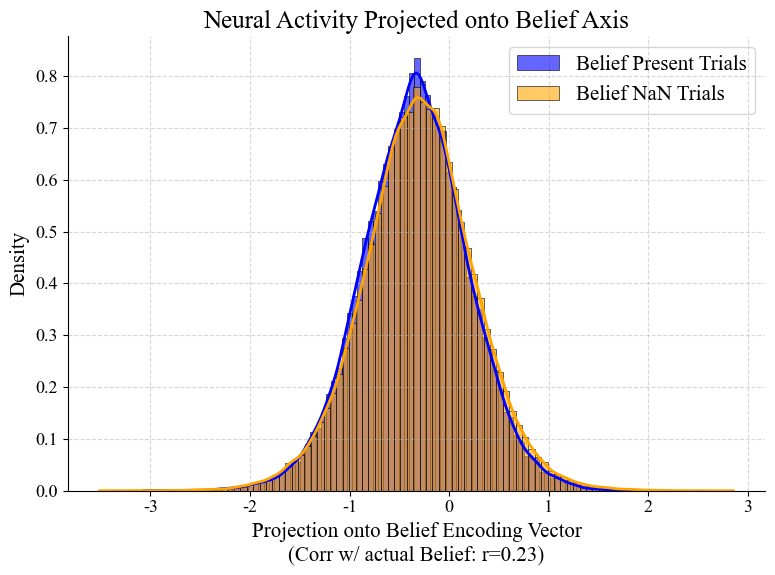

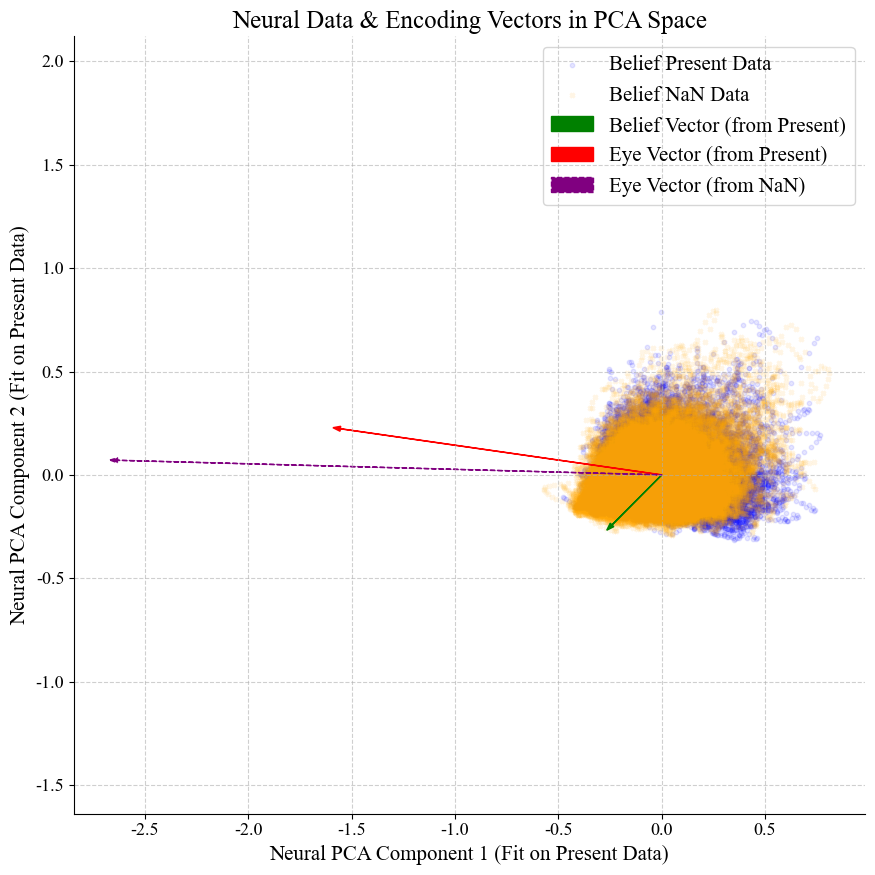


Analysis Complete.


In [66]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns # Using seaborn for nicer distribution plots


def normalize_z(data):
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    scaler = StandardScaler()
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

# =============================================================================
# 1. Process `timedf` (Belief Present)
# =============================================================================
print("--- Processing timedf (Belief Present) ---")
neural_data_present_raw = np.stack(timedf['PPC'].to_numpy())
belief_data_present_raw = timedf['belief'].to_numpy() # Assume already normalized if needed, or normalize here
eye_data_present_raw = timedf['eye'].to_numpy()     # Assume already normalized if needed, or normalize here

task_vars_present_raw = np.vstack([belief_data_present_raw, eye_data_present_raw]).T

# Outlier removal (based on belief and eye)
mask_present = (np.abs(task_vars_present_raw) < 4).all(axis=1) # Check within +/- 4 std dev for both
neural_data_present = neural_data_present_raw[mask_present, :]
task_vars_present = task_vars_present_raw[mask_present, :]
belief_data_present = task_vars_present[:, 0]
eye_data_present = task_vars_present[:, 1]
print(f"Present data shape after outlier removal: Neural={neural_data_present.shape}, Task={task_vars_present.shape}")


# Fit multivariate regression model
model_present = LinearRegression()
model_present.fit(neural_data_present, task_vars_present)

belief_encoding_vector_present = model_present.coef_[0, :]
eye_encoding_vector_present = model_present.coef_[1, :]
print(f"Belief vector norm: {np.linalg.norm(belief_encoding_vector_present):.2f}")
print(f"Eye (present) vector norm: {np.linalg.norm(eye_encoding_vector_present):.2f}")

# =============================================================================
# 2. Process `timeitidf` (Belief NaN / Eye Only)
# =============================================================================
print("\n--- Processing timeitidf (Belief NaN / Eye Only) ---")
neural_data_nan_raw = np.stack(timeitidf['PPC'].to_numpy())
eye_data_nan_raw = timeitidf['eye'].to_numpy() # Assume already normalized if needed, or normalize here

# Outlier removal (based on eye only)
mask_nan = np.abs(eye_data_nan_raw) < 4
neural_data_nan = neural_data_nan_raw[mask_nan, :]
eye_data_nan = eye_data_nan_raw[mask_nan] # Now a 1D array
print(f"NaN data shape after outlier removal: Neural={neural_data_nan.shape}, Task={eye_data_nan.shape}")


# Fit regression model for eye only
model_nan = LinearRegression()
model_nan.fit(neural_data_nan, eye_data_nan) # Target is 1D

# Coefficient will be 1D since target is 1D
eye_encoding_vector_nan = model_nan.coef_
print(f"Eye (NaN) vector norm: {np.linalg.norm(eye_encoding_vector_nan):.2f}")


# =============================================================================
# 3. Compare Eye Encoding Vectors
# =============================================================================
print("\n--- Comparing Eye Vectors ---")
# Ensure vectors are 2D for cosine_similarity
eye_vec_present_2d = eye_encoding_vector_present.reshape(1, -1)
eye_vec_nan_2d = eye_encoding_vector_nan.reshape(1, -1)

similarity = cosine_similarity(eye_vec_present_2d, eye_vec_nan_2d)[0, 0]
print(f"Cosine Similarity between Eye vectors (Present vs NaN): {similarity:.3f}")
# High similarity suggests eye encoding is stable regardless of belief presence


# =============================================================================
# 4. Calculate Projections onto Belief Encoding Vector
# =============================================================================
print("\n--- Calculating Projections onto Belief Axis ---")
# Project the VALID (outlier-removed) neural data onto the belief vector derived from present data
projection_present_onto_belief = neural_data_present @ belief_encoding_vector_present
projection_nan_onto_belief = neural_data_nan @ belief_encoding_vector_present

# Check correlation between projection and actual belief values for present data
r_belief, p_belief = pearsonr(projection_present_onto_belief, belief_data_present)
print(f"Correlation(Projection_Present, Actual Belief): r={r_belief:.3f}, p={p_belief:.2e}")


# =============================================================================
# 5. Generate Plots
# =============================================================================

# --- Plot 1: Distribution of Projections onto Belief Axis ---
print("Generating Plot 1: Distribution of Projections...")
fig1, ax1 = plt.subplots(figsize=(8, 6))
sns.histplot(projection_present_onto_belief, color='blue', label='Belief Present Trials', ax=ax1, stat='density', bins=99, alpha=0.6, kde=True)
sns.histplot(projection_nan_onto_belief, color='orange', label='Belief NaN Trials', ax=ax1, stat='density', bins=99, alpha=0.6, kde=True)
ax1.set_xlabel(f'Projection onto Belief Encoding Vector\n(Corr w/ actual Belief: r={r_belief:.2f})')
ax1.set_ylabel('Density')
ax1.set_title('Neural Activity Projected onto Belief Axis')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# --- Plot 2: PCA Space Comparison ---
print("Generating Plot 2: PCA Comparison...")
# Fit PCA on the present data (contains both signals)
pca_present = PCA(n_components=2)
neural_pca_present = pca_present.fit_transform(neural_data_present)

# Transform the NaN data using the *same* PCA fit
neural_pca_nan = pca_present.transform(neural_data_nan)

# Project encoding vectors onto this PCA space
belief_weights_pca = belief_encoding_vector_present @ pca_present.components_.T
eye_weights_pca_present = eye_encoding_vector_present @ pca_present.components_.T
eye_weights_pca_nan = eye_encoding_vector_nan @ pca_present.components_.T # Project nan-derived vector too

# Create plot
fig2, ax2 = plt.subplots(figsize=(9, 9))

# Scatter plot the data points
ax2.scatter(neural_pca_present[:, 0], neural_pca_present[:, 1], s=10, alpha=0.1, label='Belief Present Data', color='blue')
ax2.scatter(neural_pca_nan[:, 0], neural_pca_nan[:, 1], s=10, alpha=0.1, label='Belief NaN Data', color='orange', marker='x')

# Plot the encoding vectors as arrows
arrow_scale = max(np.abs(neural_pca_present).max(), np.abs(neural_pca_nan).max()) * 0.15 # Heuristic scaling

ax2.arrow(0, 0, belief_weights_pca[0], belief_weights_pca[1],
          head_width=arrow_scale*0.2, head_length=arrow_scale*0.3, fc='green', ec='green', label='Belief Vector (from Present)')
ax2.arrow(0, 0, eye_weights_pca_present[0], eye_weights_pca_present[1],
          head_width=arrow_scale*0.2, head_length=arrow_scale*0.3, fc='red', ec='red', label='Eye Vector (from Present)')
ax2.arrow(0, 0, eye_weights_pca_nan[0], eye_weights_pca_nan[1],
          head_width=arrow_scale*0.2, head_length=arrow_scale*0.3, fc='purple', ec='purple', linestyle='--', label='Eye Vector (from NaN)')

ax2.set_xlabel('Neural PCA Component 1 (Fit on Present Data)')
ax2.set_ylabel('Neural PCA Component 2 (Fit on Present Data)')
ax2.set_title('Neural Data & Encoding Vectors in PCA Space')
ax2.legend()
ax2.axis('equal')
ax2.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()


# Show plots
plt.show()

print("\nAnalysis Complete.")

in the pca space, we hope to see the orange dots to be narrower in the belief axis (since there is no belief in iti). or maybe not. belief is nan, doesnt mean its should be a fixed value. 

we also see that the eye vector is slightly different from trial and iti data. belief could play a role here? eg, neural encode belief--eye, and enncoding of belief helps decoding the eye in trial. but not in iti.


--- Strategy 1 Follow-up: Checking Decoded Belief vs Eye in NaN Data ---
Correlation(Decoded Belief [NaN Period], Actual Eye [NaN Period]): r=0.127, p=0.00e+00


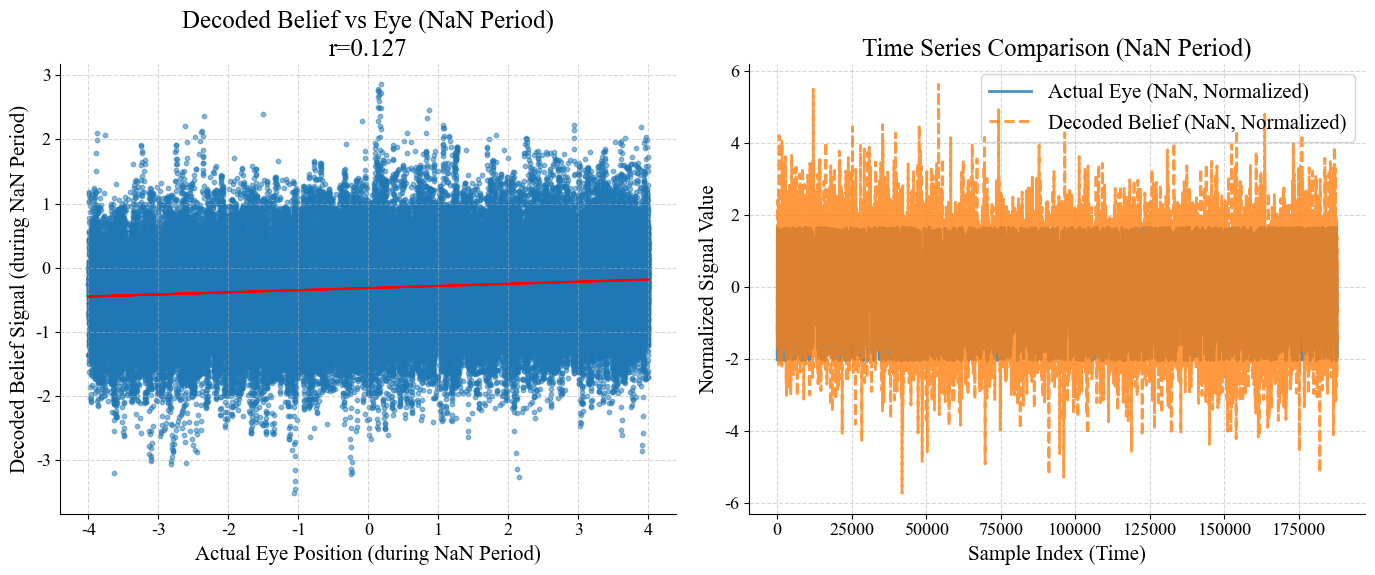

In [67]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

# --- Assume previous code sections have run ---
# Including:
# - Loading/Creating timedf and timeitidf
# - normalize_z function
# - Processing timedf to get:
#   - neural_data_present
#   - belief_data_present
#   - eye_data_present
#   - belief_encoding_vector_present
#   - eye_encoding_vector_present
# - Processing timeitidf to get:
#   - neural_data_nan
#   - eye_data_nan
#   - eye_encoding_vector_nan
# --- End Assumptions ---


# =============================================================================
# Strategy 1 Follow-up: Check Decoded Belief vs Eye in NaN Data
# =============================================================================
print("\n--- Strategy 1 Follow-up: Checking Decoded Belief vs Eye in NaN Data ---")

# 1. Apply the 'Belief Decoder' (belief_encoding_vector_present) to the NaN neural data
#    This gives us the predicted belief signal during the NaN period.
decoded_belief_nan = neural_data_nan @ belief_encoding_vector_present

# 2. Check the correlation between this decoded belief and the actual eye movements
#    during the NaN period.
r_decoded_belief_vs_eye_nan, p_decoded_belief_vs_eye_nan = pearsonr(decoded_belief_nan, eye_data_nan)

print(f"Correlation(Decoded Belief [NaN Period], Actual Eye [NaN Period]): r={r_decoded_belief_vs_eye_nan:.3f}, p={p_decoded_belief_vs_eye_nan:.2e}")

# 3. Visualize this relationship
fig_followup, (ax_scatter, ax_time) = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot
ax_scatter.scatter(eye_data_nan, decoded_belief_nan, alpha=0.5, s=10)
# Add line of best fit to visualize trend
m, c = np.polyfit(eye_data_nan, decoded_belief_nan, 1)
ax_scatter.plot(eye_data_nan, m*eye_data_nan + c, color='red', linewidth=1.5)
ax_scatter.set_xlabel('Actual Eye Position (during NaN Period)')
ax_scatter.set_ylabel('Decoded Belief Signal (during NaN Period)')
ax_scatter.set_title(f'Decoded Belief vs Eye (NaN Period)\nr={r_decoded_belief_vs_eye_nan:.3f}')
ax_scatter.grid(True, linestyle='--', alpha=0.5)

# Time series plot (plotting against sample index)
# Normalize for visualization purposes if scales are very different
plot_eye_nan = normalize_z(eye_data_nan) # Use normalize_z for plotting scale
plot_decoded_belief_nan = normalize_z(decoded_belief_nan) # Use normalize_z for plotting scale

time_axis = np.arange(len(plot_eye_nan))
ax_time.plot(time_axis, plot_eye_nan, label='Actual Eye (NaN, Normalized)', alpha=0.8)
ax_time.plot(time_axis, plot_decoded_belief_nan, label='Decoded Belief (NaN, Normalized)', alpha=0.8, linestyle='--')
ax_time.set_xlabel('Sample Index (Time)')
ax_time.set_ylabel('Normalized Signal Value')
ax_time.set_title('Time Series Comparison (NaN Period)')
ax_time.legend()
ax_time.grid(True, linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()


--- Comparison: Checking Decoded Belief vs Eye in PRESENT Data ---
Correlation(Decoded Belief [Present Period], Actual Eye [Present Period]): r=0.081, p=2.74e-62
Correlation(Decoded Belief [Present Period], Actual Belief [Present Period]): r=0.231, p=0.00e+00


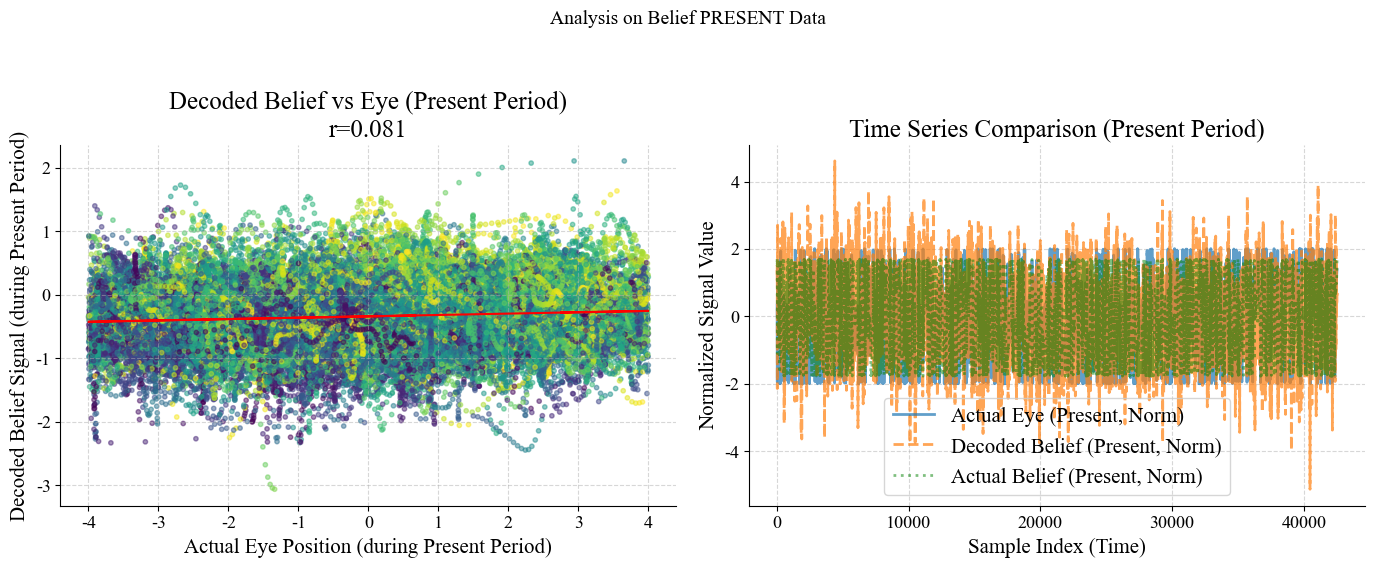

In [71]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

# --- Assume previous code sections have run ---
# Including:
# - Loading/Creating timedf and timeitidf
# - normalize_z function
# - Processing timedf to get:
#   - neural_data_present
#   - belief_data_present
#   - eye_data_present
#   - belief_encoding_vector_present
#   - eye_encoding_vector_present
# - Processing timeitidf to get:
#   - neural_data_nan
#   - eye_data_nan
#   - eye_encoding_vector_nan
# - The "Strategy 1 Follow-up" section calculating:
#   - decoded_belief_nan
#   - r_decoded_belief_vs_eye_nan (which you observed as ~0.12)
#   - fig_followup (plots for NaN data)
# --- End Assumptions ---


# =============================================================================
# Comparison: Check Decoded Belief vs Eye in PRESENT Data
# =============================================================================
print("\n--- Comparison: Checking Decoded Belief vs Eye in PRESENT Data ---")

# 1. Apply the 'Belief Decoder' (belief_encoding_vector_present) to the PRESENT neural data
#    This gives us the predicted belief signal during the period when belief was actually present.
decoded_belief_present = neural_data_present @ belief_encoding_vector_present

# 2. Check the correlation between this decoded belief and the actual eye movements
#    during the PRESENT period.
r_decoded_belief_vs_eye_present, p_decoded_belief_vs_eye_present = pearsonr(decoded_belief_present, eye_data_present)

# Also, let's re-check the correlation between decoded belief and *actual* belief in the present data
# This should be the same as r_belief calculated earlier, but good to have here for comparison context.
r_decoded_belief_vs_actual_belief, p_decoded_belief_vs_actual_belief = pearsonr(decoded_belief_present, belief_data_present)


print(f"Correlation(Decoded Belief [Present Period], Actual Eye [Present Period]): r={r_decoded_belief_vs_eye_present:.3f}, p={p_decoded_belief_vs_eye_present:.2e}")
print(f"Correlation(Decoded Belief [Present Period], Actual Belief [Present Period]): r={r_decoded_belief_vs_actual_belief:.3f}, p={p_decoded_belief_vs_actual_belief:.2e}")


# 3. Visualize this relationship for the PRESENT data
fig_comparison, (ax_scatter_comp, ax_time_comp) = plt.subplots(1, 2, figsize=(14, 6))
fig_comparison.suptitle('Analysis on Belief PRESENT Data', fontsize=14) # Add overall title


# Scatter plot for PRESENT data
ax_scatter_comp.scatter(eye_data_present, decoded_belief_present, alpha=0.5, s=10, c=belief_data_present, cmap='viridis') # Color points by actual belief
# Add line of best fit to visualize trend
m_comp, c_comp = np.polyfit(eye_data_present, decoded_belief_present, 1)
ax_scatter_comp.plot(eye_data_present, m_comp*eye_data_present + c_comp, color='red', linewidth=1.5)
ax_scatter_comp.set_xlabel('Actual Eye Position (during Present Period)')
ax_scatter_comp.set_ylabel('Decoded Belief Signal (during Present Period)')
ax_scatter_comp.set_title(f'Decoded Belief vs Eye (Present Period)\nr={r_decoded_belief_vs_eye_present:.3f}')
ax_scatter_comp.grid(True, linestyle='--', alpha=0.5)
# Optional: Add a colorbar if using color mapping
# cbar = fig_comparison.colorbar(ax_scatter_comp.collections[0], ax=ax_scatter_comp)
# cbar.set_label('Actual Belief Value')


# Time series plot for PRESENT data (plotting against sample index)
# Normalize for visualization purposes if scales are very different
plot_eye_present = normalize_z(eye_data_present) # Use normalize_z for plotting scale
plot_decoded_belief_present = normalize_z(decoded_belief_present) # Use normalize_z for plotting scale
plot_actual_belief_present = normalize_z(belief_data_present) # Normalize actual belief too for comparison

time_axis_present = np.arange(len(plot_eye_present))
ax_time_comp.plot(time_axis_present, plot_eye_present, label='Actual Eye (Present, Norm)', alpha=0.7)
ax_time_comp.plot(time_axis_present, plot_decoded_belief_present, label='Decoded Belief (Present, Norm)', alpha=0.7, linestyle='--')
ax_time_comp.plot(time_axis_present, plot_actual_belief_present, label='Actual Belief (Present, Norm)', alpha=0.5, linestyle=':', color='green') # Plot actual belief as well
ax_time_comp.set_xlabel('Sample Index (Time)')
ax_time_comp.set_ylabel('Normalized Signal Value')
ax_time_comp.set_title('Time Series Comparison (Present Period)')
ax_time_comp.legend()
ax_time_comp.grid(True, linestyle='--', alpha=0.5)


plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

# Regression and residual regression


--- Strategy 2: Partial Regression / Residual Analysis ---

Part A: Analyzing Belief contribution after removing Eye...
Step 1: Fitting model Neural ~ Eye
  R-squared (Eye -> Neural): 0.0025
Step 2: Calculating residuals (Neural activity not explained by Eye)
Step 3: Testing if Residuals (after Eye removed) predict Belief
  R-squared (Residuals [after Eye] -> Belief): 0.0522
  Pearson r (Predicted Belief [from Residuals] vs Actual Belief): 0.2286, p=0.00e+00

Part B: Analyzing Eye contribution after removing Belief (Symmetric Check)...
Step 1: Fitting model Neural ~ Belief
  R-squared (Belief -> Neural): 0.0005
Step 2: Calculating residuals (Neural activity not explained by Belief)
Step 3: Testing if Residuals (after Belief removed) predict Eye
  R-squared (Residuals [after Belief] -> Eye): 0.1610
  Pearson r (Predicted Eye [from Residuals] vs Actual Eye): 0.4013, p=0.00e+00

Generating plot for Part A result...


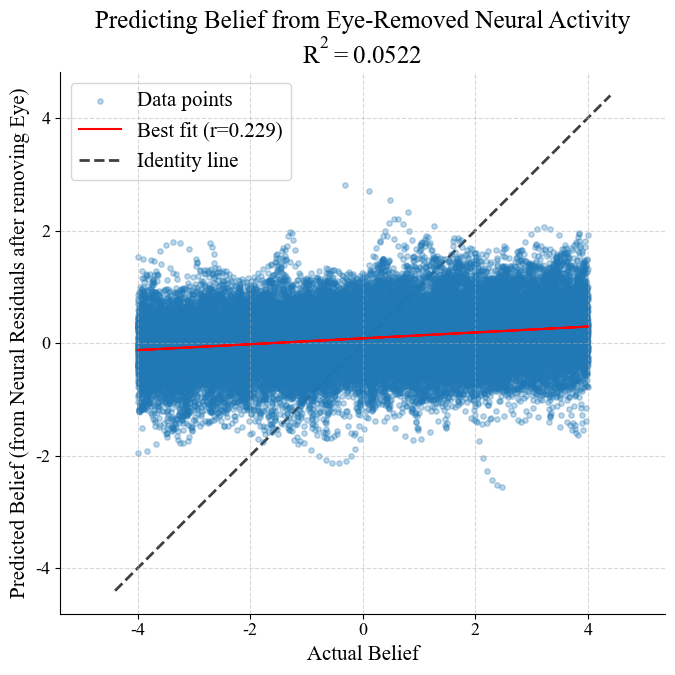


Strategy 2 Analysis Complete.


In [72]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA # Not needed for this strategy
from scipy.stats import pearsonr
# from sklearn.metrics.pairwise import cosine_similarity # Not needed
# import seaborn as sns # Not needed

# --- Assume previous code sections have run ---
# Including:
# - Loading/Creating timedf and timeitidf
# - normalize_z function
# - Processing timedf to get:
#   - neural_data_present (shape: n_samples, n_features)
#   - belief_data_present (shape: n_samples,)
#   - eye_data_present (shape: n_samples,)
# --- End Assumptions ---


# =============================================================================
# Strategy 2: Partial Regression / Residual Analysis
# =============================================================================
print("\n--- Strategy 2: Partial Regression / Residual Analysis ---")

# Reshape predictor variables for LinearRegression (needs 2D input)
eye_data_present_2d = eye_data_present.reshape(-1, 1)
belief_data_present_2d = belief_data_present.reshape(-1, 1)

# --- Part A: Does Belief explain Neural Activity AFTER removing Eye? ---

print("\nPart A: Analyzing Belief contribution after removing Eye...")

# 1. Model Neural activity from Eye position ONLY
print("Step 1: Fitting model Neural ~ Eye")
model_eye_to_neural = LinearRegression()
model_eye_to_neural.fit(eye_data_present_2d, neural_data_present)
r2_eye_only = model_eye_to_neural.score(eye_data_present_2d, neural_data_present)
print(f"  R-squared (Eye -> Neural): {r2_eye_only:.4f}")

# 2. Calculate Residuals (Neural activity not explained by Eye)
print("Step 2: Calculating residuals (Neural activity not explained by Eye)")
predicted_neural_from_eye = model_eye_to_neural.predict(eye_data_present_2d)
neural_residuals_after_eye = neural_data_present - predicted_neural_from_eye

# 3. Can these Residuals predict Belief?
print("Step 3: Testing if Residuals (after Eye removed) predict Belief")
model_residual_to_belief = LinearRegression()
# Fit the eye-removed neural activity to predict the actual belief values
model_residual_to_belief.fit(neural_residuals_after_eye, belief_data_present)

# Evaluate how well the residuals predict belief using R-squared
r2_belief_after_eye = model_residual_to_belief.score(neural_residuals_after_eye, belief_data_present)
print(f"  R-squared (Residuals [after Eye] -> Belief): {r2_belief_after_eye:.4f}")

# Also get Pearson R for comparison with previous r=0.231 value
predicted_belief_from_residuals = model_residual_to_belief.predict(neural_residuals_after_eye)
r_belief_after_eye, p_belief_after_eye = pearsonr(predicted_belief_from_residuals, belief_data_present)
print(f"  Pearson r (Predicted Belief [from Residuals] vs Actual Belief): {r_belief_after_eye:.4f}, p={p_belief_after_eye:.2e}")


# --- Part B: Symmetric Check - Does Eye explain Neural Activity AFTER removing Belief? ---

print("\nPart B: Analyzing Eye contribution after removing Belief (Symmetric Check)...")

# 1. Model Neural activity from Belief ONLY
print("Step 1: Fitting model Neural ~ Belief")
model_belief_to_neural = LinearRegression()
model_belief_to_neural.fit(belief_data_present_2d, neural_data_present)
r2_belief_only = model_belief_to_neural.score(belief_data_present_2d, neural_data_present)
print(f"  R-squared (Belief -> Neural): {r2_belief_only:.4f}")


# 2. Calculate Residuals (Neural activity not explained by Belief)
print("Step 2: Calculating residuals (Neural activity not explained by Belief)")
predicted_neural_from_belief = model_belief_to_neural.predict(belief_data_present_2d)
neural_residuals_after_belief = neural_data_present - predicted_neural_from_belief

# 3. Can these Residuals predict Eye?
print("Step 3: Testing if Residuals (after Belief removed) predict Eye")
model_residual_to_eye = LinearRegression()
# Fit the belief-removed neural activity to predict the actual eye position values
model_residual_to_eye.fit(neural_residuals_after_belief, eye_data_present)

# Evaluate how well the residuals predict eye using R-squared
r2_eye_after_belief = model_residual_to_eye.score(neural_residuals_after_belief, eye_data_present)
print(f"  R-squared (Residuals [after Belief] -> Eye): {r2_eye_after_belief:.4f}")

# Also get Pearson R
predicted_eye_from_residuals = model_residual_to_eye.predict(neural_residuals_after_belief)
r_eye_after_belief, p_eye_after_belief = pearsonr(predicted_eye_from_residuals, eye_data_present)
print(f"  Pearson r (Predicted Eye [from Residuals] vs Actual Eye): {r_eye_after_belief:.4f}, p={p_eye_after_belief:.2e}")


# --- Plotting the key result (Part A) ---
print("\nGenerating plot for Part A result...")
fig_strategy2, ax_strategy2 = plt.subplots(figsize=(7, 7))

ax_strategy2.scatter(belief_data_present, predicted_belief_from_residuals, alpha=0.3, s=15, label='Data points')
# Add line of best fit
m_s2, c_s2 = np.polyfit(belief_data_present, predicted_belief_from_residuals, 1)
ax_strategy2.plot(belief_data_present, m_s2*belief_data_present + c_s2, color='red', linewidth=1.5, label=f'Best fit (r={r_belief_after_eye:.3f})')
# Add identity line (where prediction equals actual)
lims = [min(ax_strategy2.get_xlim()[0], ax_strategy2.get_ylim()[0]),
        max(ax_strategy2.get_xlim()[1], ax_strategy2.get_ylim()[1])]
ax_strategy2.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='Identity line')


ax_strategy2.set_xlabel('Actual Belief')
ax_strategy2.set_ylabel('Predicted Belief (from Neural Residuals after removing Eye)')
ax_strategy2.set_title(f'Predicting Belief from Eye-Removed Neural Activity\n$R^2 = {r2_belief_after_eye:.4f}$')
ax_strategy2.legend()
ax_strategy2.grid(True, linestyle='--', alpha=0.5)
ax_strategy2.axis('equal') # Make axes equal to better judge identity line fit
plt.tight_layout()
plt.show()

print("\nStrategy 2 Analysis Complete.")


--- Strategy 2: Partial Regression / Residual Analysis (with Cross-Validation) ---
Using 5-Fold Cross-Validation

Part A: Analyzing Belief contribution after removing Eye (CV)...
Step 1: Getting CV predictions for Neural ~ Eye
Step 2: Calculating residuals based on CV predictions
Step 3: Testing if CV Residuals (after Eye removed) predict Belief (using CV)
  Cross-Validated R-squared (Residuals [after Eye] -> Belief): 0.0464
  Cross-Validated Pearson r (Actual Belief vs CV Predicted Belief [from Residuals]): 0.2159, p=0.00e+00

Part B: Analyzing Eye contribution after removing Belief (CV)...
Step 1: Getting CV predictions for Neural ~ Belief
Step 2: Calculating residuals based on CV predictions
Step 3: Testing if CV Residuals (after Belief removed) predict Eye (using CV)
  Cross-Validated R-squared (Residuals [after Belief] -> Eye): 0.1562
  Cross-Validated Pearson r (Actual Eye vs CV Predicted Eye [from Residuals]): 0.3953, p=0.00e+00

Generating plot for Part A cross-validated resul

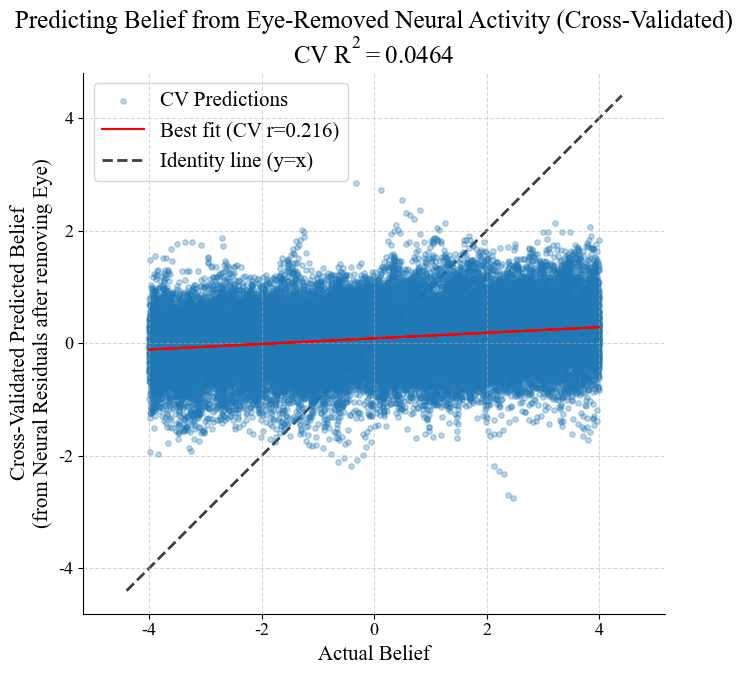


Strategy 2 Analysis with Cross-Validation Complete.


In [74]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score # Use r2_score for evaluating CV predictions




# Helper function (if not already defined)
def normalize_z(data):
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    scaler = StandardScaler()
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

# =============================================================================
# Strategy 2: Partial Regression / Residual Analysis with Cross-Validation
# =============================================================================
print("\n--- Strategy 2: Partial Regression / Residual Analysis (with Cross-Validation) ---")

# Ensure data is in numpy array format
neural_data_present = np.array(neural_data_present)
belief_data_present = np.array(belief_data_present)
eye_data_present = np.array(eye_data_present)

# Reshape predictor variables for LinearRegression
eye_data_present_2d = eye_data_present.reshape(-1, 1)
belief_data_present_2d = belief_data_present.reshape(-1, 1)

# Define the cross-validation strategy
n_splits = 5 # Number of folds
cv = KFold(n_splits=n_splits, shuffle=True, random_state=42) # Use shuffle for random data splits
print(f"Using {n_splits}-Fold Cross-Validation")

# Initialize the base model
lr_model = LinearRegression()

# --- Part A: Does Belief explain Neural Activity AFTER removing Eye (CV)? ---

print("\nPart A: Analyzing Belief contribution after removing Eye (CV)...")

# 1. Get cross-validated predictions for Neural activity from Eye position ONLY
print("Step 1: Getting CV predictions for Neural ~ Eye")
# cross_val_predict trains on K-1 folds and predicts on the held-out fold, for all folds.
predicted_neural_from_eye_cv = cross_val_predict(lr_model, eye_data_present_2d, neural_data_present, cv=cv)

# 2. Calculate Residuals using the CV predictions
print("Step 2: Calculating residuals based on CV predictions")
neural_residuals_after_eye_cv = neural_data_present - predicted_neural_from_eye_cv
# Note: These residuals represent variance not linearly predictable from eye *on unseen data*.

# 3. Can these CV Residuals predict Belief (using CV)?
print("Step 3: Testing if CV Residuals (after Eye removed) predict Belief (using CV)")
# Get cross-validated predictions for Belief based on the CV residuals
predicted_belief_from_residuals_cv = cross_val_predict(lr_model, neural_residuals_after_eye_cv, belief_data_present, cv=cv)

# Evaluate how well the CV residuals predict belief using R-squared and Pearson r
# Compare the *actual* belief values with the *cross-validated predictions*
r2_belief_after_eye_cv = r2_score(belief_data_present, predicted_belief_from_residuals_cv)
r_belief_after_eye_cv, p_belief_after_eye_cv = pearsonr(belief_data_present, predicted_belief_from_residuals_cv) # Compare actual belief vs CV prediction

print(f"  Cross-Validated R-squared (Residuals [after Eye] -> Belief): {r2_belief_after_eye_cv:.4f}")
print(f"  Cross-Validated Pearson r (Actual Belief vs CV Predicted Belief [from Residuals]): {r_belief_after_eye_cv:.4f}, p={p_belief_after_eye_cv:.2e}")


# --- Part B: Symmetric Check - Does Eye explain Neural Activity AFTER removing Belief (CV)? ---

print("\nPart B: Analyzing Eye contribution after removing Belief (CV)...")

# 1. Get cross-validated predictions for Neural activity from Belief ONLY
print("Step 1: Getting CV predictions for Neural ~ Belief")
predicted_neural_from_belief_cv = cross_val_predict(lr_model, belief_data_present_2d, neural_data_present, cv=cv)

# 2. Calculate Residuals using the CV predictions
print("Step 2: Calculating residuals based on CV predictions")
neural_residuals_after_belief_cv = neural_data_present - predicted_neural_from_belief_cv

# 3. Can these CV Residuals predict Eye (using CV)?
print("Step 3: Testing if CV Residuals (after Belief removed) predict Eye (using CV)")
predicted_eye_from_residuals_cv = cross_val_predict(lr_model, neural_residuals_after_belief_cv, eye_data_present, cv=cv)

# Evaluate how well the CV residuals predict eye using R-squared and Pearson r
r2_eye_after_belief_cv = r2_score(eye_data_present, predicted_eye_from_residuals_cv)
r_eye_after_belief_cv, p_eye_after_belief_cv = pearsonr(eye_data_present, predicted_eye_from_residuals_cv) # Compare actual eye vs CV prediction

print(f"  Cross-Validated R-squared (Residuals [after Belief] -> Eye): {r2_eye_after_belief_cv:.4f}")
print(f"  Cross-Validated Pearson r (Actual Eye vs CV Predicted Eye [from Residuals]): {r_eye_after_belief_cv:.4f}, p={p_eye_after_belief_cv:.2e}")


# --- Plotting the key cross-validated result (Part A) ---
print("\nGenerating plot for Part A cross-validated result...")
fig_strategy2_cv, ax_strategy2_cv = plt.subplots(figsize=(7, 7))

# Scatter plot: Actual belief vs Belief predicted using cross-validation from eye-removed neural data
ax_strategy2_cv.scatter(belief_data_present, predicted_belief_from_residuals_cv, alpha=0.3, s=15, label='CV Predictions')

# Add line of best fit to visualize the correlation found
m_s2_cv, c_s2_cv = np.polyfit(belief_data_present, predicted_belief_from_residuals_cv, 1)
ax_strategy2_cv.plot(belief_data_present, m_s2_cv*belief_data_present + c_s2_cv, color='red', linewidth=1.5, label=f'Best fit (CV r={r_belief_after_eye_cv:.3f})')

# Add identity line (y=x) for reference (perfect prediction)
lims_cv = [min(ax_strategy2_cv.get_xlim()[0], ax_strategy2_cv.get_ylim()[0]),
           max(ax_strategy2_cv.get_xlim()[1], ax_strategy2_cv.get_ylim()[1])]
ax_strategy2_cv.plot(lims_cv, lims_cv, 'k--', alpha=0.75, zorder=0, label='Identity line (y=x)')

# Add labels and title
ax_strategy2_cv.set_xlabel('Actual Belief')
ax_strategy2_cv.set_ylabel('Cross-Validated Predicted Belief\n(from Neural Residuals after removing Eye)')
ax_strategy2_cv.set_title(f'Predicting Belief from Eye-Removed Neural Activity (Cross-Validated)\nCV $R^2 = {r2_belief_after_eye_cv:.4f}$') # Use LaTeX for R^2
ax_strategy2_cv.legend()
ax_strategy2_cv.grid(True, linestyle='--', alpha=0.5)
ax_strategy2_cv.axis('equal') # Make axes equal
plt.tight_layout()
plt.show()

print("\nStrategy 2 Analysis with Cross-Validation Complete.")


--- Extracting Raw Data from DataFrame ---
Initial shapes: Neural=(400117, 112), Belief=(400117,), Eye=(400117,)

--- Normalizing Behavioral Data ---

--- Removing Outliers (Threshold: +/- 4 std dev) ---
Removed 607 outlier trials (0.15%).
Data shape after cleaning: Neural=(399510, 112), Belief=(399510,), Eye=(399510,)

--- Calculating MUA Envelope ---
Bandpass filtering (30-80 Hz)...
Rectifying...
Lowpass filtering (< 10 Hz) for envelope...
Z-scoring MUA envelope per channel...
MUA Envelope calculation complete.
Processed neural data shape: (399510, 112)

--- Strategy 2: Partial Regression / Residual Analysis (with CV on MUA) ---
Using 5-Fold Cross-Validation

Part A: Analyzing Belief contribution after removing Eye (CV on MUA)...
Step 1: Getting CV predictions for MUA ~ Eye
Step 2: Calculating MUA residuals based on CV predictions
Step 3: Testing if CV MUA Residuals (after Eye removed) predict Belief (using CV)
  Cross-Validated R-squared (MUA Residuals [after Eye] -> Belief): 0.0040

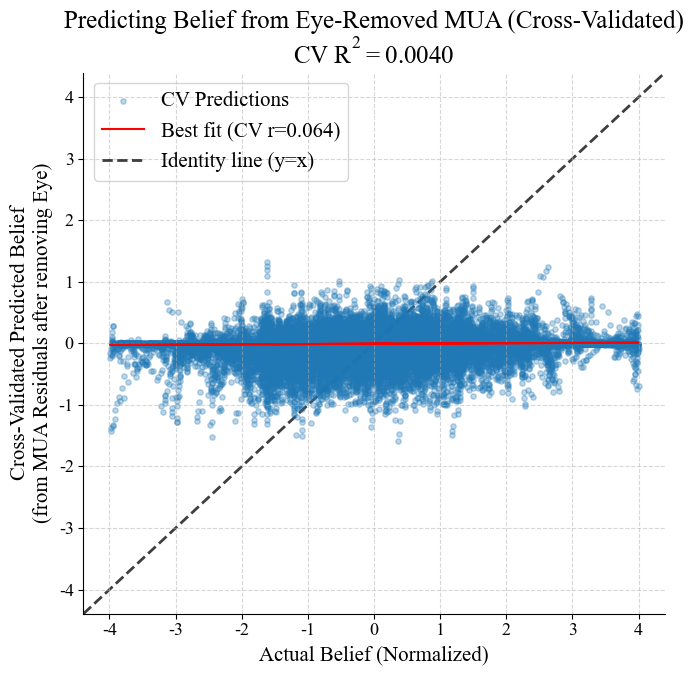


Strategy 2 Analysis with MUA Envelope and Cross-Validation Complete.


In [80]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.signal import butter, filtfilt # For filtering

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC' (list/array of raw voltage per trial),
# 'belief', and 'eye'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     raise NameError("DataFrame 'timedf' not found. Please load your data.")

# --- Parameters ---
sampling_rate = 1/0.006 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
# Assuming 'PPC' column contains lists/arrays of voltage data for each trial
# Stack them into a single numpy array (samples x features/channels)
# Note: This assumes each entry in 'PPC' has the same number of features/channels!
# If 'PPC' contains time series data, this stacking might need adjustment
# based on how you want to handle time within the regression (e.g., averaging, specific time points).
# FOR NOW: Assuming 'PPC' contains feature vectors (e.g. voltage at one timepoint, or avg voltage) per trial
# If 'PPC' contains time series (e.g., 1000 samples x 50 channels per trial),
# the MUA calculation needs to happen *before* stacking, or the stacking needs care.
# Let's assume 'PPC' contains the raw voltage time series (samples x channels)
# and we apply MUA filtering *across time* (axis=0)
try:
    # Assuming 'PPC' column contains the raw voltage time series per trial
    # We need to handle this structure properly. Let's assume for now it's already
    # stacked correctly as (total_time_samples, n_features/channels)
    # If it's a list of arrays per trial, you'll need to concatenate/reshape first.
    # This example assumes it's directly usable or you adapt the loading.
    # If 'PPC' is per-trial, you might need to process MUA per trial first.
    # Let's proceed assuming neural_data_raw_voltage is correctly shaped (samples, features)
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy()) # Adapt if needed!
    belief_data_present_raw = timedf['belief'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, Belief={belief_data_present_raw.shape}, Eye={eye_data_present_raw.shape}")
    # Ensure the number of samples aligns between neural and behavioral data
    if neural_data_raw_voltage.shape[0] != belief_data_present_raw.shape[0]:
        raise ValueError("Mismatch in number of samples between neural ('PPC') and belief data.")
    if neural_data_raw_voltage.shape[0] != eye_data_present_raw.shape[0]:
        raise ValueError("Mismatch in number of samples between neural ('PPC') and eye data.")

except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'belief', 'eye' exist.")
except Exception as e:
    raise TypeError(f"Error processing 'PPC' column. Ensure it contains stackable numerical data (e.g., numpy arrays). Error: {e}")


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    # Handle potential NaNs or Infs if necessary before scaling
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0) # Replace NaN/Inf with 0 before scaling
    scaler = StandardScaler()
    # Check if data std dev is zero
    if np.std(data) < 1e-9:
         # Return zeros or original data if std dev is zero to avoid division error
        print("Warning: Standard deviation is zero during normalization. Returning zeros.")
        return np.zeros_like(data)
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

# --- Normalize Behavioral Data ---
print("\n--- Normalizing Behavioral Data ---")
belief_data_normalized = normalize_z(belief_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)

# --- Outlier Removal ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev) ---")
task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized]).T
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

# Apply mask to all data types
neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
belief_data_present = belief_data_normalized[mask_outliers] # Use normalized data for analysis
eye_data_present = eye_data_normalized[mask_outliers]       # Use normalized data for analysis

n_removed = len(belief_data_present_raw) - len(belief_data_present)
print(f"Removed {n_removed} outlier trials ({n_removed / len(belief_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, Belief={belief_data_present.shape}, Eye={eye_data_present.shape}")

if len(belief_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")


# =============================================================================
# MUA Envelope Calculation (on Cleaned Raw Voltage)
# =============================================================================
print("\n--- Calculating MUA Envelope ---")

def bandpass_filter(data, lowcut, highcut, fs, order=5, axis=0):
    """Applies a bandpass filter to data."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    # Check if cutoff frequencies are valid
    if low <= 0 or high >= 1 or low >= high:
        raise ValueError("Invalid cutoff frequencies: must be 0 < low < high < fs/2")
    b, a = butter(order, [low, high], btype='band')
    # Apply filter along the specified axis (time axis)
    y = filtfilt(b, a, data, axis=axis)
    return y

def lowpass_filter(data, cutoff, fs, order=5, axis=0):
    """Applies a lowpass filter to data."""
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    # Check if cutoff frequency is valid
    if normal_cutoff <= 0 or normal_cutoff >= 1:
         raise ValueError("Invalid cutoff frequency: must be 0 < cutoff < fs/2")
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
     # Apply filter along the specified axis (time axis)
    y = filtfilt(b, a, data, axis=axis)
    return y

# --- MUA Parameters ---
# These might need tuning based on your specific data/setup
FS = sampling_rate          # Sampling rate (Hz) - Set above
MUA_LOW_CUT = 30         # Lower bound for MUA band (Hz)
MUA_HIGH_CUT = 80         # Upper bound for MUA band (Hz)
ENVELOPE_LOW_CUT = 10      # Smoothing frequency for envelope (Hz) - lower values give smoother envelopes
FILTER_ORDER = 4            # Filter order

# Ensure data is numpy array (already done after outlier removal)
# neural_data_raw_voltage_cleaned = np.array(neural_data_raw_voltage_cleaned)

# 1. Bandpass filter for MUA
print(f"Bandpass filtering ({MUA_LOW_CUT}-{MUA_HIGH_CUT} Hz)...")
# Apply filter column-wise (assuming axis 0 is time/samples)
neural_data_bandpassed = bandpass_filter(neural_data_raw_voltage_cleaned, MUA_LOW_CUT, MUA_HIGH_CUT, FS, order=FILTER_ORDER, axis=0)

# 2. Rectify
print("Rectifying...")
neural_data_rectified = np.abs(neural_data_bandpassed)

# 3. Lowpass filter to get envelope
print(f"Lowpass filtering (< {ENVELOPE_LOW_CUT} Hz) for envelope...")
# Apply filter column-wise (assuming axis 0 is time/samples)
mua_envelope = lowpass_filter(neural_data_rectified, ENVELOPE_LOW_CUT, FS, order=FILTER_ORDER, axis=0)

# Optional: Z-score the resulting MUA envelope for each channel/feature
print("Z-scoring MUA envelope per channel...")
scaler_mua = StandardScaler()
# Fit and transform column by column (if features are channels)
# Handle potential zero std dev channels if necessary
mua_envelope_scaled = np.zeros_like(mua_envelope)
for i in range(mua_envelope.shape[1]):
    channel_data = mua_envelope[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9: # Check for non-zero std dev
        mua_envelope_scaled[:, i] = scaler_mua.fit_transform(channel_data).flatten()
    else:
        print(f"Warning: Channel {i} has zero standard deviation in MUA envelope. Outputting zeros.")


# Use the scaled MUA envelope as the input neural data for the rest of the analysis
neural_data_processed = mua_envelope_scaled
print("MUA Envelope calculation complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")


# =============================================================================
# Strategy 2: Partial Regression / Residual Analysis with Cross-Validation on MUA
# =============================================================================
print("\n--- Strategy 2: Partial Regression / Residual Analysis (with CV on MUA) ---")

# Ensure target data is in numpy array format (already done after outlier removal)
# belief_data_present = np.array(belief_data_present)
# eye_data_present = np.array(eye_data_present)

# Reshape predictor variables for LinearRegression
eye_data_present_2d = eye_data_present.reshape(-1, 1)
belief_data_present_2d = belief_data_present.reshape(-1, 1)

# Define the cross-validation strategy
n_splits = 5 # Number of folds
# Check if enough samples for n_splits
if len(belief_data_present) < n_splits:
    n_splits = max(2, len(belief_data_present)) # Use LeaveOneOut if samples < 5, or at least 2 splits
    print(f"Warning: Not enough samples for {n_splits} folds. Using n_splits={n_splits}.")

cv = KFold(n_splits=n_splits, shuffle=True, random_state=42) # Use shuffle for random data splits
print(f"Using {n_splits}-Fold Cross-Validation")

# Initialize the base model
lr_model = LinearRegression()

# --- Part A: Does Belief explain MUA AFTER removing Eye (CV)? ---

print("\nPart A: Analyzing Belief contribution after removing Eye (CV on MUA)...")

# 1. Get cross-validated predictions for MUA from Eye position ONLY
print("Step 1: Getting CV predictions for MUA ~ Eye")
predicted_mua_from_eye_cv = cross_val_predict(lr_model, eye_data_present_2d, neural_data_processed, cv=cv)

# 2. Calculate Residuals using the CV predictions
print("Step 2: Calculating MUA residuals based on CV predictions")
mua_residuals_after_eye_cv = neural_data_processed - predicted_mua_from_eye_cv

# 3. Can these CV Residuals predict Belief (using CV)?
print("Step 3: Testing if CV MUA Residuals (after Eye removed) predict Belief (using CV)")
predicted_belief_from_mua_residuals_cv = cross_val_predict(lr_model, mua_residuals_after_eye_cv, belief_data_present, cv=cv)

# Evaluate how well the CV residuals predict belief using R-squared and Pearson r
r2_belief_after_eye_mua_cv = r2_score(belief_data_present, predicted_belief_from_mua_residuals_cv)
# Ensure predictions and actual values have same length and are finite
valid_indices_belief = np.isfinite(belief_data_present) & np.isfinite(predicted_belief_from_mua_residuals_cv)
if np.sum(valid_indices_belief) < 2: # Need at least 2 points for correlation
    print("Warning: Not enough valid data points to calculate Pearson correlation for Belief.")
    r_belief_after_eye_mua_cv, p_belief_after_eye_mua_cv = np.nan, np.nan
else:
    r_belief_after_eye_mua_cv, p_belief_after_eye_mua_cv = pearsonr(belief_data_present[valid_indices_belief], predicted_belief_from_mua_residuals_cv[valid_indices_belief])


print(f"  Cross-Validated R-squared (MUA Residuals [after Eye] -> Belief): {r2_belief_after_eye_mua_cv:.4f}")
print(f"  Cross-Validated Pearson r (Actual Belief vs CV Predicted Belief [from MUA Residuals]): {r_belief_after_eye_mua_cv:.4f}, p={p_belief_after_eye_mua_cv:.2e}")


# --- Part B: Symmetric Check - Does Eye explain MUA AFTER removing Belief (CV)? ---

print("\nPart B: Analyzing Eye contribution after removing Belief (CV on MUA)...")

# 1. Get cross-validated predictions for MUA from Belief ONLY
print("Step 1: Getting CV predictions for MUA ~ Belief")
predicted_mua_from_belief_cv = cross_val_predict(lr_model, belief_data_present_2d, neural_data_processed, cv=cv)

# 2. Calculate Residuals using the CV predictions
print("Step 2: Calculating MUA residuals based on CV predictions")
mua_residuals_after_belief_cv = neural_data_processed - predicted_mua_from_belief_cv

# 3. Can these CV Residuals predict Eye (using CV)?
print("Step 3: Testing if CV MUA Residuals (after Belief removed) predict Eye (using CV)")
predicted_eye_from_mua_residuals_cv = cross_val_predict(lr_model, mua_residuals_after_belief_cv, eye_data_present, cv=cv)

# Evaluate how well the CV residuals predict eye using R-squared and Pearson r
r2_eye_after_belief_mua_cv = r2_score(eye_data_present, predicted_eye_from_mua_residuals_cv)
# Ensure predictions and actual values have same length and are finite
valid_indices_eye = np.isfinite(eye_data_present) & np.isfinite(predicted_eye_from_mua_residuals_cv)
if np.sum(valid_indices_eye) < 2: # Need at least 2 points for correlation
     print("Warning: Not enough valid data points to calculate Pearson correlation for Eye.")
     r_eye_after_belief_mua_cv, p_eye_after_belief_mua_cv = np.nan, np.nan
else:
    r_eye_after_belief_mua_cv, p_eye_after_belief_mua_cv = pearsonr(eye_data_present[valid_indices_eye], predicted_eye_from_mua_residuals_cv[valid_indices_eye])


print(f"  Cross-Validated R-squared (MUA Residuals [after Belief] -> Eye): {r2_eye_after_belief_mua_cv:.4f}")
print(f"  Cross-Validated Pearson r (Actual Eye vs CV Predicted Eye [from MUA Residuals]): {r_eye_after_belief_mua_cv:.4f}, p={p_eye_after_belief_mua_cv:.2e}")


# --- Plotting the key cross-validated result (Part A on MUA) ---
print("\nGenerating plot for Part A cross-validated result (on MUA)...")
fig_strategy2_cv_mua, ax_strategy2_cv_mua = plt.subplots(figsize=(7, 7))

# Scatter plot: Actual belief vs Belief predicted using CV from eye-removed MUA residuals
# Use only valid indices for plotting if NaNs were generated
ax_strategy2_cv_mua.scatter(belief_data_present[valid_indices_belief], predicted_belief_from_mua_residuals_cv[valid_indices_belief], alpha=0.3, s=15, label='CV Predictions')

# Add line of best fit using only valid points
if np.sum(valid_indices_belief) >= 2:
    m_s2_cv_mua, c_s2_cv_mua = np.polyfit(belief_data_present[valid_indices_belief], predicted_belief_from_mua_residuals_cv[valid_indices_belief], 1)
    ax_strategy2_cv_mua.plot(belief_data_present[valid_indices_belief], m_s2_cv_mua*belief_data_present[valid_indices_belief] + c_s2_cv_mua, color='red', linewidth=1.5, label=f'Best fit (CV r={r_belief_after_eye_mua_cv:.3f})')
else:
    ax_strategy2_cv_mua.plot([], [], color='red', linewidth=1.5, label=f'Best fit (CV r=N/A)')


# Add identity line
# Calculate limits based on valid data if possible
if np.sum(valid_indices_belief) > 0:
    valid_belief = belief_data_present[valid_indices_belief]
    valid_pred_belief = predicted_belief_from_mua_residuals_cv[valid_indices_belief]
    lims_cv_mua = [min(np.min(valid_belief), np.min(valid_pred_belief)),
                   max(np.max(valid_belief), np.max(valid_pred_belief))]
    # Add some padding to limits
    padding = (lims_cv_mua[1] - lims_cv_mua[0]) * 0.05
    lims_cv_mua = [lims_cv_mua[0] - padding, lims_cv_mua[1] + padding]
else:
    lims_cv_mua = [-1, 1] # Default limits if no valid data

ax_strategy2_cv_mua.plot(lims_cv_mua, lims_cv_mua, 'k--', alpha=0.75, zorder=0, label='Identity line (y=x)')
ax_strategy2_cv_mua.set_xlim(lims_cv_mua)
ax_strategy2_cv_mua.set_ylim(lims_cv_mua)


# Add labels and title
ax_strategy2_cv_mua.set_xlabel('Actual Belief (Normalized)')
ax_strategy2_cv_mua.set_ylabel('Cross-Validated Predicted Belief\n(from MUA Residuals after removing Eye)')
ax_strategy2_cv_mua.set_title(f'Predicting Belief from Eye-Removed MUA (Cross-Validated)\nCV $R^2 = {r2_belief_after_eye_mua_cv:.4f}$')
ax_strategy2_cv_mua.legend()
ax_strategy2_cv_mua.grid(True, linestyle='--', alpha=0.5)
# ax_strategy2_cv_mua.axis('equal') # Keep axis equal scaling
plt.tight_layout()
plt.show()

print("\nStrategy 2 Analysis with MUA Envelope and Cross-Validation Complete.")


Using provided 'timedf' DataFrame.
--- Extracting Raw Data from DataFrame ---
Initial shapes: Neural=(400117, 112), Belief=(400117,), Eye=(400117,)

--- Normalizing Behavioral Data ---

--- Removing Outliers (Threshold: +/- 4 std dev) ---
Removed 607 outlier trials (0.15%).
Data shape after cleaning: Neural=(399510, 112), Belief=(399510,), Eye=(399510,)

--- Applying Gaussian Smoothing (sigma = 5 samples) ---
Gaussian smoothing complete.
Z-scoring smoothed data per channel...
Z-scoring complete.
Processed neural data shape: (399510, 112)

--- Strategy 2: Partial Regression / Residual Analysis (with CV on Smoothed Data) ---
Using 5-Fold Cross-Validation

Part A: Analyzing Belief contribution after removing Eye (CV on Smoothed Data)...
Step 1: Getting CV predictions for Smoothed Data ~ Eye
Step 2: Calculating Smoothed Data residuals based on CV predictions
Step 3: Testing if CV Smoothed Residuals (after Eye removed) predict Belief (using CV)
  Cross-Validated R-squared (Smoothed Residual

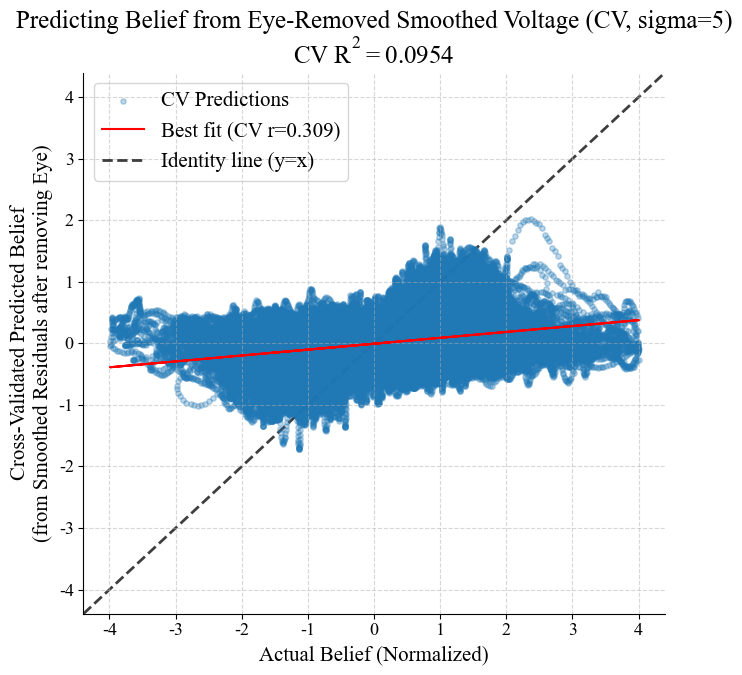


Strategy 2 Analysis with Gaussian Smoothing and Cross-Validation Complete.


In [81]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC' (list/array of raw voltage per trial),
# 'belief', and 'eye'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     # Try to load placeholder if actual data not found
     print("Warning: DataFrame 'timedf' not found. Using placeholder data.")
     # --- Placeholder Data (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
     rng = np.random.default_rng(42)
     n_samples_orig = 10000 # Time samples
     n_features = 50      # Number of channels/neurons
     sampling_rate = 166 # Hz - Set to user's rate

     belief_signal_true = normalize_z(rng.random(n_samples_orig) * 10)
     eye_signal_true = normalize_z(rng.random(n_samples_orig) * 5)
     belief_signal_correlated = normalize_z(0.7 * belief_signal_true + 0.3 * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     eye_signal_correlated = normalize_z(0.3 * belief_signal_true + 0.7 * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))

     # Simulate baseline "voltage" - use lower frequencies consistent with low sampling rate
     voltage_noise = rng.normal(0, 1.0, (n_samples_orig, n_features))
     # Modulate the amplitude based on belief and eye
     belief_mod = belief_signal_correlated[:, np.newaxis] * 0.1 # Weaker belief component
     eye_mod = eye_signal_correlated[:, np.newaxis] * 0.3   # Stronger eye component
     neural_data_raw_voltage_sim = voltage_noise + belief_mod + eye_mod # Simplified simulation

     timedf = pd.DataFrame({
         # Store as list of arrays if that matches user structure, otherwise adjust loading below
         'PPC': list(neural_data_raw_voltage_sim),
         'belief': belief_signal_correlated,
         'eye': eye_signal_correlated
     })
     # --- End Placeholder Data ---
else:
    print("Using provided 'timedf' DataFrame.")


# --- Parameters ---
sampling_rate = 166 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers
gaussian_sigma_samples = 5 # Std deviation of Gaussian kernel in SAMPLES - ADJUST AS NEEDED

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
try:
    # This assumes 'PPC' column contains stackable numerical data (e.g., numpy arrays)
    # representing the voltage time series (samples x features/channels).
    # If your structure is different (e.g. list of lists), adjust np.stack.
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy())
    belief_data_present_raw = timedf['belief'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, Belief={belief_data_present_raw.shape}, Eye={eye_data_present_raw.shape}")
    # Ensure the number of samples aligns between neural and behavioral data
    if neural_data_raw_voltage.shape[0] != belief_data_present_raw.shape[0]:
        raise ValueError("Mismatch in number of samples between neural ('PPC') and belief data.")
    if neural_data_raw_voltage.shape[0] != eye_data_present_raw.shape[0]:
        raise ValueError("Mismatch in number of samples between neural ('PPC') and eye data.")

except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'belief', 'eye' exist.")
except Exception as e:
    raise TypeError(f"Error processing 'PPC' column. Ensure it contains stackable numerical data (e.g., numpy arrays). Error: {e}")


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    # Handle potential NaNs or Infs if necessary before scaling
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0) # Replace NaN/Inf with 0 before scaling
    scaler = StandardScaler()
    # Check if data std dev is zero
    if np.std(data) < 1e-9:
         # Return zeros or original data if std dev is zero to avoid division error
        print("Warning: Standard deviation is zero during normalization. Returning zeros.")
        return np.zeros_like(data)
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

# --- Normalize Behavioral Data ---
print("\n--- Normalizing Behavioral Data ---")
belief_data_normalized = normalize_z(belief_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)

# --- Outlier Removal ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev) ---")
task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized]).T
# Identify trials where *either* belief or eye exceeds threshold
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

# Apply mask to all data types
neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
belief_data_present = belief_data_normalized[mask_outliers] # Use normalized data for analysis
eye_data_present = eye_data_normalized[mask_outliers]       # Use normalized data for analysis

n_removed = len(belief_data_present_raw) - len(belief_data_present)
print(f"Removed {n_removed} outlier trials ({n_removed / len(belief_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, Belief={belief_data_present.shape}, Eye={eye_data_present.shape}")

if len(belief_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")


# =============================================================================
# Gaussian Smoothing of Raw Voltage Data
# =============================================================================
print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---")

# Apply Gaussian filter along the time axis (axis=0) for each channel
# mode='reflect' is a reasonable default for handling edges
neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_cleaned,
                                         sigma=gaussian_sigma_samples,
                                         axis=0,
                                         mode='reflect')

print("Gaussian smoothing complete.")

# =============================================================================
# Z-score Smoothed Data Per Channel
# =============================================================================
print("Z-scoring smoothed data per channel...")
scaler_smooth = StandardScaler()
# Fit and transform column by column (if features are channels)
# Handle potential zero std dev channels if necessary
neural_data_processed = np.zeros_like(neural_data_smoothed)
for i in range(neural_data_smoothed.shape[1]):
    channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9: # Check for non-zero std dev
        neural_data_processed[:, i] = scaler_smooth.fit_transform(channel_data).flatten()
    else:
        print(f"Warning: Channel {i} has zero standard deviation after smoothing. Outputting zeros.")

print("Z-scoring complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")


# =============================================================================
# Strategy 2: Partial Regression / Residual Analysis with CV on Smoothed Data
# =============================================================================
print("\n--- Strategy 2: Partial Regression / Residual Analysis (with CV on Smoothed Data) ---")

# Ensure target data is in numpy array format (already done after outlier removal)
# belief_data_present = np.array(belief_data_present)
# eye_data_present = np.array(eye_data_present)

# Reshape predictor variables for LinearRegression
eye_data_present_2d = eye_data_present.reshape(-1, 1)
belief_data_present_2d = belief_data_present.reshape(-1, 1)

# Define the cross-validation strategy
n_splits = 5 # Number of folds
# Check if enough samples for n_splits
if len(belief_data_present) < n_splits:
    n_splits = max(2, len(belief_data_present)) # Use LeaveOneOut if samples < 5, or at least 2 splits
    print(f"Warning: Not enough samples for {n_splits} folds. Using n_splits={n_splits}.")

cv = KFold(n_splits=n_splits, shuffle=True, random_state=42) # Use shuffle for random data splits
print(f"Using {n_splits}-Fold Cross-Validation")

# Initialize the base model
lr_model = LinearRegression()

# --- Part A: Does Belief explain Smoothed Data AFTER removing Eye (CV)? ---

print("\nPart A: Analyzing Belief contribution after removing Eye (CV on Smoothed Data)...")

# 1. Get cross-validated predictions for Smoothed Data ~ Eye
print("Step 1: Getting CV predictions for Smoothed Data ~ Eye")
predicted_smooth_from_eye_cv = cross_val_predict(lr_model, eye_data_present_2d, neural_data_processed, cv=cv)

# 2. Calculate Residuals using the CV predictions
print("Step 2: Calculating Smoothed Data residuals based on CV predictions")
smooth_residuals_after_eye_cv = neural_data_processed - predicted_smooth_from_eye_cv

# 3. Can these CV Residuals predict Belief (using CV)?
print("Step 3: Testing if CV Smoothed Residuals (after Eye removed) predict Belief (using CV)")
predicted_belief_from_smooth_residuals_cv = cross_val_predict(lr_model, smooth_residuals_after_eye_cv, belief_data_present, cv=cv)

# Evaluate how well the CV residuals predict belief using R-squared and Pearson r
r2_belief_after_eye_smooth_cv = r2_score(belief_data_present, predicted_belief_from_smooth_residuals_cv)
# Ensure predictions and actual values have same length and are finite
valid_indices_belief = np.isfinite(belief_data_present) & np.isfinite(predicted_belief_from_smooth_residuals_cv)
if np.sum(valid_indices_belief) < 2: # Need at least 2 points for correlation
    print("Warning: Not enough valid data points to calculate Pearson correlation for Belief.")
    r_belief_after_eye_smooth_cv, p_belief_after_eye_smooth_cv = np.nan, np.nan
else:
    r_belief_after_eye_smooth_cv, p_belief_after_eye_smooth_cv = pearsonr(belief_data_present[valid_indices_belief], predicted_belief_from_smooth_residuals_cv[valid_indices_belief])


print(f"  Cross-Validated R-squared (Smoothed Residuals [after Eye] -> Belief): {r2_belief_after_eye_smooth_cv:.4f}")
print(f"  Cross-Validated Pearson r (Actual Belief vs CV Predicted Belief [from Smoothed Residuals]): {r_belief_after_eye_smooth_cv:.4f}, p={p_belief_after_eye_smooth_cv:.2e}")


# --- Part B: Symmetric Check - Does Eye explain Smoothed Data AFTER removing Belief (CV)? ---

print("\nPart B: Analyzing Eye contribution after removing Belief (CV on Smoothed Data)...")

# 1. Get cross-validated predictions for Smoothed Data ~ Belief
print("Step 1: Getting CV predictions for Smoothed Data ~ Belief")
predicted_smooth_from_belief_cv = cross_val_predict(lr_model, belief_data_present_2d, neural_data_processed, cv=cv)

# 2. Calculate Residuals using the CV predictions
print("Step 2: Calculating Smoothed Data residuals based on CV predictions")
smooth_residuals_after_belief_cv = neural_data_processed - predicted_smooth_from_belief_cv

# 3. Can these CV Residuals predict Eye (using CV)?
print("Step 3: Testing if CV Smoothed Residuals (after Belief removed) predict Eye (using CV)")
predicted_eye_from_smooth_residuals_cv = cross_val_predict(lr_model, smooth_residuals_after_belief_cv, eye_data_present, cv=cv)

# Evaluate how well the CV residuals predict eye using R-squared and Pearson r
r2_eye_after_belief_smooth_cv = r2_score(eye_data_present, predicted_eye_from_smooth_residuals_cv)
# Ensure predictions and actual values have same length and are finite
valid_indices_eye = np.isfinite(eye_data_present) & np.isfinite(predicted_eye_from_smooth_residuals_cv)
if np.sum(valid_indices_eye) < 2: # Need at least 2 points for correlation
     print("Warning: Not enough valid data points to calculate Pearson correlation for Eye.")
     r_eye_after_belief_smooth_cv, p_eye_after_belief_smooth_cv = np.nan, np.nan
else:
    r_eye_after_belief_smooth_cv, p_eye_after_belief_smooth_cv = pearsonr(eye_data_present[valid_indices_eye], predicted_eye_from_smooth_residuals_cv[valid_indices_eye])


print(f"  Cross-Validated R-squared (Smoothed Residuals [after Belief] -> Eye): {r2_eye_after_belief_smooth_cv:.4f}")
print(f"  Cross-Validated Pearson r (Actual Eye vs CV Predicted Eye [from Smoothed Residuals]): {r_eye_after_belief_smooth_cv:.4f}, p={p_eye_after_belief_smooth_cv:.2e}")


# --- Plotting the key cross-validated result (Part A on Smoothed Data) ---
print("\nGenerating plot for Part A cross-validated result (on Smoothed Data)...")
fig_strategy2_cv_smooth, ax_strategy2_cv_smooth = plt.subplots(figsize=(7, 7))

# Scatter plot: Actual belief vs Belief predicted using CV from eye-removed smoothed residuals
# Use only valid indices for plotting if NaNs were generated
ax_strategy2_cv_smooth.scatter(belief_data_present[valid_indices_belief], predicted_belief_from_smooth_residuals_cv[valid_indices_belief], alpha=0.3, s=15, label='CV Predictions')

# Add line of best fit using only valid points
if np.sum(valid_indices_belief) >= 2:
    m_s2_cv_smooth, c_s2_cv_smooth = np.polyfit(belief_data_present[valid_indices_belief], predicted_belief_from_smooth_residuals_cv[valid_indices_belief], 1)
    ax_strategy2_cv_smooth.plot(belief_data_present[valid_indices_belief], m_s2_cv_smooth*belief_data_present[valid_indices_belief] + c_s2_cv_smooth, color='red', linewidth=1.5, label=f'Best fit (CV r={r_belief_after_eye_smooth_cv:.3f})')
else:
     ax_strategy2_cv_smooth.plot([], [], color='red', linewidth=1.5, label=f'Best fit (CV r=N/A)')


# Add identity line
if np.sum(valid_indices_belief) > 0:
    valid_belief = belief_data_present[valid_indices_belief]
    valid_pred_belief = predicted_belief_from_smooth_residuals_cv[valid_indices_belief]
    lims_cv_smooth = [min(np.min(valid_belief), np.min(valid_pred_belief)),
                      max(np.max(valid_belief), np.max(valid_pred_belief))]
    padding = (lims_cv_smooth[1] - lims_cv_smooth[0]) * 0.05
    lims_cv_smooth = [lims_cv_smooth[0] - padding, lims_cv_smooth[1] + padding]
else:
    lims_cv_smooth = [-1, 1] # Default limits

ax_strategy2_cv_smooth.plot(lims_cv_smooth, lims_cv_smooth, 'k--', alpha=0.75, zorder=0, label='Identity line (y=x)')
ax_strategy2_cv_smooth.set_xlim(lims_cv_smooth)
ax_strategy2_cv_smooth.set_ylim(lims_cv_smooth)


# Add labels and title
ax_strategy2_cv_smooth.set_xlabel('Actual Belief (Normalized)')
ax_strategy2_cv_smooth.set_ylabel('Cross-Validated Predicted Belief\n(from Smoothed Residuals after removing Eye)')
ax_strategy2_cv_smooth.set_title(f'Predicting Belief from Eye-Removed Smoothed Voltage (CV, sigma={gaussian_sigma_samples})\nCV $R^2 = {r2_belief_after_eye_smooth_cv:.4f}$')
ax_strategy2_cv_smooth.legend()
ax_strategy2_cv_smooth.grid(True, linestyle='--', alpha=0.5)
# ax_strategy2_cv_smooth.axis('equal') # Keep axes equal
plt.tight_layout()
plt.show()

print("\nStrategy 2 Analysis with Gaussian Smoothing and Cross-Validation Complete.")


Using provided 'timedf' DataFrame.
--- Extracting Raw Data from DataFrame ---
Initial shapes: Neural=(400117, 112), Belief=(400117,), Eye=(400117,)

--- Normalizing Behavioral Data ---

--- Removing Outliers (Threshold: +/- 4 std dev) ---
Removed 607 outlier trials (0.15%).
Data shape after cleaning: Neural=(399510, 112), Belief=(399510,), Eye=(399510,)

--- Applying Gaussian Smoothing (sigma = 5 samples) ---
Gaussian smoothing complete.
Z-scoring smoothed data per channel...
Z-scoring complete.
Processed neural data shape: (399510, 112)

--- Recalculating CV Residuals After Removing Eye (Smoothed Data) ---
Using 5-Fold Cross-Validation
Step 1: Getting CV predictions for Smoothed Data ~ Eye
Step 2: Calculating Smoothed Data residuals based on CV predictions
  Calculated smooth_residuals_after_eye_cv

--- Cross-Validated Sanity Check: Predicting Eye from Eye-Removed CV Residuals ---
Step 1: Getting CV predictions for Eye ~ CV Residuals [after Eye]
Step 2: Evaluating prediction performan

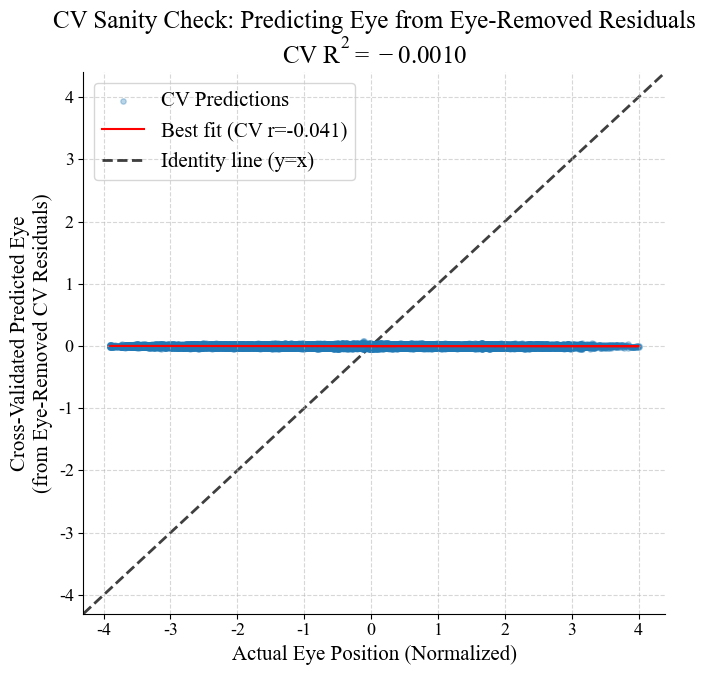


Cross-Validated Sanity Check Complete.


In [82]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC' (list/array of raw voltage per trial),
# 'belief', and 'eye'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     # Try to load placeholder if actual data not found
     print("Warning: DataFrame 'timedf' not found. Using placeholder data.")
     # --- Placeholder Data (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
     rng = np.random.default_rng(42)
     n_samples_orig = 10000 # Time samples
     n_features = 50      # Number of channels/neurons
     sampling_rate = 166 # Hz - Set to user's rate

     belief_signal_true = normalize_z(rng.random(n_samples_orig) * 10)
     eye_signal_true = normalize_z(rng.random(n_samples_orig) * 5)
     belief_signal_correlated = normalize_z(0.7 * belief_signal_true + 0.3 * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     eye_signal_correlated = normalize_z(0.3 * belief_signal_true + 0.7 * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))

     voltage_noise = rng.normal(0, 1.0, (n_samples_orig, n_features))
     belief_mod = belief_signal_correlated[:, np.newaxis] * 0.1
     eye_mod = eye_signal_correlated[:, np.newaxis] * 0.3
     neural_data_raw_voltage_sim = voltage_noise + belief_mod + eye_mod

     timedf = pd.DataFrame({
         'PPC': list(neural_data_raw_voltage_sim),
         'belief': belief_signal_correlated,
         'eye': eye_signal_correlated
     })
     # --- End Placeholder Data ---
else:
    print("Using provided 'timedf' DataFrame.")


# --- Parameters ---
sampling_rate = 166 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers
gaussian_sigma_samples = 5 # Std deviation of Gaussian kernel in SAMPLES

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
try:
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy())
    belief_data_present_raw = timedf['belief'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, Belief={belief_data_present_raw.shape}, Eye={eye_data_present_raw.shape}")
    if neural_data_raw_voltage.shape[0] != belief_data_present_raw.shape[0]:
        raise ValueError("Mismatch in number of samples between neural ('PPC') and belief data.")
    if neural_data_raw_voltage.shape[0] != eye_data_present_raw.shape[0]:
        raise ValueError("Mismatch in number of samples between neural ('PPC') and eye data.")
except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'belief', 'eye' exist.")
except Exception as e:
    raise TypeError(f"Error processing 'PPC' column. Ensure it contains stackable numerical data. Error: {e}")


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
    scaler = StandardScaler()
    if np.std(data) < 1e-9:
        print("Warning: Standard deviation is zero during normalization. Returning zeros.")
        return np.zeros_like(data)
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

# --- Normalize Behavioral Data ---
print("\n--- Normalizing Behavioral Data ---")
belief_data_normalized = normalize_z(belief_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)

# --- Outlier Removal ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev) ---")
task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized]).T
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
belief_data_present = belief_data_normalized[mask_outliers]
eye_data_present = eye_data_normalized[mask_outliers]

n_removed = len(belief_data_present_raw) - len(belief_data_present)
print(f"Removed {n_removed} outlier trials ({n_removed / len(belief_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, Belief={belief_data_present.shape}, Eye={eye_data_present.shape}")

if len(belief_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")

# =============================================================================
# Gaussian Smoothing of Raw Voltage Data
# =============================================================================
print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---")
neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_cleaned,
                                         sigma=gaussian_sigma_samples,
                                         axis=0,
                                         mode='reflect')
print("Gaussian smoothing complete.")

# =============================================================================
# Z-score Smoothed Data Per Channel
# =============================================================================
print("Z-scoring smoothed data per channel...")
scaler_smooth = StandardScaler()
neural_data_processed = np.zeros_like(neural_data_smoothed)
for i in range(neural_data_smoothed.shape[1]):
    channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9:
        neural_data_processed[:, i] = scaler_smooth.fit_transform(channel_data).flatten()
    else:
        print(f"Warning: Channel {i} has zero standard deviation after smoothing. Outputting zeros.")
print("Z-scoring complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")

# =============================================================================
# Calculate Cross-Validated Residuals After Removing Eye (from Strategy 2, Part A)
# =============================================================================
print("\n--- Recalculating CV Residuals After Removing Eye (Smoothed Data) ---")

# Reshape eye data for prediction
eye_data_present_2d = eye_data_present.reshape(-1, 1)

# Define the cross-validation strategy
n_splits = 5
if len(belief_data_present) < n_splits:
    n_splits = max(2, len(belief_data_present))
cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
print(f"Using {n_splits}-Fold Cross-Validation")

# Initialize the base model
lr_model = LinearRegression()

# 1. Get cross-validated predictions for Smoothed Data ~ Eye
print("Step 1: Getting CV predictions for Smoothed Data ~ Eye")
predicted_smooth_from_eye_cv = cross_val_predict(lr_model, eye_data_present_2d, neural_data_processed, cv=cv)

# 2. Calculate Residuals using the CV predictions
print("Step 2: Calculating Smoothed Data residuals based on CV predictions")
smooth_residuals_after_eye_cv = neural_data_processed - predicted_smooth_from_eye_cv
print("  Calculated smooth_residuals_after_eye_cv")

# =============================================================================
# Cross-Validated Sanity Check: Can CV Residuals (after Eye removed) predict Eye?
# =============================================================================
print("\n--- Cross-Validated Sanity Check: Predicting Eye from Eye-Removed CV Residuals ---")

# 1. Get cross-validated predictions for Eye ~ CV_Residuals_after_Eye
print("Step 1: Getting CV predictions for Eye ~ CV Residuals [after Eye]")
# Use the CV residuals calculated just above to predict the original eye data, using CV again
predicted_eye_from_cv_residuals_cv = cross_val_predict(lr_model, smooth_residuals_after_eye_cv, eye_data_present, cv=cv)

# 2. Evaluate the prediction performance using R2 score and Pearson r
# Compare the actual eye data with the cross-validated predictions from the residuals
print("Step 2: Evaluating prediction performance")
r2_eye_from_cv_residuals_cv = r2_score(eye_data_present, predicted_eye_from_cv_residuals_cv)
print(f"  Cross-Validated R-squared (CV Residuals [after Eye] -> Eye): {r2_eye_from_cv_residuals_cv:.4f} (Expected near 0)")

# Calculate the Pearson correlation
# Ensure predictions and actual values have same length and are finite
valid_indices_eye_sc = np.isfinite(eye_data_present) & np.isfinite(predicted_eye_from_cv_residuals_cv)
if np.sum(valid_indices_eye_sc) < 2: # Need at least 2 points for correlation
     print("Warning: Not enough valid data points to calculate Pearson correlation for Sanity Check.")
     r_eye_from_cv_residuals_cv, p_eye_from_cv_residuals_cv = np.nan, np.nan
else:
    r_eye_from_cv_residuals_cv, p_eye_from_cv_residuals_cv = pearsonr(eye_data_present[valid_indices_eye_sc], predicted_eye_from_cv_residuals_cv[valid_indices_eye_sc])

print(f"  Cross-Validated Pearson r (Actual Eye vs CV Predicted Eye [from CV Residuals]): {r_eye_from_cv_residuals_cv:.4f}, p={p_eye_from_cv_residuals_cv:.2e} (Expected near 0)")


# --- Plotting the Cross-Validated Sanity Check Result ---
print("\nGenerating plot for Cross-Validated Sanity Check result...")
fig_cv_sanity_check, ax_cv_sanity_check = plt.subplots(figsize=(7, 7))

# Scatter plot: Actual eye vs Eye predicted using CV from eye-removed CV residuals
# Use only valid indices for plotting if NaNs were generated
ax_cv_sanity_check.scatter(eye_data_present[valid_indices_eye_sc], predicted_eye_from_cv_residuals_cv[valid_indices_eye_sc], alpha=0.3, s=15, label='CV Predictions')

# Add line of best fit using only valid points (should be near flat)
if np.sum(valid_indices_eye_sc) >= 2:
    m_sc_cv, c_sc_cv = np.polyfit(eye_data_present[valid_indices_eye_sc], predicted_eye_from_cv_residuals_cv[valid_indices_eye_sc], 1)
    ax_cv_sanity_check.plot(eye_data_present[valid_indices_eye_sc], m_sc_cv*eye_data_present[valid_indices_eye_sc] + c_sc_cv, color='red', linewidth=1.5, label=f'Best fit (CV r={r_eye_from_cv_residuals_cv:.3f})')
else:
    ax_cv_sanity_check.plot([], [], color='red', linewidth=1.5, label=f'Best fit (CV r=N/A)')


# Add identity line (y=x) for reference
if np.sum(valid_indices_eye_sc) > 0:
    valid_eye = eye_data_present[valid_indices_eye_sc]
    valid_pred_eye = predicted_eye_from_cv_residuals_cv[valid_indices_eye_sc]
    lims_sc_cv = [min(np.min(valid_eye), np.min(valid_pred_eye)),
                  max(np.max(valid_eye), np.max(valid_pred_eye))]
    padding = (lims_sc_cv[1] - lims_sc_cv[0]) * 0.05
    lims_sc_cv = [lims_sc_cv[0] - padding, lims_sc_cv[1] + padding]
else:
    lims_sc_cv = [-1, 1] # Default limits

ax_cv_sanity_check.plot(lims_sc_cv, lims_sc_cv, 'k--', alpha=0.75, zorder=0, label='Identity line (y=x)')
ax_cv_sanity_check.set_xlim(lims_sc_cv)
ax_cv_sanity_check.set_ylim(lims_sc_cv)


# Add labels and title
ax_cv_sanity_check.set_xlabel('Actual Eye Position (Normalized)')
ax_cv_sanity_check.set_ylabel('Cross-Validated Predicted Eye\n(from Eye-Removed CV Residuals)')
ax_cv_sanity_check.set_title(f'CV Sanity Check: Predicting Eye from Eye-Removed Residuals\nCV $R^2 = {r2_eye_from_cv_residuals_cv:.4f}$') # Use LaTeX for R^2
ax_cv_sanity_check.legend()
ax_cv_sanity_check.grid(True, linestyle='--', alpha=0.5)
# ax_cv_sanity_check.axis('equal') # Keep axes equal
plt.tight_layout()
plt.show()

print("\nCross-Validated Sanity Check Complete.")


Using provided 'timedf' DataFrame.
--- Extracting Raw Data from DataFrame ---
Initial shapes: Neural=(400117, 112), Belief=(400117,), Eye=(400117,), State=(400117,)

--- Normalizing Behavioral Data ---

--- Removing Outliers (Threshold: +/- 4 std dev for Belief, Eye, AND State) ---
Removed 978 outlier trials (0.24%).
Data shape after cleaning: Neural=(399139, 112), Belief=(399139,), Eye=(399139,), State=(399139,)

--- Applying Gaussian Smoothing (sigma = 5 samples) ---
Gaussian smoothing complete.
Z-scoring smoothed data per channel...
Z-scoring complete.
Processed neural data shape: (399139, 112)

--- Recalculating CV Residuals After Removing Eye (Smoothed Data) ---
Using 5-Fold Cross-Validation
Step 1: Getting CV predictions for Smoothed Data ~ Eye
Step 2: Calculating Smoothed Data residuals based on CV predictions
  Calculated smooth_residuals_after_eye_cv

--- Predicting Belief vs State from Eye-Removed CV Residuals ---
A: Predicting Belief from CV Residuals [after Eye]...
  CV R-s

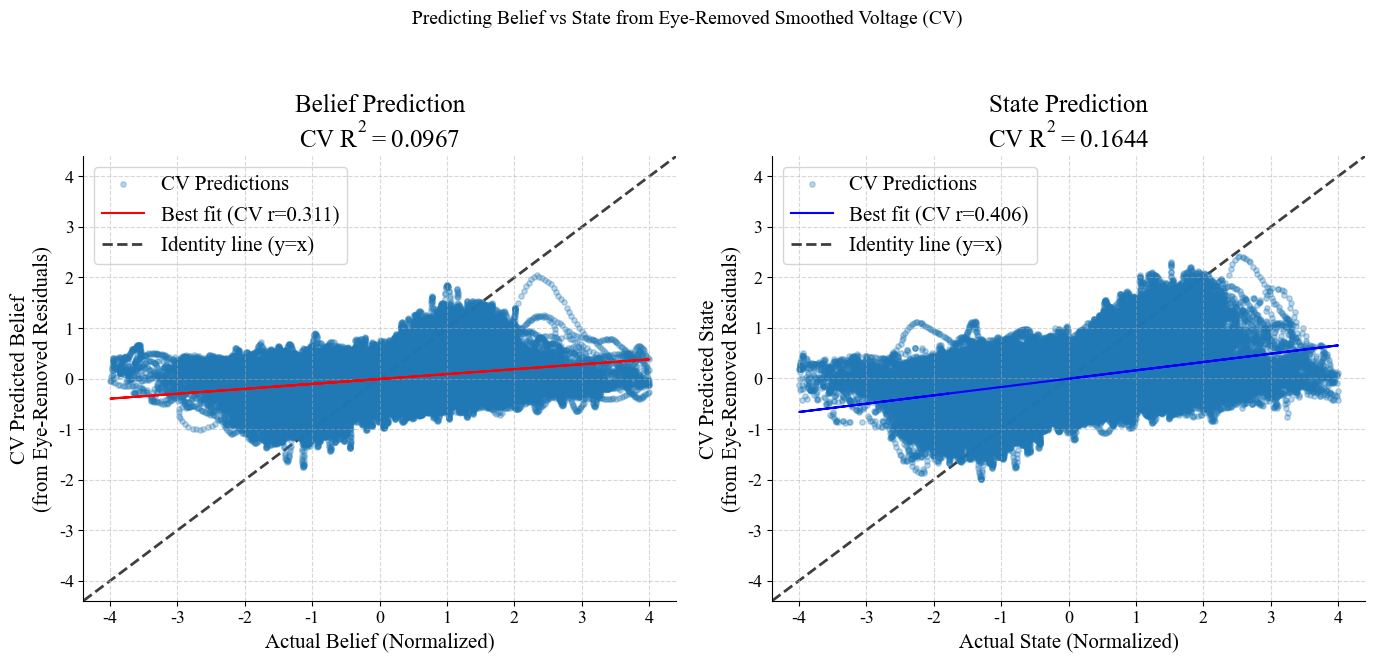


Comparative Analysis Complete.


In [83]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC', 'belief', 'eye', and 'state'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     # Try to load placeholder if actual data not found
     print("Warning: DataFrame 'timedf' not found. Using placeholder data.")
     # --- Placeholder Data (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
     rng = np.random.default_rng(42)
     n_samples_orig = 10000 # Time samples
     n_features = 50      # Number of channels/neurons
     sampling_rate = 166 # Hz - Set to user's rate

     belief_signal_true = normalize_z(rng.random(n_samples_orig) * 10)
     eye_signal_true = normalize_z(rng.random(n_samples_orig) * 5)
     # Simulate state as belief + noise
     state_signal_true = normalize_z(belief_signal_true + rng.normal(0, 0.3, n_samples_orig))

     belief_signal_correlated = normalize_z(0.7 * belief_signal_true + 0.3 * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     eye_signal_correlated = normalize_z(0.3 * belief_signal_true + 0.7 * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     state_signal_correlated = normalize_z(0.7 * state_signal_true + 0.3 * eye_signal_true + rng.normal(0, 0.5, n_samples_orig)) # State also correlated with eye

     voltage_noise = rng.normal(0, 1.0, (n_samples_orig, n_features))
     belief_mod = belief_signal_correlated[:, np.newaxis] * 0.1
     eye_mod = eye_signal_correlated[:, np.newaxis] * 0.3
     # Assume state has weaker neural correlate than belief
     state_mod = state_signal_correlated[:, np.newaxis] * 0.05
     neural_data_raw_voltage_sim = voltage_noise + belief_mod + eye_mod + state_mod

     timedf = pd.DataFrame({
         'PPC': list(neural_data_raw_voltage_sim),
         'belief': belief_signal_correlated,
         'eye': eye_signal_correlated,
         'state': state_signal_correlated # Add state column
     })
     # --- End Placeholder Data ---
else:
    print("Using provided 'timedf' DataFrame.")


# --- Parameters ---
sampling_rate = 166 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers
gaussian_sigma_samples = 5 # Std deviation of Gaussian kernel in SAMPLES

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
try:
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy())
    belief_data_present_raw = timedf['belief'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    state_data_present_raw = timedf['state'].to_numpy() # Extract state data
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, Belief={belief_data_present_raw.shape}, Eye={eye_data_present_raw.shape}, State={state_data_present_raw.shape}")

    # Basic shape checks
    if not (neural_data_raw_voltage.shape[0] == belief_data_present_raw.shape[0] == eye_data_present_raw.shape[0] == state_data_present_raw.shape[0]):
        raise ValueError("Mismatch in number of samples between neural ('PPC'), belief, eye, or state data.")

except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'belief', 'eye', and 'state' exist.")
except Exception as e:
    raise TypeError(f"Error processing data columns. Ensure they contain stackable numerical data. Error: {e}")


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0) # Replace NaN/Inf with 0 before scaling
    scaler = StandardScaler()
    if np.std(data) < 1e-9:
        print("Warning: Standard deviation is zero during normalization. Returning zeros.")
        return np.zeros_like(data)
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

# --- Normalize Behavioral Data ---
print("\n--- Normalizing Behavioral Data ---")
belief_data_normalized = normalize_z(belief_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)
state_data_normalized = normalize_z(state_data_present_raw) # Normalize state data

# --- Outlier Removal (including State) ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev for Belief, Eye, AND State) ---")
task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized, state_data_normalized]).T
# Remove trial if ANY of the variables exceed threshold
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

# Apply mask to all data types
neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
belief_data_present = belief_data_normalized[mask_outliers] # Use normalized data for analysis
eye_data_present = eye_data_normalized[mask_outliers]       # Use normalized data for analysis
state_data_present = state_data_normalized[mask_outliers]     # Use normalized data for analysis

n_removed = len(belief_data_present_raw) - len(belief_data_present)
print(f"Removed {n_removed} outlier trials ({n_removed / len(belief_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, Belief={belief_data_present.shape}, Eye={eye_data_present.shape}, State={state_data_present.shape}")

if len(belief_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")

# =============================================================================
# Gaussian Smoothing of Raw Voltage Data
# =============================================================================
print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---")
neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_cleaned,
                                         sigma=gaussian_sigma_samples,
                                         axis=0,
                                         mode='reflect')
print("Gaussian smoothing complete.")

# =============================================================================
# Z-score Smoothed Data Per Channel
# =============================================================================
print("Z-scoring smoothed data per channel...")
scaler_smooth = StandardScaler()
neural_data_processed = np.zeros_like(neural_data_smoothed)
for i in range(neural_data_smoothed.shape[1]):
    channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9:
        neural_data_processed[:, i] = scaler_smooth.fit_transform(channel_data).flatten()
    else:
        print(f"Warning: Channel {i} has zero standard deviation after smoothing. Outputting zeros.")
print("Z-scoring complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")

# =============================================================================
# Calculate Cross-Validated Residuals After Removing Eye (from Strategy 2, Part A)
# =============================================================================
print("\n--- Recalculating CV Residuals After Removing Eye (Smoothed Data) ---")

# Reshape eye data for prediction
eye_data_present_2d = eye_data_present.reshape(-1, 1)

# Define the cross-validation strategy
n_splits = 5
if len(belief_data_present) < n_splits:
    n_splits = max(2, len(belief_data_present))
cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
print(f"Using {n_splits}-Fold Cross-Validation")

# Initialize the base model
lr_model = LinearRegression()

# 1. Get cross-validated predictions for Smoothed Data ~ Eye
print("Step 1: Getting CV predictions for Smoothed Data ~ Eye")
predicted_smooth_from_eye_cv = cross_val_predict(lr_model, eye_data_present_2d, neural_data_processed, cv=cv)

# 2. Calculate Residuals using the CV predictions
print("Step 2: Calculating Smoothed Data residuals based on CV predictions")
smooth_residuals_after_eye_cv = neural_data_processed - predicted_smooth_from_eye_cv
print("  Calculated smooth_residuals_after_eye_cv") # These are the features for the next step

# =============================================================================
# Predict Belief AND State from Eye-Removed Residuals (Cross-Validated)
# =============================================================================
print("\n--- Predicting Belief vs State from Eye-Removed CV Residuals ---")

# --- A: Predict Belief ---
print("A: Predicting Belief from CV Residuals [after Eye]...")
predicted_belief_from_smooth_residuals_cv = cross_val_predict(lr_model, smooth_residuals_after_eye_cv, belief_data_present, cv=cv)

# Evaluate Belief prediction
r2_belief_after_eye_smooth_cv = r2_score(belief_data_present, predicted_belief_from_smooth_residuals_cv)
valid_indices_belief = np.isfinite(belief_data_present) & np.isfinite(predicted_belief_from_smooth_residuals_cv)
if np.sum(valid_indices_belief) < 2:
    print("Warning: Not enough valid data points to calculate Pearson correlation for Belief.")
    r_belief_after_eye_smooth_cv, p_belief_after_eye_smooth_cv = np.nan, np.nan
else:
    r_belief_after_eye_smooth_cv, p_belief_after_eye_smooth_cv = pearsonr(belief_data_present[valid_indices_belief], predicted_belief_from_smooth_residuals_cv[valid_indices_belief])

print(f"  CV R-squared (Residuals -> Belief): {r2_belief_after_eye_smooth_cv:.4f}")
print(f"  CV Pearson r (Actual Belief vs Predicted): {r_belief_after_eye_smooth_cv:.4f}, p={p_belief_after_eye_smooth_cv:.2e}")

# --- B: Predict State ---
print("\nB: Predicting State from CV Residuals [after Eye]...")
predicted_state_from_smooth_residuals_cv = cross_val_predict(lr_model, smooth_residuals_after_eye_cv, state_data_present, cv=cv)

# Evaluate State prediction
r2_state_after_eye_smooth_cv = r2_score(state_data_present, predicted_state_from_smooth_residuals_cv)
valid_indices_state = np.isfinite(state_data_present) & np.isfinite(predicted_state_from_smooth_residuals_cv)
if np.sum(valid_indices_state) < 2:
    print("Warning: Not enough valid data points to calculate Pearson correlation for State.")
    r_state_after_eye_smooth_cv, p_state_after_eye_smooth_cv = np.nan, np.nan
else:
    r_state_after_eye_smooth_cv, p_state_after_eye_smooth_cv = pearsonr(state_data_present[valid_indices_state], predicted_state_from_smooth_residuals_cv[valid_indices_state])

print(f"  CV R-squared (Residuals -> State): {r2_state_after_eye_smooth_cv:.4f}")
print(f"  CV Pearson r (Actual State vs Predicted): {r_state_after_eye_smooth_cv:.4f}, p={p_state_after_eye_smooth_cv:.2e}")


# =============================================================================
# Sanity Check: Can CV Residuals (after Eye removed) predict Eye? (Optional but recommended)
# =============================================================================
print("\n--- Cross-Validated Sanity Check: Predicting Eye from Eye-Removed CV Residuals ---")

predicted_eye_from_cv_residuals_cv = cross_val_predict(lr_model, smooth_residuals_after_eye_cv, eye_data_present, cv=cv)
r2_eye_from_cv_residuals_cv = r2_score(eye_data_present, predicted_eye_from_cv_residuals_cv)
valid_indices_eye_sc = np.isfinite(eye_data_present) & np.isfinite(predicted_eye_from_cv_residuals_cv)
if np.sum(valid_indices_eye_sc) < 2:
     print("Warning: Not enough valid data points for Sanity Check Pearson correlation.")
     r_eye_from_cv_residuals_cv, p_eye_from_cv_residuals_cv = np.nan, np.nan
else:
    r_eye_from_cv_residuals_cv, p_eye_from_cv_residuals_cv = pearsonr(eye_data_present[valid_indices_eye_sc], predicted_eye_from_cv_residuals_cv[valid_indices_eye_sc])

print(f"  CV R-squared (CV Residuals [after Eye] -> Eye): {r2_eye_from_cv_residuals_cv:.4f} (Expected near 0)")
print(f"  CV Pearson r (Actual Eye vs CV Predicted Eye [from CV Residuals]): {r_eye_from_cv_residuals_cv:.4f}, p={p_eye_from_cv_residuals_cv:.2e} (Expected near 0)")


# --- Plotting Comparison (Belief vs State Prediction) ---
print("\nGenerating plot comparing Belief and State prediction from residuals...")
fig_compare, (ax_belief, ax_state) = plt.subplots(1, 2, figsize=(14, 7))
fig_compare.suptitle('Predicting Belief vs State from Eye-Removed Smoothed Voltage (CV)', fontsize=14)

# Belief Plot
if np.sum(valid_indices_belief) > 0:
    ax_belief.scatter(belief_data_present[valid_indices_belief], predicted_belief_from_smooth_residuals_cv[valid_indices_belief], alpha=0.3, s=15, label='CV Predictions')
    if np.sum(valid_indices_belief) >= 2:
        m_belief, c_belief = np.polyfit(belief_data_present[valid_indices_belief], predicted_belief_from_smooth_residuals_cv[valid_indices_belief], 1)
        ax_belief.plot(belief_data_present[valid_indices_belief], m_belief*belief_data_present[valid_indices_belief] + c_belief, color='red', linewidth=1.5, label=f'Best fit (CV r={r_belief_after_eye_smooth_cv:.3f})')
    valid_belief_vals = belief_data_present[valid_indices_belief]
    valid_pred_belief_vals = predicted_belief_from_smooth_residuals_cv[valid_indices_belief]
    lims_belief = [min(np.min(valid_belief_vals), np.min(valid_pred_belief_vals)), max(np.max(valid_belief_vals), np.max(valid_pred_belief_vals))]
    padding_b = (lims_belief[1] - lims_belief[0]) * 0.05
    lims_belief = [lims_belief[0] - padding_b, lims_belief[1] + padding_b]
else:
    lims_belief = [-1, 1]
    ax_belief.text(0.5, 0.5, 'No valid data for belief plot', horizontalalignment='center', verticalalignment='center', transform=ax_belief.transAxes)


ax_belief.plot(lims_belief, lims_belief, 'k--', alpha=0.75, zorder=0, label='Identity line (y=x)')
ax_belief.set_xlim(lims_belief)
ax_belief.set_ylim(lims_belief)
ax_belief.set_xlabel('Actual Belief (Normalized)')
ax_belief.set_ylabel('CV Predicted Belief\n(from Eye-Removed Residuals)')
ax_belief.set_title(f'Belief Prediction\nCV $R^2 = {r2_belief_after_eye_smooth_cv:.4f}$')
ax_belief.legend()
ax_belief.grid(True, linestyle='--', alpha=0.5)
# ax_belief.axis('equal')

# State Plot
if np.sum(valid_indices_state) > 0:
    ax_state.scatter(state_data_present[valid_indices_state], predicted_state_from_smooth_residuals_cv[valid_indices_state], alpha=0.3, s=15, label='CV Predictions')
    if np.sum(valid_indices_state) >= 2:
        m_state, c_state = np.polyfit(state_data_present[valid_indices_state], predicted_state_from_smooth_residuals_cv[valid_indices_state], 1)
        ax_state.plot(state_data_present[valid_indices_state], m_state*state_data_present[valid_indices_state] + c_state, color='blue', linewidth=1.5, label=f'Best fit (CV r={r_state_after_eye_smooth_cv:.3f})') # Different color
    valid_state_vals = state_data_present[valid_indices_state]
    valid_pred_state_vals = predicted_state_from_smooth_residuals_cv[valid_indices_state]
    lims_state = [min(np.min(valid_state_vals), np.min(valid_pred_state_vals)), max(np.max(valid_state_vals), np.max(valid_pred_state_vals))]
    padding_s = (lims_state[1] - lims_state[0]) * 0.05
    lims_state = [lims_state[0] - padding_s, lims_state[1] + padding_s]
else:
    lims_state = [-1, 1]
    ax_state.text(0.5, 0.5, 'No valid data for state plot', horizontalalignment='center', verticalalignment='center', transform=ax_state.transAxes)


ax_state.plot(lims_state, lims_state, 'k--', alpha=0.75, zorder=0, label='Identity line (y=x)')
ax_state.set_xlim(lims_state)
ax_state.set_ylim(lims_state)
ax_state.set_xlabel('Actual State (Normalized)')
ax_state.set_ylabel('CV Predicted State\n(from Eye-Removed Residuals)')
ax_state.set_title(f'State Prediction\nCV $R^2 = {r2_state_after_eye_smooth_cv:.4f}$')
ax_state.legend()
ax_state.grid(True, linestyle='--', alpha=0.5)
# ax_state.axis('equal')


plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

print("\nComparative Analysis Complete.")


## binning by time (time ratio) and space (abs diff, diff in derivative)

Using provided 'timedf' DataFrame.
--- Extracting Raw Data from DataFrame ---
Initial shapes: Neural=(400117, 112), Belief=(400117,), Eye=(400117,), TimeRatio=(400117,)

--- Normalizing Behavioral Data (Globally) ---

--- Removing Outliers (Threshold: +/- 4 std dev for Belief & Eye) ---
Removed 607 outlier trials/samples (0.15%).
Data shape after cleaning: Neural=(399510, 112), Belief=(399510,), Eye=(399510,), TimeRatio=(399510,)

--- Applying Gaussian Smoothing (sigma = 5 samples) ---
Gaussian smoothing complete.
Z-scoring smoothed data per channel (Globally)...
Z-scoring complete.
Processed neural data shape: (399510, 112)

--- Time-Binned Residual Analysis (50 bins) ---

Processing Bin 1/50 (TimeRatio: 0.00 to 0.02)...
  Samples in bin: 9346
  CV R-squared (Residuals -> Belief): 0.1277
  CV Pearson r (Actual Belief vs Predicted): 0.3589, p=4.42e-282

Processing Bin 2/50 (TimeRatio: 0.02 to 0.04)...
  Samples in bin: 8598
  CV R-squared (Residuals -> Belief): 0.4445
  CV Pearson r (A

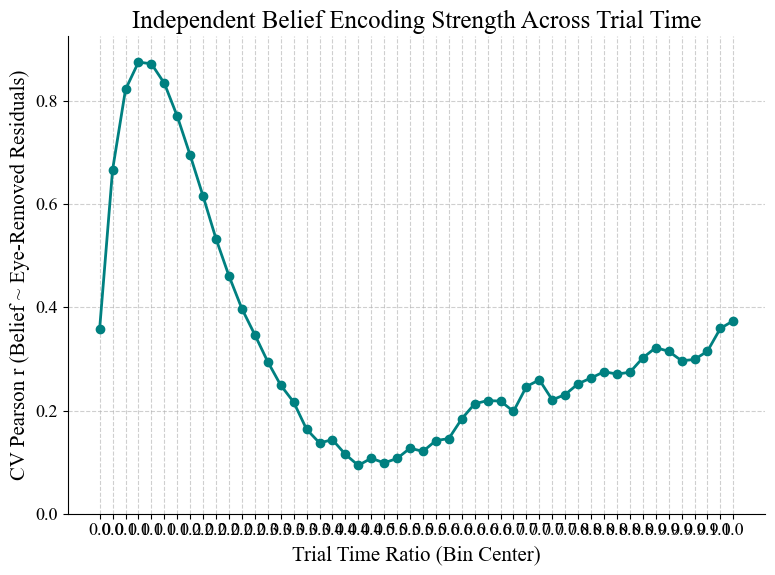


Time-Binned Analysis Complete.


In [87]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC', 'belief', 'eye', and 'timeratio'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     # Try to load placeholder if actual data not found
     print("Warning: DataFrame 'timedf' not found. Using placeholder data.")
     # --- Placeholder Data (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
     rng = np.random.default_rng(42)
     n_samples_orig = 50000 # Need more samples for binning
     n_features = 50      # Number of channels/neurons
     sampling_rate = 166 # Hz

     # Simulate time ratio cycling within trials (e.g., 100 samples per trial)
     samples_per_trial = 100
     n_trials = n_samples_orig // samples_per_trial
     n_samples_orig = n_trials * samples_per_trial # Adjust total samples
     timeratio_signal = np.tile(np.linspace(0, 1, samples_per_trial, endpoint=False), n_trials)

     belief_signal_true = normalize_z(rng.random(n_samples_orig) * 10)
     eye_signal_true = normalize_z(rng.random(n_samples_orig) * 5)
     # Make correlation vary with time ratio (stronger in middle)
     correlation_factor = 0.3 + 0.4 * np.sin(timeratio_signal * np.pi) # Stronger correlation (0.7) in middle (0.5)
     belief_signal_correlated = normalize_z( (1-correlation_factor) * belief_signal_true + correlation_factor * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     eye_signal_correlated = normalize_z( correlation_factor * belief_signal_true + (1-correlation_factor) * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))

     voltage_noise = rng.normal(0, 1.0, (n_samples_orig, n_features))
     belief_mod = belief_signal_correlated[:, np.newaxis] * 0.1 # Weaker belief component
     eye_mod = eye_signal_correlated[:, np.newaxis] * 0.3   # Stronger eye component
     neural_data_raw_voltage_sim = voltage_noise + belief_mod + eye_mod

     timedf = pd.DataFrame({
         'PPC': list(neural_data_raw_voltage_sim),
         'belief': belief_signal_correlated,
         'eye': eye_signal_correlated,
         'timeratio': timeratio_signal
     })
     # --- End Placeholder Data ---
else:
    print("Using provided 'timedf' DataFrame.")


# --- Parameters ---
sampling_rate = 166 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers
gaussian_sigma_samples = 5 # Std deviation of Gaussian kernel in SAMPLES
n_time_bins = 50 # Number of bins for timeratio (e.g., 5 bins: 0-0.2, 0.2-0.4, ...)
min_samples_per_bin = 50 # Minimum samples required in a bin for analysis

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
try:
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy())
    belief_data_present_raw = timedf['belief'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    timeratio_raw = timedf['timeratio'].to_numpy() # Extract timeratio
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, Belief={belief_data_present_raw.shape}, Eye={eye_data_present_raw.shape}, TimeRatio={timeratio_raw.shape}")

    # Basic shape checks
    if not (neural_data_raw_voltage.shape[0] == belief_data_present_raw.shape[0] == eye_data_present_raw.shape[0] == timeratio_raw.shape[0]):
        raise ValueError("Mismatch in number of samples between neural ('PPC'), belief, eye, or timeratio data.")

except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'belief', 'eye', and 'timeratio' exist.")
except Exception as e:
    raise TypeError(f"Error processing data columns. Ensure they contain stackable numerical data. Error: {e}")


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0) # Replace NaN/Inf with 0 before scaling
    scaler = StandardScaler()
    if np.std(data) < 1e-9:
        print("Warning: Standard deviation is zero during normalization. Returning zeros.")
        return np.zeros_like(data)
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

# --- Normalize Behavioral Data Globally ---
print("\n--- Normalizing Behavioral Data (Globally) ---")
belief_data_normalized = normalize_z(belief_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)

# --- Outlier Removal (Based on Normalized Belief & Eye) ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev for Belief & Eye) ---")
task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized]).T
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

# Apply mask to all data types that need to stay aligned
neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
belief_data_present = belief_data_normalized[mask_outliers]
eye_data_present = eye_data_normalized[mask_outliers]
timeratio_present = timeratio_raw[mask_outliers] # Keep timeratio aligned

n_removed = len(belief_data_present_raw) - len(belief_data_present)
print(f"Removed {n_removed} outlier trials/samples ({n_removed / len(belief_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, Belief={belief_data_present.shape}, Eye={eye_data_present.shape}, TimeRatio={timeratio_present.shape}")

if len(belief_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")

# =============================================================================
# Gaussian Smoothing of Cleaned Raw Voltage Data
# =============================================================================
print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---")
neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_cleaned,
                                         sigma=gaussian_sigma_samples,
                                         axis=0,
                                         mode='reflect')
print("Gaussian smoothing complete.")

# =============================================================================
# Z-score Smoothed Data Per Channel Globally
# =============================================================================
print("Z-scoring smoothed data per channel (Globally)...")
scaler_smooth = StandardScaler()
neural_data_processed = np.zeros_like(neural_data_smoothed)
for i in range(neural_data_smoothed.shape[1]):
    channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9:
        neural_data_processed[:, i] = scaler_smooth.fit_transform(channel_data).flatten()
    else:
        print(f"Warning: Channel {i} has zero standard deviation after smoothing. Outputting zeros.")
print("Z-scoring complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")


# =============================================================================
# Time-Binned Residual Analysis (Strategy 2, Part A with CV)
# =============================================================================
print(f"\n--- Time-Binned Residual Analysis ({n_time_bins} bins) ---")

# Define time bins
bin_edges = np.linspace(0, 1, n_time_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
results_r = [] # To store Pearson r for each bin
results_r2 = [] # To store R-squared for each bin
actual_bin_centers = [] # Store centers only for bins with enough data

# Initialize the base model and CV strategy
lr_model = LinearRegression()
n_splits = 5 # CV folds within each bin

for i in range(n_time_bins):
    bin_start = bin_edges[i]
    bin_end = bin_edges[i+1]
    # For the last bin, make sure it includes 1.0 exactly if timeratio can reach 1
    is_last_bin = (i == n_time_bins - 1)
    if is_last_bin:
        bin_mask = (timeratio_present >= bin_start) & (timeratio_present <= bin_end)
    else:
        bin_mask = (timeratio_present >= bin_start) & (timeratio_present < bin_end)

    print(f"\nProcessing Bin {i+1}/{n_time_bins} (TimeRatio: {bin_start:.2f} to {bin_end:.2f})...")

    # Select data for the current bin
    neural_bin = neural_data_processed[bin_mask]
    belief_bin = belief_data_present[bin_mask]
    eye_bin = eye_data_present[bin_mask]
    n_samples_in_bin = len(belief_bin)
    print(f"  Samples in bin: {n_samples_in_bin}")

    # Check if enough samples for analysis and CV
    if n_samples_in_bin < max(min_samples_per_bin, n_splits):
        print(f"  Skipping bin {i+1} due to insufficient samples (required: {max(min_samples_per_bin, n_splits)}).")
        results_r.append(np.nan)
        results_r2.append(np.nan)
        continue

    # --- Perform CV residual analysis within the bin ---
    eye_bin_2d = eye_bin.reshape(-1, 1)

    # Adjust n_splits if samples < 5 but >= 2
    current_n_splits = n_splits
    if n_samples_in_bin < current_n_splits:
        current_n_splits = max(2, n_samples_in_bin)
        print(f"  Adjusting CV folds to {current_n_splits} for this bin.")
    cv_bin = KFold(n_splits=current_n_splits, shuffle=True, random_state=42)

    # 1. Get CV predictions for Neural ~ Eye within bin
    predicted_neural_from_eye_cv_bin = cross_val_predict(lr_model, eye_bin_2d, neural_bin, cv=cv_bin)

    # 2. Calculate Residuals within bin
    residuals_bin = neural_bin - predicted_neural_from_eye_cv_bin

    # 3. Get CV predictions for Belief ~ Residuals within bin
    predicted_belief_from_residuals_cv_bin = cross_val_predict(lr_model, residuals_bin, belief_bin, cv=cv_bin)

    # 4. Evaluate Belief prediction for this bin
    r2_bin = r2_score(belief_bin, predicted_belief_from_residuals_cv_bin)
    # Check for valid data points for Pearson correlation
    valid_indices_bin = np.isfinite(belief_bin) & np.isfinite(predicted_belief_from_residuals_cv_bin)
    if np.sum(valid_indices_bin) < 2:
        print("  Warning: Not enough valid points in bin for Pearson correlation.")
        r_bin, p_bin = np.nan, np.nan
    else:
        r_bin, p_bin = pearsonr(belief_bin[valid_indices_bin], predicted_belief_from_residuals_cv_bin[valid_indices_bin])

    print(f"  CV R-squared (Residuals -> Belief): {r2_bin:.4f}")
    print(f"  CV Pearson r (Actual Belief vs Predicted): {r_bin:.4f}, p={p_bin:.2e}")

    results_r.append(r_bin)
    results_r2.append(r2_bin)
    actual_bin_centers.append(bin_centers[i])


# =============================================================================
# Plotting the Time-Binned Results
# =============================================================================
print("\n--- Plotting Time-Binned Results ---")
fig_timebin, ax_timebin = plt.subplots(figsize=(8, 6))

# Filter out NaN results if bins were skipped
valid_results_mask = ~np.isnan(results_r)
plot_centers = np.array(actual_bin_centers)
plot_r_values = np.array(results_r)[valid_results_mask]

if len(plot_centers) > 0:
    ax_timebin.plot(plot_centers, plot_r_values, marker='o', linestyle='-', color='teal')
    ax_timebin.set_xlabel('Trial Time Ratio (Bin Center)')
    ax_timebin.set_ylabel('CV Pearson r (Belief ~ Eye-Removed Residuals)')
    ax_timebin.set_title('Independent Belief Encoding Strength Across Trial Time')
    ax_timebin.set_ylim(bottom=min(0, np.nanmin(results_r) - 0.05), top=max(0.1, np.nanmax(results_r) + 0.05)) # Adjust y-limits
    ax_timebin.grid(True, linestyle='--', alpha=0.6)
    # Add horizontal line at 0
    ax_timebin.axhline(0, color='black', linewidth=0.5, linestyle='--')
    # Set x-ticks to be bin centers
    ax_timebin.set_xticks(bin_centers)
    ax_timebin.set_xticklabels([f"{c:.1f}" for c in bin_centers])

else:
    ax_timebin.text(0.5, 0.5, 'No valid data bins found for plotting.',
                    horizontalalignment='center', verticalalignment='center', transform=ax_timebin.transAxes)
    ax_timebin.set_xlabel('Trial Time Ratio (Bin Center)')
    ax_timebin.set_ylabel('CV Pearson r (Belief ~ Eye-Removed Residuals)')
    ax_timebin.set_title('Independent Belief Encoding Strength Across Trial Time')


plt.tight_layout()
plt.show()

print("\nTime-Binned Analysis Complete.")


Using provided 'timedf' DataFrame.
--- Extracting Raw Data from DataFrame ---
Initial shapes: Neural=(400117, 112), state=(400117,), Eye=(400117,), TimeRatio=(400117,)

--- Normalizing Behavioral Data (Globally) ---

--- Removing Outliers (Threshold: +/- 4 std dev for state & Eye) ---
Removed 386 outlier trials/samples (0.10%).
Data shape after cleaning: Neural=(399731, 112), state=(399731,), Eye=(399731,), TimeRatio=(399731,)

--- Applying Gaussian Smoothing (sigma = 5 samples) ---
Gaussian smoothing complete.
Z-scoring smoothed data per channel (Globally)...
Z-scoring complete.
Processed neural data shape: (399731, 112)

--- Time-Binned Residual Analysis (50 bins) ---

Processing Bin 1/50 (TimeRatio: 0.00 to 0.02)...
  Samples in bin: 9346
  CV R-squared (Residuals -> state): 0.1282
  CV Pearson r (Actual state vs Predicted): 0.3595, p=3.87e-283

Processing Bin 2/50 (TimeRatio: 0.02 to 0.04)...
  Samples in bin: 8598
  CV R-squared (Residuals -> state): 0.4443
  CV Pearson r (Actual 

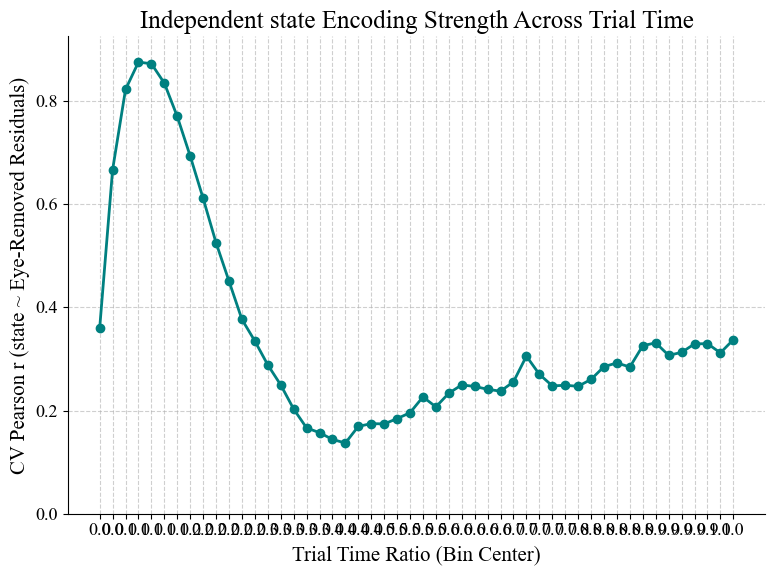


Time-Binned Analysis Complete.


In [88]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC', 'state', 'eye', and 'timeratio'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     # Try to load placeholder if actual data not found
     print("Warning: DataFrame 'timedf' not found. Using placeholder data.")
     # --- Placeholder Data (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
     rng = np.random.default_rng(42)
     n_samples_orig = 50000 # Need more samples for binning
     n_features = 50      # Number of channels/neurons
     sampling_rate = 166 # Hz

     # Simulate time ratio cycling within trials (e.g., 100 samples per trial)
     samples_per_trial = 100
     n_trials = n_samples_orig // samples_per_trial
     n_samples_orig = n_trials * samples_per_trial # Adjust total samples
     timeratio_signal = np.tile(np.linspace(0, 1, samples_per_trial, endpoint=False), n_trials)

     state_signal_true = normalize_z(rng.random(n_samples_orig) * 10)
     eye_signal_true = normalize_z(rng.random(n_samples_orig) * 5)
     # Make correlation vary with time ratio (stronger in middle)
     correlation_factor = 0.3 + 0.4 * np.sin(timeratio_signal * np.pi) # Stronger correlation (0.7) in middle (0.5)
     state_signal_correlated = normalize_z( (1-correlation_factor) * state_signal_true + correlation_factor * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     eye_signal_correlated = normalize_z( correlation_factor * state_signal_true + (1-correlation_factor) * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))

     voltage_noise = rng.normal(0, 1.0, (n_samples_orig, n_features))
     state_mod = state_signal_correlated[:, np.newaxis] * 0.1 # Weaker state component
     eye_mod = eye_signal_correlated[:, np.newaxis] * 0.3   # Stronger eye component
     neural_data_raw_voltage_sim = voltage_noise + state_mod + eye_mod

     timedf = pd.DataFrame({
         'PPC': list(neural_data_raw_voltage_sim),
         'state': state_signal_correlated,
         'eye': eye_signal_correlated,
         'timeratio': timeratio_signal
     })
     # --- End Placeholder Data ---
else:
    print("Using provided 'timedf' DataFrame.")


# --- Parameters ---
sampling_rate = 166 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers
gaussian_sigma_samples = 5 # Std deviation of Gaussian kernel in SAMPLES
n_time_bins = 50 # Number of bins for timeratio (e.g., 5 bins: 0-0.2, 0.2-0.4, ...)
min_samples_per_bin = 50 # Minimum samples required in a bin for analysis

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
try:
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy())
    state_data_present_raw = timedf['state'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    timeratio_raw = timedf['timeratio'].to_numpy() # Extract timeratio
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, state={state_data_present_raw.shape}, Eye={eye_data_present_raw.shape}, TimeRatio={timeratio_raw.shape}")

    # Basic shape checks
    if not (neural_data_raw_voltage.shape[0] == state_data_present_raw.shape[0] == eye_data_present_raw.shape[0] == timeratio_raw.shape[0]):
        raise ValueError("Mismatch in number of samples between neural ('PPC'), state, eye, or timeratio data.")

except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'state', 'eye', and 'timeratio' exist.")
except Exception as e:
    raise TypeError(f"Error processing data columns. Ensure they contain stackable numerical data. Error: {e}")


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0) # Replace NaN/Inf with 0 before scaling
    scaler = StandardScaler()
    if np.std(data) < 1e-9:
        print("Warning: Standard deviation is zero during normalization. Returning zeros.")
        return np.zeros_like(data)
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

# --- Normalize Behavioral Data Globally ---
print("\n--- Normalizing Behavioral Data (Globally) ---")
state_data_normalized = normalize_z(state_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)

# --- Outlier Removal (Based on Normalized state & Eye) ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev for state & Eye) ---")
task_vars_normalized = np.vstack([state_data_normalized, eye_data_normalized]).T
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

# Apply mask to all data types that need to stay aligned
neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
state_data_present = state_data_normalized[mask_outliers]
eye_data_present = eye_data_normalized[mask_outliers]
timeratio_present = timeratio_raw[mask_outliers] # Keep timeratio aligned

n_removed = len(state_data_present_raw) - len(state_data_present)
print(f"Removed {n_removed} outlier trials/samples ({n_removed / len(state_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, state={state_data_present.shape}, Eye={eye_data_present.shape}, TimeRatio={timeratio_present.shape}")

if len(state_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")

# =============================================================================
# Gaussian Smoothing of Cleaned Raw Voltage Data
# =============================================================================
print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---")
neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_cleaned,
                                         sigma=gaussian_sigma_samples,
                                         axis=0,
                                         mode='reflect')
print("Gaussian smoothing complete.")

# =============================================================================
# Z-score Smoothed Data Per Channel Globally
# =============================================================================
print("Z-scoring smoothed data per channel (Globally)...")
scaler_smooth = StandardScaler()
neural_data_processed = np.zeros_like(neural_data_smoothed)
for i in range(neural_data_smoothed.shape[1]):
    channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9:
        neural_data_processed[:, i] = scaler_smooth.fit_transform(channel_data).flatten()
    else:
        print(f"Warning: Channel {i} has zero standard deviation after smoothing. Outputting zeros.")
print("Z-scoring complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")


# =============================================================================
# Time-Binned Residual Analysis (Strategy 2, Part A with CV)
# =============================================================================
print(f"\n--- Time-Binned Residual Analysis ({n_time_bins} bins) ---")

# Define time bins
bin_edges = np.linspace(0, 1, n_time_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
results_r = [] # To store Pearson r for each bin
results_r2 = [] # To store R-squared for each bin
actual_bin_centers = [] # Store centers only for bins with enough data

# Initialize the base model and CV strategy
lr_model = LinearRegression()
n_splits = 5 # CV folds within each bin

for i in range(n_time_bins):
    bin_start = bin_edges[i]
    bin_end = bin_edges[i+1]
    # For the last bin, make sure it includes 1.0 exactly if timeratio can reach 1
    is_last_bin = (i == n_time_bins - 1)
    if is_last_bin:
        bin_mask = (timeratio_present >= bin_start) & (timeratio_present <= bin_end)
    else:
        bin_mask = (timeratio_present >= bin_start) & (timeratio_present < bin_end)

    print(f"\nProcessing Bin {i+1}/{n_time_bins} (TimeRatio: {bin_start:.2f} to {bin_end:.2f})...")

    # Select data for the current bin
    neural_bin = neural_data_processed[bin_mask]
    state_bin = state_data_present[bin_mask]
    eye_bin = eye_data_present[bin_mask]
    n_samples_in_bin = len(state_bin)
    print(f"  Samples in bin: {n_samples_in_bin}")

    # Check if enough samples for analysis and CV
    if n_samples_in_bin < max(min_samples_per_bin, n_splits):
        print(f"  Skipping bin {i+1} due to insufficient samples (required: {max(min_samples_per_bin, n_splits)}).")
        results_r.append(np.nan)
        results_r2.append(np.nan)
        continue

    # --- Perform CV residual analysis within the bin ---
    eye_bin_2d = eye_bin.reshape(-1, 1)

    # Adjust n_splits if samples < 5 but >= 2
    current_n_splits = n_splits
    if n_samples_in_bin < current_n_splits:
        current_n_splits = max(2, n_samples_in_bin)
        print(f"  Adjusting CV folds to {current_n_splits} for this bin.")
    cv_bin = KFold(n_splits=current_n_splits, shuffle=True, random_state=42)

    # 1. Get CV predictions for Neural ~ Eye within bin
    predicted_neural_from_eye_cv_bin = cross_val_predict(lr_model, eye_bin_2d, neural_bin, cv=cv_bin)

    # 2. Calculate Residuals within bin
    residuals_bin = neural_bin - predicted_neural_from_eye_cv_bin

    # 3. Get CV predictions for state ~ Residuals within bin
    predicted_state_from_residuals_cv_bin = cross_val_predict(lr_model, residuals_bin, state_bin, cv=cv_bin)

    # 4. Evaluate state prediction for this bin
    r2_bin = r2_score(state_bin, predicted_state_from_residuals_cv_bin)
    # Check for valid data points for Pearson correlation
    valid_indices_bin = np.isfinite(state_bin) & np.isfinite(predicted_state_from_residuals_cv_bin)
    if np.sum(valid_indices_bin) < 2:
        print("  Warning: Not enough valid points in bin for Pearson correlation.")
        r_bin, p_bin = np.nan, np.nan
    else:
        r_bin, p_bin = pearsonr(state_bin[valid_indices_bin], predicted_state_from_residuals_cv_bin[valid_indices_bin])

    print(f"  CV R-squared (Residuals -> state): {r2_bin:.4f}")
    print(f"  CV Pearson r (Actual state vs Predicted): {r_bin:.4f}, p={p_bin:.2e}")

    results_r.append(r_bin)
    results_r2.append(r2_bin)
    actual_bin_centers.append(bin_centers[i])


# =============================================================================
# Plotting the Time-Binned Results
# =============================================================================
print("\n--- Plotting Time-Binned Results ---")
fig_timebin, ax_timebin = plt.subplots(figsize=(8, 6))

# Filter out NaN results if bins were skipped
valid_results_mask = ~np.isnan(results_r)
plot_centers = np.array(actual_bin_centers)
plot_r_values = np.array(results_r)[valid_results_mask]

if len(plot_centers) > 0:
    ax_timebin.plot(plot_centers, plot_r_values, marker='o', linestyle='-', color='teal')
    ax_timebin.set_xlabel('Trial Time Ratio (Bin Center)')
    ax_timebin.set_ylabel('CV Pearson r (state ~ Eye-Removed Residuals)')
    ax_timebin.set_title('Independent state Encoding Strength Across Trial Time')
    ax_timebin.set_ylim(bottom=min(0, np.nanmin(results_r) - 0.05), top=max(0.1, np.nanmax(results_r) + 0.05)) # Adjust y-limits
    ax_timebin.grid(True, linestyle='--', alpha=0.6)
    # Add horizontal line at 0
    ax_timebin.axhline(0, color='black', linewidth=0.5, linestyle='--')
    # Set x-ticks to be bin centers
    ax_timebin.set_xticks(bin_centers)
    ax_timebin.set_xticklabels([f"{c:.1f}" for c in bin_centers])

else:
    ax_timebin.text(0.5, 0.5, 'No valid data bins found for plotting.',
                    horizontalalignment='center', verticalalignment='center', transform=ax_timebin.transAxes)
    ax_timebin.set_xlabel('Trial Time Ratio (Bin Center)')
    ax_timebin.set_ylabel('CV Pearson r (state ~ Eye-Removed Residuals)')
    ax_timebin.set_title('Independent state Encoding Strength Across Trial Time')


plt.tight_layout()
plt.show()

print("\nTime-Binned Analysis Complete.")


Using provided 'timedf' DataFrame.
--- Extracting Raw Data from DataFrame ---
Initial shapes: Neural=(400117, 112), Belief=(400117,), Eye=(400117,), TimeRatio=(400117,)

--- Normalizing Behavioral Data (Globally) ---

--- Removing Outliers (Threshold: +/- 4 std dev for Belief & Eye) ---
Removed 607 outlier trials/samples (0.15%).
Data shape after cleaning: Neural=(399510, 112), Belief=(399510,), Eye=(399510,), TimeRatio=(399510,)

--- Applying Gaussian Smoothing (sigma = 5 samples) ---
Gaussian smoothing complete.
Z-scoring smoothed data per channel (Globally)...
Z-scoring complete.
Processed neural data shape: (399510, 112)

--- Time-Binned Analysis Comparison (50 bins) ---

Processing Bin 1/50 (TimeRatio: 0.00 to 0.02)...
  Samples in bin: 9346
  Calculating Total Belief Encoding (Neural -> Belief)...
    CV Pearson r (Total): 0.3592, p=1.03e-282
  Calculating Independent Belief Encoding (Residuals -> Belief)...
    CV Pearson r (Independent): 0.3589, p=4.42e-282

Processing Bin 2/50

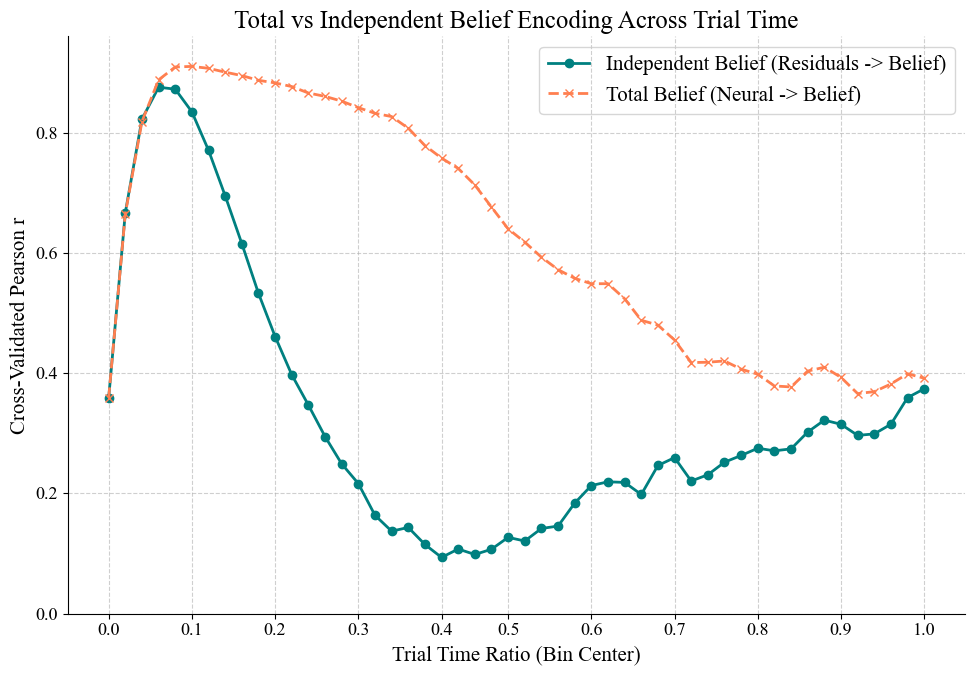


Time-Binned Comparison Analysis Complete.


In [89]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC', 'belief', 'eye', and 'timeratio'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     # Try to load placeholder if actual data not found
     print("Warning: DataFrame 'timedf' not found. Using placeholder data.")
     # --- Placeholder Data (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
     rng = np.random.default_rng(42)
     n_samples_orig = 50000 # Need more samples for binning
     n_features = 50      # Number of channels/neurons
     sampling_rate = 166 # Hz

     samples_per_trial = 100
     n_trials = n_samples_orig // samples_per_trial
     n_samples_orig = n_trials * samples_per_trial # Adjust total samples
     timeratio_signal = np.tile(np.linspace(0, 1, samples_per_trial, endpoint=False), n_trials)

     belief_signal_true = normalize_z(rng.random(n_samples_orig) * 10)
     eye_signal_true = normalize_z(rng.random(n_samples_orig) * 5)
     correlation_factor = 0.3 + 0.4 * np.sin(timeratio_signal * np.pi)
     belief_signal_correlated = normalize_z( (1-correlation_factor) * belief_signal_true + correlation_factor * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     eye_signal_correlated = normalize_z( correlation_factor * belief_signal_true + (1-correlation_factor) * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))

     voltage_noise = rng.normal(0, 1.0, (n_samples_orig, n_features))
     belief_mod = belief_signal_correlated[:, np.newaxis] * 0.1
     eye_mod = eye_signal_correlated[:, np.newaxis] * 0.3
     neural_data_raw_voltage_sim = voltage_noise + belief_mod + eye_mod

     timedf = pd.DataFrame({
         'PPC': list(neural_data_raw_voltage_sim),
         'belief': belief_signal_correlated,
         'eye': eye_signal_correlated,
         'timeratio': timeratio_signal
     })
     # --- End Placeholder Data ---
else:
    print("Using provided 'timedf' DataFrame.")


# --- Parameters ---
sampling_rate = 166 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers
gaussian_sigma_samples = 5 # Std deviation of Gaussian kernel in SAMPLES
n_time_bins = 50 # Number of bins for timeratio (Adjust if needed)
min_samples_per_bin = 50 # Minimum samples required in a bin for analysis

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
try:
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy())
    belief_data_present_raw = timedf['belief'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    timeratio_raw = timedf['timeratio'].to_numpy() # Extract timeratio
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, Belief={belief_data_present_raw.shape}, Eye={eye_data_present_raw.shape}, TimeRatio={timeratio_raw.shape}")

    if not (neural_data_raw_voltage.shape[0] == belief_data_present_raw.shape[0] == eye_data_present_raw.shape[0] == timeratio_raw.shape[0]):
        raise ValueError("Mismatch in number of samples between neural ('PPC'), belief, eye, or timeratio data.")

except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'belief', 'eye', and 'timeratio' exist.")
except Exception as e:
    raise TypeError(f"Error processing data columns. Ensure they contain stackable numerical data. Error: {e}")


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0) # Replace NaN/Inf with 0 before scaling
    scaler = StandardScaler()
    if np.std(data) < 1e-9:
        print("Warning: Standard deviation is zero during normalization. Returning zeros.")
        return np.zeros_like(data)
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

# --- Normalize Behavioral Data Globally ---
print("\n--- Normalizing Behavioral Data (Globally) ---")
belief_data_normalized = normalize_z(belief_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)

# --- Outlier Removal (Based on Normalized Belief & Eye) ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev for Belief & Eye) ---")
task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized]).T
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
belief_data_present = belief_data_normalized[mask_outliers]
eye_data_present = eye_data_normalized[mask_outliers]
timeratio_present = timeratio_raw[mask_outliers]

n_removed = len(belief_data_present_raw) - len(belief_data_present)
print(f"Removed {n_removed} outlier trials/samples ({n_removed / len(belief_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, Belief={belief_data_present.shape}, Eye={eye_data_present.shape}, TimeRatio={timeratio_present.shape}")

if len(belief_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")

# =============================================================================
# Gaussian Smoothing of Cleaned Raw Voltage Data
# =============================================================================
print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---")
neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_cleaned,
                                         sigma=gaussian_sigma_samples,
                                         axis=0,
                                         mode='reflect')
print("Gaussian smoothing complete.")

# =============================================================================
# Z-score Smoothed Data Per Channel Globally
# =============================================================================
print("Z-scoring smoothed data per channel (Globally)...")
scaler_smooth = StandardScaler()
neural_data_processed = np.zeros_like(neural_data_smoothed)
for i in range(neural_data_smoothed.shape[1]):
    channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9:
        neural_data_processed[:, i] = scaler_smooth.fit_transform(channel_data).flatten()
    else:
        print(f"Warning: Channel {i} has zero standard deviation after smoothing. Outputting zeros.")
print("Z-scoring complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")


# =============================================================================
# Time-Binned Analysis Comparison
# =============================================================================
print(f"\n--- Time-Binned Analysis Comparison ({n_time_bins} bins) ---")

# Define time bins
bin_edges = np.linspace(0, 1, n_time_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
results_r_independent = [] # Pearson r for Residuals -> Belief
results_r_total = []       # Pearson r for Neural -> Belief
actual_bin_centers = []    # Store centers only for bins with enough data

# Initialize the base model and CV strategy
lr_model = LinearRegression()
n_splits = 5 # CV folds within each bin

for i in range(n_time_bins):
    bin_start = bin_edges[i]
    bin_end = bin_edges[i+1]
    is_last_bin = (i == n_time_bins - 1)
    if is_last_bin:
        bin_mask = (timeratio_present >= bin_start) & (timeratio_present <= bin_end)
    else:
        bin_mask = (timeratio_present >= bin_start) & (timeratio_present < bin_end)

    print(f"\nProcessing Bin {i+1}/{n_time_bins} (TimeRatio: {bin_start:.2f} to {bin_end:.2f})...")

    # Select data for the current bin
    neural_bin = neural_data_processed[bin_mask]
    belief_bin = belief_data_present[bin_mask]
    eye_bin = eye_data_present[bin_mask]
    n_samples_in_bin = len(belief_bin)
    print(f"  Samples in bin: {n_samples_in_bin}")

    # Check if enough samples for analysis and CV
    if n_samples_in_bin < max(min_samples_per_bin, n_splits):
        print(f"  Skipping bin {i+1} due to insufficient samples (required: {max(min_samples_per_bin, n_splits)}).")
        results_r_independent.append(np.nan)
        results_r_total.append(np.nan)
        continue

    # --- Perform CV analyses within the bin ---
    eye_bin_2d = eye_bin.reshape(-1, 1)

    # Adjust n_splits if samples < 5 but >= 2
    current_n_splits = n_splits
    if n_samples_in_bin < current_n_splits:
        current_n_splits = max(2, n_samples_in_bin)
        print(f"  Adjusting CV folds to {current_n_splits} for this bin.")
    cv_bin = KFold(n_splits=current_n_splits, shuffle=True, random_state=42)

    # --- 1. Total Belief Encoding (Neural -> Belief) ---
    print("  Calculating Total Belief Encoding (Neural -> Belief)...")
    predicted_belief_total_cv_bin = cross_val_predict(lr_model, neural_bin, belief_bin, cv=cv_bin)
    valid_indices_total = np.isfinite(belief_bin) & np.isfinite(predicted_belief_total_cv_bin)
    if np.sum(valid_indices_total) < 2:
        r_total_bin, p_total_bin = np.nan, np.nan
    else:
        r_total_bin, p_total_bin = pearsonr(belief_bin[valid_indices_total], predicted_belief_total_cv_bin[valid_indices_total])
    print(f"    CV Pearson r (Total): {r_total_bin:.4f}, p={p_total_bin:.2e}")
    results_r_total.append(r_total_bin)


    # --- 2. Independent Belief Encoding (Residuals -> Belief) ---
    print("  Calculating Independent Belief Encoding (Residuals -> Belief)...")
    # a. Get CV predictions for Neural ~ Eye within bin
    predicted_neural_from_eye_cv_bin = cross_val_predict(lr_model, eye_bin_2d, neural_bin, cv=cv_bin)
    # b. Calculate Residuals within bin
    residuals_bin = neural_bin - predicted_neural_from_eye_cv_bin
    # c. Get CV predictions for Belief ~ Residuals within bin
    predicted_belief_independent_cv_bin = cross_val_predict(lr_model, residuals_bin, belief_bin, cv=cv_bin)
    # d. Evaluate Belief prediction for this bin
    valid_indices_independent = np.isfinite(belief_bin) & np.isfinite(predicted_belief_independent_cv_bin)
    if np.sum(valid_indices_independent) < 2:
        r_independent_bin, p_independent_bin = np.nan, np.nan
    else:
        r_independent_bin, p_independent_bin = pearsonr(belief_bin[valid_indices_independent], predicted_belief_independent_cv_bin[valid_indices_independent])
    print(f"    CV Pearson r (Independent): {r_independent_bin:.4f}, p={p_independent_bin:.2e}")
    results_r_independent.append(r_independent_bin)

    # Store bin center if calculations were successful
    actual_bin_centers.append(bin_centers[i])


# =============================================================================
# Plotting the Time-Binned Comparison
# =============================================================================
print("\n--- Plotting Time-Binned Comparison ---")
fig_timebin_comp, ax_timebin_comp = plt.subplots(figsize=(10, 7)) # Slightly wider plot

# Filter out NaN results if bins were skipped
valid_results_mask = ~np.isnan(results_r_independent) & ~np.isnan(results_r_total) # Ensure both are valid
plot_centers = np.array(actual_bin_centers)
plot_r_independent = np.array(results_r_independent)[valid_results_mask]
plot_r_total = np.array(results_r_total)[valid_results_mask]

if len(plot_centers) > 0:
    # Plot Independent Belief Encoding (Residuals -> Belief)
    ax_timebin_comp.plot(plot_centers, plot_r_independent, marker='o', linestyle='-', color='teal', label='Independent Belief (Residuals -> Belief)')
    # Plot Total Belief Encoding (Neural -> Belief)
    ax_timebin_comp.plot(plot_centers, plot_r_total, marker='x', linestyle='--', color='coral', label='Total Belief (Neural -> Belief)')

    ax_timebin_comp.set_xlabel('Trial Time Ratio (Bin Center)')
    ax_timebin_comp.set_ylabel('Cross-Validated Pearson r')
    ax_timebin_comp.set_title('Total vs Independent Belief Encoding Across Trial Time')
    # Adjust y-limits based on the range of both plots
    min_y = min(0, np.nanmin(results_r_independent) - 0.05, np.nanmin(results_r_total) - 0.05)
    max_y = max(0.1, np.nanmax(results_r_independent) + 0.05, np.nanmax(results_r_total) + 0.05)
    ax_timebin_comp.set_ylim(bottom=min_y, top=max_y)
    ax_timebin_comp.grid(True, linestyle='--', alpha=0.6)
    # Add horizontal line at 0
    ax_timebin_comp.axhline(0, color='black', linewidth=0.5, linestyle='--')
    # Set x-ticks to be bin centers (maybe fewer ticks if too cluttered)
    tick_indices = np.round(np.linspace(0, len(bin_centers)-1, 11)).astype(int) # Show ~11 ticks
    ax_timebin_comp.set_xticks(bin_centers[tick_indices])
    ax_timebin_comp.set_xticklabels([f"{c:.1f}" for c in bin_centers[tick_indices]])
    ax_timebin_comp.legend()

else:
    ax_timebin_comp.text(0.5, 0.5, 'No valid data bins found for plotting.',
                    horizontalalignment='center', verticalalignment='center', transform=ax_timebin_comp.transAxes)
    ax_timebin_comp.set_xlabel('Trial Time Ratio (Bin Center)')
    ax_timebin_comp.set_ylabel('Cross-Validated Pearson r')
    ax_timebin_comp.set_title('Total vs Independent Belief Encoding Across Trial Time')


plt.tight_layout()
plt.show()

print("\nTime-Binned Comparison Analysis Complete.")


Using provided 'timedf' DataFrame.
--- Extracting Raw Data from DataFrame ---
Initial shapes: Neural=(400117, 112), Belief=(400117,), Eye=(400117,)

--- Normalizing Behavioral Data (Globally) ---

--- Removing Outliers (Threshold: +/- 4 std dev for Belief & Eye) ---
Removed 607 outlier trials/samples (0.15%).
Data shape after cleaning: Neural=(399510, 112), Belief=(399510,), Eye=(399510,)

--- Calculating Absolute Belief-Eye Difference ---
  Range of difference: 0.00 to 5.53

--- Applying Gaussian Smoothing (sigma = 5 samples) ---
Gaussian smoothing complete.
Z-scoring smoothed data per channel (Globally)...
Z-scoring complete.
Processed neural data shape: (399510, 112)

--- Belief-Eye Difference Binned Analysis Comparison (20 bins) ---

Processing Bin 1/20 (Belief-Eye Diff: 0.00 to 0.28)...
  Samples in bin: 110931
  Calculating Total Belief Encoding (Neural -> Belief)...
    CV Pearson r (Total): 0.5937
  Calculating Independent Belief Encoding (Residuals -> Belief)...
    CV Pearson

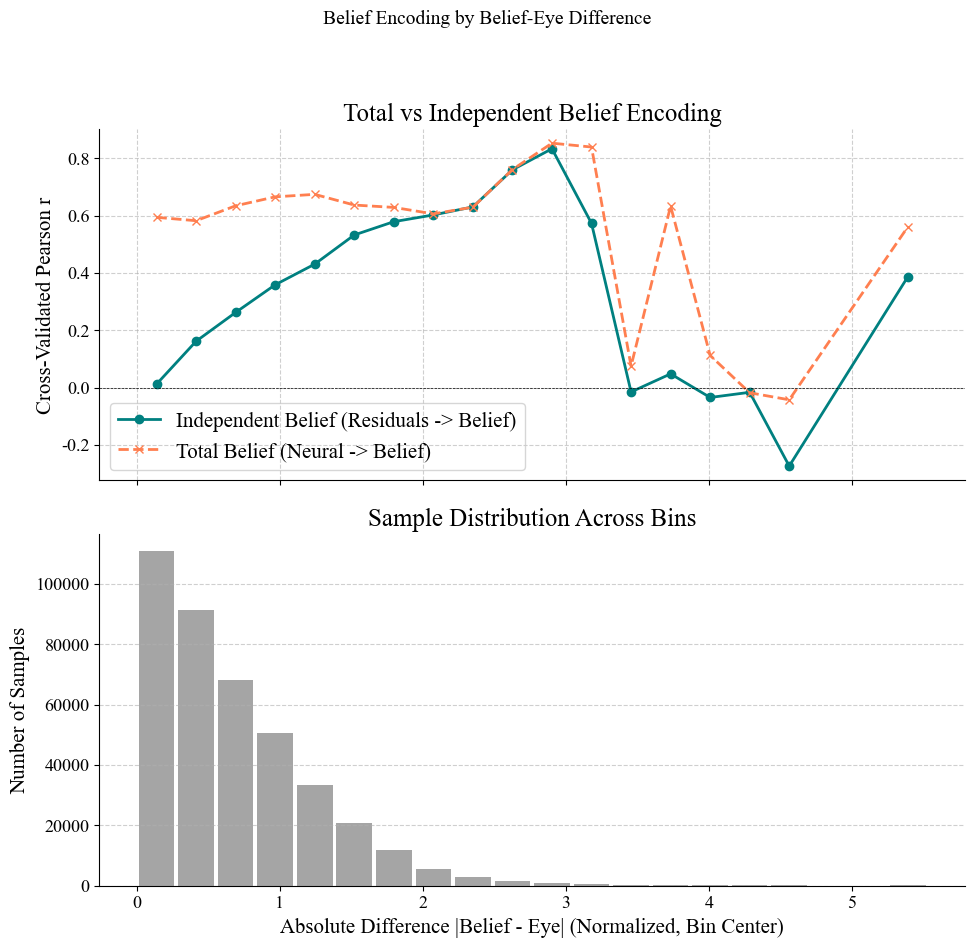


Belief-Eye Difference Binned Analysis Complete.


In [93]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC', 'belief', and 'eye'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     # Try to load placeholder if actual data not found
     print("Warning: DataFrame 'timedf' not found. Using placeholder data.")
     # --- Placeholder Data (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
     rng = np.random.default_rng(42)
     n_samples_orig = 50000 # Use a decent number of samples
     n_features = 50      # Number of channels/neurons
     sampling_rate = 166 # Hz

     belief_signal_true = normalize_z(rng.random(n_samples_orig) * 10)
     eye_signal_true = normalize_z(rng.random(n_samples_orig) * 5)
     # Simulate varying correlation - let's make it random per sample for simplicity here
     correlation_factor = rng.uniform(0.1, 0.8, n_samples_orig)
     belief_signal_correlated = normalize_z( (1-correlation_factor) * belief_signal_true + correlation_factor * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     eye_signal_correlated = normalize_z( correlation_factor * belief_signal_true + (1-correlation_factor) * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))

     voltage_noise = rng.normal(0, 1.0, (n_samples_orig, n_features))
     belief_mod = belief_signal_correlated[:, np.newaxis] * 0.1
     eye_mod = eye_signal_correlated[:, np.newaxis] * 0.3
     neural_data_raw_voltage_sim = voltage_noise + belief_mod + eye_mod

     timedf = pd.DataFrame({
         'PPC': list(neural_data_raw_voltage_sim),
         'belief': belief_signal_correlated,
         'eye': eye_signal_correlated
         # No timeratio needed for this version
     })
     # --- End Placeholder Data ---
else:
    print("Using provided 'timedf' DataFrame.")


# --- Parameters ---
sampling_rate = 166 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers
gaussian_sigma_samples = 5 # Std deviation of Gaussian kernel in SAMPLES
n_diff_bins = 20 # Number of bins for belief-eye difference (Adjust as needed)
min_samples_per_bin = 50 # Minimum samples required in a bin for analysis

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
try:
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy())
    belief_data_present_raw = timedf['belief'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, Belief={belief_data_present_raw.shape}, Eye={eye_data_present_raw.shape}")

    if not (neural_data_raw_voltage.shape[0] == belief_data_present_raw.shape[0] == eye_data_present_raw.shape[0]):
        raise ValueError("Mismatch in number of samples between neural ('PPC'), belief, or eye data.")

except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'belief', 'eye' exist.")
except Exception as e:
    raise TypeError(f"Error processing data columns. Ensure they contain stackable numerical data. Error: {e}")


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0) # Replace NaN/Inf with 0 before scaling
    scaler = StandardScaler()
    if np.std(data) < 1e-9:
        print("Warning: Standard deviation is zero during normalization. Returning zeros.")
        return np.zeros_like(data)
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

# --- Normalize Behavioral Data Globally ---
print("\n--- Normalizing Behavioral Data (Globally) ---")
belief_data_normalized = normalize_z(belief_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)

# --- Outlier Removal (Based on Normalized Belief & Eye) ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev for Belief & Eye) ---")
task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized]).T
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

# Apply mask to all data types that need to stay aligned
neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
belief_data_present = belief_data_normalized[mask_outliers]
eye_data_present = eye_data_normalized[mask_outliers]

n_removed = len(belief_data_present_raw) - len(belief_data_present)
print(f"Removed {n_removed} outlier trials/samples ({n_removed / len(belief_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, Belief={belief_data_present.shape}, Eye={eye_data_present.shape}")

if len(belief_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")

# =============================================================================
# Calculate Belief-Eye Difference
# =============================================================================
print("\n--- Calculating Absolute Belief-Eye Difference ---")
belief_eye_diff = np.abs(belief_data_present - eye_data_present)
print(f"  Range of difference: {np.min(belief_eye_diff):.2f} to {np.max(belief_eye_diff):.2f}")

# =============================================================================
# Gaussian Smoothing of Cleaned Raw Voltage Data
# =============================================================================
print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---")
neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_cleaned,
                                         sigma=gaussian_sigma_samples,
                                         axis=0,
                                         mode='reflect')
print("Gaussian smoothing complete.")

# =============================================================================
# Z-score Smoothed Data Per Channel Globally
# =============================================================================
print("Z-scoring smoothed data per channel (Globally)...")
scaler_smooth = StandardScaler()
neural_data_processed = np.zeros_like(neural_data_smoothed)
for i in range(neural_data_smoothed.shape[1]):
    channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9:
        neural_data_processed[:, i] = scaler_smooth.fit_transform(channel_data).flatten()
    else:
        print(f"Warning: Channel {i} has zero standard deviation after smoothing. Outputting zeros.")
print("Z-scoring complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")


# =============================================================================
# Belief-Eye Difference Binned Analysis Comparison
# =============================================================================
print(f"\n--- Belief-Eye Difference Binned Analysis Comparison ({n_diff_bins} bins) ---")

# Define difference bins (linear spacing)
min_diff = np.min(belief_eye_diff)
max_diff = np.max(belief_eye_diff)
# Add a small epsilon to max_diff to ensure the max value is included
bin_edges = np.linspace(min_diff, max_diff + 1e-9, n_diff_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

results_r_independent = [] # Pearson r for Residuals -> Belief
results_r_total = []       # Pearson r for Neural -> Belief
actual_bin_centers = []    # Store centers only for bins with enough data
samples_in_bins = []       # Store sample count per bin

# Initialize the base model and CV strategy
lr_model = LinearRegression()
n_splits = 5 # CV folds within each bin

for i in range(n_diff_bins):
    bin_start = bin_edges[i]
    bin_end = bin_edges[i+1]
    # Mask based on belief_eye_diff
    bin_mask = (belief_eye_diff >= bin_start) & (belief_eye_diff < bin_end)

    print(f"\nProcessing Bin {i+1}/{n_diff_bins} (Belief-Eye Diff: {bin_start:.2f} to {bin_end:.2f})...")

    # Select data for the current bin
    neural_bin = neural_data_processed[bin_mask]
    belief_bin = belief_data_present[bin_mask]
    eye_bin = eye_data_present[bin_mask]
    n_samples_in_bin = len(belief_bin)
    samples_in_bins.append(n_samples_in_bin) # Store sample count regardless of whether bin is processed
    print(f"  Samples in bin: {n_samples_in_bin}")

    # Check if enough samples for analysis and CV
    if n_samples_in_bin < max(min_samples_per_bin, n_splits):
        print(f"  Skipping bin {i+1} due to insufficient samples (required: {max(min_samples_per_bin, n_splits)}).")
        results_r_independent.append(np.nan)
        results_r_total.append(np.nan)
        continue # Skip to next bin

    # --- Perform CV analyses within the bin ---
    eye_bin_2d = eye_bin.reshape(-1, 1)

    # Adjust n_splits if samples < 5 but >= 2
    current_n_splits = n_splits
    if n_samples_in_bin < current_n_splits:
        current_n_splits = max(2, n_samples_in_bin)
        print(f"  Adjusting CV folds to {current_n_splits} for this bin.")
    cv_bin = KFold(n_splits=current_n_splits, shuffle=True, random_state=42)

    # --- 1. Total Belief Encoding (Neural -> Belief) ---
    print("  Calculating Total Belief Encoding (Neural -> Belief)...")
    predicted_belief_total_cv_bin = cross_val_predict(lr_model, neural_bin, belief_bin, cv=cv_bin)
    valid_indices_total = np.isfinite(belief_bin) & np.isfinite(predicted_belief_total_cv_bin)
    if np.sum(valid_indices_total) < 2:
        r_total_bin = np.nan # Assign NaN if correlation cannot be computed
    else:
        # Use try-except for pearsonr as it can fail with constant arrays
        try:
            r_total_bin, _ = pearsonr(belief_bin[valid_indices_total], predicted_belief_total_cv_bin[valid_indices_total])
        except ValueError:
             r_total_bin = np.nan
    print(f"    CV Pearson r (Total): {r_total_bin:.4f}")
    results_r_total.append(r_total_bin)


    # --- 2. Independent Belief Encoding (Residuals -> Belief) ---
    print("  Calculating Independent Belief Encoding (Residuals -> Belief)...")
    try:
        # a. Get CV predictions for Neural ~ Eye within bin
        predicted_neural_from_eye_cv_bin = cross_val_predict(lr_model, eye_bin_2d, neural_bin, cv=cv_bin)
        # b. Calculate Residuals within bin
        residuals_bin = neural_bin - predicted_neural_from_eye_cv_bin
        # c. Get CV predictions for Belief ~ Residuals within bin
        predicted_belief_independent_cv_bin = cross_val_predict(lr_model, residuals_bin, belief_bin, cv=cv_bin)
        # d. Evaluate Belief prediction for this bin
        valid_indices_independent = np.isfinite(belief_bin) & np.isfinite(predicted_belief_independent_cv_bin)
        if np.sum(valid_indices_independent) < 2:
            r_independent_bin = np.nan
        else:
            r_independent_bin, _ = pearsonr(belief_bin[valid_indices_independent], predicted_belief_independent_cv_bin[valid_indices_independent])

    except ValueError as e:
        # Catch potential errors during CV or correlation if data in bin is problematic
        print(f"    Error during independent calculation for bin {i+1}: {e}. Assigning NaN.")
        r_independent_bin = np.nan

    print(f"    CV Pearson r (Independent): {r_independent_bin:.4f}")
    results_r_independent.append(r_independent_bin)

    # Store bin center only if both calculations were successful (not NaN)
    if not np.isnan(r_total_bin) and not np.isnan(r_independent_bin):
        actual_bin_centers.append(bin_centers[i])
    else:
        # If one failed, ensure the corresponding value in the other list is also NaN for plotting alignment
        if np.isnan(r_total_bin) and not np.isnan(r_independent_bin): results_r_independent[-1] = np.nan
        if not np.isnan(r_total_bin) and np.isnan(r_independent_bin): results_r_total[-1] = np.nan


# =============================================================================
# Plotting the Belief-Eye Difference Binned Comparison (Separate Plots)
# =============================================================================
print("\n--- Plotting Belief-Eye Difference Binned Comparison (Separate Plots) ---")
# Create figure with 2 subplots, sharing the x-axis
fig_diffbin_sep, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
fig_diffbin_sep.suptitle('Belief Encoding by Belief-Eye Difference', fontsize=14)

# --- Plot 1: Correlation Curves ---
ax_corr = axes[0]

# Filter out NaN results from skipped or failed bins for plotting
valid_results_mask = ~np.isnan(results_r_independent) & ~np.isnan(results_r_total)
# Ensure actual_bin_centers only contains centers where results are valid
# Note: actual_bin_centers is already built correctly based on successful calculations
plot_centers = np.array(actual_bin_centers)
# Filter the results arrays using the mask derived *before* appending NaNs for skipped bins
# Need to re-filter results based on the valid centers we have
plot_r_independent = np.array([r for r, mask in zip(results_r_independent, ~np.isnan(results_r_independent)) if mask])
plot_r_total = np.array([r for r, mask in zip(results_r_total, ~np.isnan(results_r_total)) if mask])

# Ensure lengths match after filtering potential NaNs from calculation errors
min_len = min(len(plot_centers), len(plot_r_independent), len(plot_r_total))
plot_centers = plot_centers[:min_len]
plot_r_independent = plot_r_independent[:min_len]
plot_r_total = plot_r_total[:min_len]


if len(plot_centers) > 0:
    # Plot Independent Belief Encoding (Residuals -> Belief)
    ax_corr.plot(plot_centers, plot_r_independent, marker='o', linestyle='-', color='teal', label='Independent Belief (Residuals -> Belief)')
    # Plot Total Belief Encoding (Neural -> Belief)
    ax_corr.plot(plot_centers, plot_r_total, marker='x', linestyle='--', color='coral', label='Total Belief (Neural -> Belief)')

    ax_corr.set_ylabel('Cross-Validated Pearson r')
    ax_corr.set_title('Total vs Independent Belief Encoding')
    # Adjust y-limits based on the range of both plots
    min_y = min(0, np.nanmin(plot_r_independent) - 0.05, np.nanmin(plot_r_total) - 0.05) if len(plot_r_independent)>0 and len(plot_r_total)>0 else 0
    max_y = max(0.1, np.nanmax(plot_r_independent) + 0.05, np.nanmax(plot_r_total) + 0.05) if len(plot_r_independent)>0 and len(plot_r_total)>0 else 0.1
    ax_corr.set_ylim(bottom=min_y, top=max_y)
    ax_corr.grid(True, linestyle='--', alpha=0.6)
    # Add horizontal line at 0
    ax_corr.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax_corr.legend()

else:
    ax_corr.text(0.5, 0.5, 'No valid data bins found for plotting correlations.',
                    horizontalalignment='center', verticalalignment='center', transform=ax_corr.transAxes)
    ax_corr.set_ylabel('Cross-Validated Pearson r')
    ax_corr.set_title('Total vs Independent Belief Encoding')


# --- Plot 2: Sample Count Histogram ---
ax_hist = axes[1]

if len(samples_in_bins) > 0:
    ax_hist.bar(bin_centers, samples_in_bins, width=(bin_edges[1]-bin_edges[0])*0.9, color='gray', alpha=0.7)
    ax_hist.set_xlabel('Absolute Difference |Belief - Eye| (Normalized, Bin Center)')
    ax_hist.set_ylabel('Number of Samples')
    ax_hist.set_title('Sample Distribution Across Bins')
    ax_hist.set_ylim(bottom=0) # Start samples axis at 0
    ax_hist.grid(True, axis='y', linestyle='--', alpha=0.6) # Grid only on y-axis
else:
     ax_hist.text(0.5, 0.5, 'No bins processed.',
                    horizontalalignment='center', verticalalignment='center', transform=ax_hist.transAxes)
     ax_hist.set_xlabel('Absolute Difference |Belief - Eye| (Normalized, Bin Center)')
     ax_hist.set_ylabel('Number of Samples')
     ax_hist.set_title('Sample Distribution Across Bins')


plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

print("\nBelief-Eye Difference Binned Analysis Complete.")


Using provided 'timedf' DataFrame.
--- Extracting Raw Data from DataFrame ---
Initial shapes: Neural=(400117, 112), Belief=(400117,), Eye=(400117,), TimeRatio=(400117,)

--- Normalizing Behavioral Data (Globally) ---

--- Removing Outliers (Threshold: +/- 4 std dev for Belief & Eye) ---
Removed 607 outlier trials/samples (0.15%).
Data shape after cleaning: Neural=(399510, 112), Belief=(399510,), Eye=(399510,), TimeRatio=(399510,)

--- Calculating Absolute Belief-Eye Difference & Applying Cutoff ---
  Applying cutoff: Keeping differences <= 4.00
  Removed 329 samples due to difference cutoff (0.08% of cleaned data).
Data shape after difference cutoff: Neural=(399181, 112), Belief=(399181,), Eye=(399181,), TimeRatio=(399181,)

--- Applying Gaussian Smoothing (sigma = 5 samples) ---
Gaussian smoothing complete.
Z-scoring smoothed data per channel (Globally)...
Z-scoring complete.
Processed neural data shape: (399181, 112)

--- 2D Binned Analysis for 3D Plot (Time: 20 bins, Difference: 10 

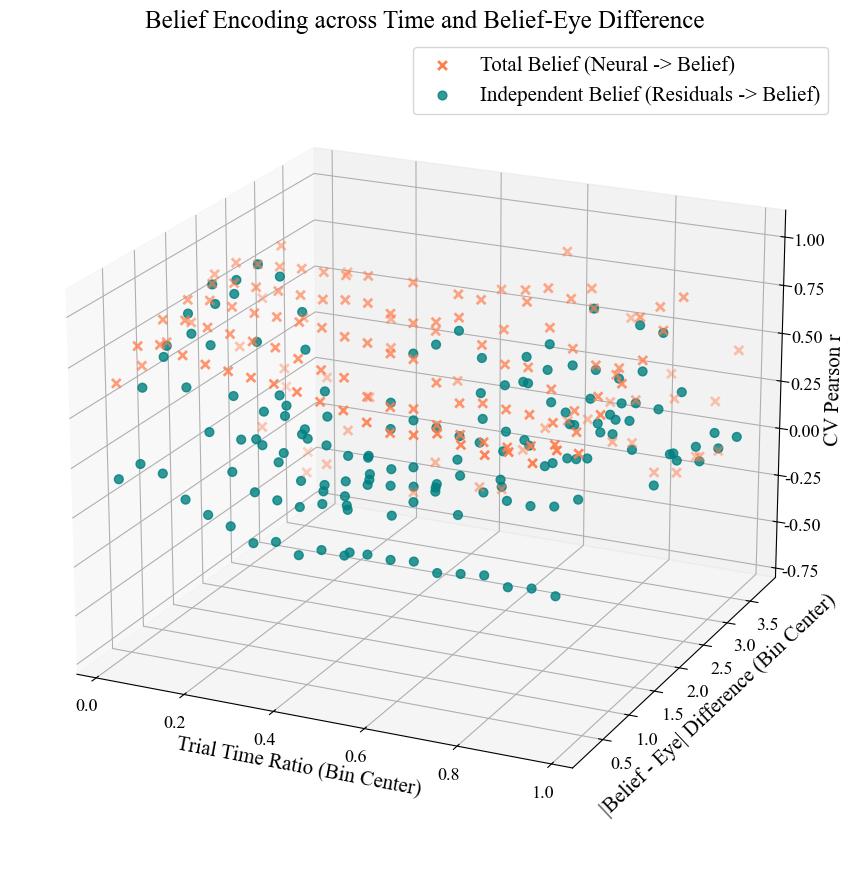


3D Binned Analysis Complete.


In [95]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Import 3D plotting tool
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing
# import matplotlib.colors as colors # Not needed for scatter

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC', 'belief', 'eye', and 'timeratio'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     # Try to load placeholder if actual data not found
     print("Warning: DataFrame 'timedf' not found. Using placeholder data.")
     # --- Placeholder Data (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
     rng = np.random.default_rng(42)
     n_samples_orig = 100000 # Need more samples for 2D binning
     n_features = 50      # Number of channels/neurons
     sampling_rate = 166 # Hz

     samples_per_trial = 100
     n_trials = n_samples_orig // samples_per_trial
     n_samples_orig = n_trials * samples_per_trial
     timeratio_signal = np.tile(np.linspace(0, 1, samples_per_trial, endpoint=False), n_trials)

     belief_signal_true = normalize_z(rng.random(n_samples_orig) * 10)
     eye_signal_true = normalize_z(rng.random(n_samples_orig) * 5)
     # Make correlation vary with time ratio (stronger in middle)
     correlation_factor = 0.3 + 0.4 * np.sin(timeratio_signal * np.pi)
     belief_signal_correlated = normalize_z( (1-correlation_factor) * belief_signal_true + correlation_factor * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     eye_signal_correlated = normalize_z( correlation_factor * belief_signal_true + (1-correlation_factor) * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))

     voltage_noise = rng.normal(0, 1.0, (n_samples_orig, n_features))
     belief_mod = belief_signal_correlated[:, np.newaxis] * 0.1
     eye_mod = eye_signal_correlated[:, np.newaxis] * 0.3
     neural_data_raw_voltage_sim = voltage_noise + belief_mod + eye_mod

     timedf = pd.DataFrame({
         'PPC': list(neural_data_raw_voltage_sim),
         'belief': belief_signal_correlated,
         'eye': eye_signal_correlated,
         'timeratio': timeratio_signal
     })
     # --- End Placeholder Data ---
else:
    print("Using provided 'timedf' DataFrame.")


# --- Parameters ---
sampling_rate = 166 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers
gaussian_sigma_samples = 5 # Std deviation of Gaussian kernel in SAMPLES
n_time_bins = 20 # Number of bins for timeratio
n_diff_bins = 10 # Number of bins for belief-eye difference
diff_cutoff = 4.0 # Maximum absolute difference to include before binning
min_samples_per_bin = 50 # Minimum samples required in a 2D bin for analysis

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
try:
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy())
    belief_data_present_raw = timedf['belief'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    timeratio_raw = timedf['timeratio'].to_numpy() # Extract timeratio
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, Belief={belief_data_present_raw.shape}, Eye={eye_data_present_raw.shape}, TimeRatio={timeratio_raw.shape}")

    if not (neural_data_raw_voltage.shape[0] == belief_data_present_raw.shape[0] == eye_data_present_raw.shape[0] == timeratio_raw.shape[0]):
        raise ValueError("Mismatch in number of samples between neural ('PPC'), belief, eye, or timeratio data.")

except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'belief', 'eye', and 'timeratio' exist.")
except Exception as e:
    raise TypeError(f"Error processing data columns. Ensure they contain stackable numerical data. Error: {e}")


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0) # Replace NaN/Inf with 0 before scaling
    scaler = StandardScaler()
    if np.std(data) < 1e-9:
        print("Warning: Standard deviation is zero during normalization. Returning zeros.")
        return np.zeros_like(data)
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

# --- Normalize Behavioral Data Globally ---
print("\n--- Normalizing Behavioral Data (Globally) ---")
belief_data_normalized = normalize_z(belief_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)

# --- Outlier Removal (Based on Normalized Belief & Eye) ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev for Belief & Eye) ---")
task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized]).T
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

# Apply mask to all data types that need to stay aligned
neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
belief_data_present = belief_data_normalized[mask_outliers]
eye_data_present = eye_data_normalized[mask_outliers]
timeratio_present = timeratio_raw[mask_outliers] # Keep timeratio aligned

n_removed = len(belief_data_present_raw) - len(belief_data_present)
print(f"Removed {n_removed} outlier trials/samples ({n_removed / len(belief_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, Belief={belief_data_present.shape}, Eye={eye_data_present.shape}, TimeRatio={timeratio_present.shape}")

if len(belief_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")

# =============================================================================
# Calculate Belief-Eye Difference & Apply Cutoff
# =============================================================================
print("\n--- Calculating Absolute Belief-Eye Difference & Applying Cutoff ---")
belief_eye_diff_all = np.abs(belief_data_present - eye_data_present)
# Create mask for difference cutoff
diff_mask_cutoff = belief_eye_diff_all <= diff_cutoff
print(f"  Applying cutoff: Keeping differences <= {diff_cutoff:.2f}")

# Apply cutoff mask to all data
neural_data_raw_voltage_cutoff = neural_data_raw_voltage_cleaned[diff_mask_cutoff, :]
belief_data_cutoff = belief_data_present[diff_mask_cutoff]
eye_data_cutoff = eye_data_present[diff_mask_cutoff]
timeratio_cutoff = timeratio_present[diff_mask_cutoff]
belief_eye_diff_cutoff = belief_eye_diff_all[diff_mask_cutoff]

n_diff_removed = len(belief_data_present) - len(belief_data_cutoff)
print(f"  Removed {n_diff_removed} samples due to difference cutoff ({n_diff_removed / len(belief_data_present) * 100:.2f}% of cleaned data).")
print(f"Data shape after difference cutoff: Neural={neural_data_raw_voltage_cutoff.shape}, Belief={belief_data_cutoff.shape}, Eye={eye_data_cutoff.shape}, TimeRatio={timeratio_cutoff.shape}")

if len(belief_data_cutoff) == 0:
    raise ValueError("All data removed after difference cutoff. Check cutoff value.")


# =============================================================================
# Gaussian Smoothing of Cutoff Raw Voltage Data
# =============================================================================
print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---")
neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_cutoff,
                                         sigma=gaussian_sigma_samples,
                                         axis=0,
                                         mode='reflect')
print("Gaussian smoothing complete.")

# =============================================================================
# Z-score Smoothed Data Per Channel Globally
# =============================================================================
print("Z-scoring smoothed data per channel (Globally)...")
scaler_smooth = StandardScaler()
neural_data_processed = np.zeros_like(neural_data_smoothed)
for i in range(neural_data_smoothed.shape[1]):
    channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9:
        neural_data_processed[:, i] = scaler_smooth.fit_transform(channel_data).flatten()
    else:
        print(f"Warning: Channel {i} has zero standard deviation after smoothing. Outputting zeros.")
print("Z-scoring complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")


# =============================================================================
# 2D Binned Analysis (Time x Difference) - Storing results for 3D plot
# =============================================================================
print(f"\n--- 2D Binned Analysis for 3D Plot (Time: {n_time_bins} bins, Difference: {n_diff_bins} bins) ---")

# Define bins based on data *after* cutoff
time_bin_edges = np.linspace(0, 1, n_time_bins + 1)
time_bin_centers = (time_bin_edges[:-1] + time_bin_edges[1:]) / 2

# Use 0 to diff_cutoff for difference bins
diff_bin_edges = np.linspace(0, diff_cutoff, n_diff_bins + 1)
diff_bin_centers = (diff_bin_edges[:-1] + diff_bin_edges[1:]) / 2

# Lists to store valid results for plotting
plot_data_total = [] # Stores (time_center, diff_center, r_total)
plot_data_independent = [] # Stores (time_center, diff_center, r_independent)

# Initialize the base model and CV strategy
lr_model = LinearRegression()
n_splits = 5 # CV folds within each bin

# Loop through time bins
for i in range(n_time_bins):
    time_bin_start = time_bin_edges[i]
    time_bin_end = time_bin_edges[i+1]
    is_last_time_bin = (i == n_time_bins - 1)
    if is_last_time_bin:
        time_mask = (timeratio_cutoff >= time_bin_start) & (timeratio_cutoff <= time_bin_end)
    else:
        time_mask = (timeratio_cutoff >= time_bin_start) & (timeratio_cutoff < time_bin_end)

    # Loop through difference bins
    for j in range(n_diff_bins):
        diff_bin_start = diff_bin_edges[j]
        diff_bin_end = diff_bin_edges[j+1]
        # Use the pre-calculated difference array after cutoff
        diff_mask = (belief_eye_diff_cutoff >= diff_bin_start) & (belief_eye_diff_cutoff < diff_bin_end)

        # Combine masks
        bin_mask = time_mask & diff_mask

        # Select data for the current 2D bin
        neural_bin = neural_data_processed[bin_mask]
        belief_bin = belief_data_cutoff[bin_mask]
        eye_bin = eye_data_cutoff[bin_mask]
        n_samples_in_bin = len(belief_bin)

        # Check if enough samples for analysis and CV
        if n_samples_in_bin < max(min_samples_per_bin, n_splits):
            continue # Skip to next bin

        print(f"Processing Bin (T={i+1},D={j+1})... N={n_samples_in_bin}")

        # --- Perform CV analyses within the bin ---
        eye_bin_2d = eye_bin.reshape(-1, 1)
        current_n_splits = n_splits
        if n_samples_in_bin < current_n_splits: current_n_splits = max(2, n_samples_in_bin)
        cv_bin = KFold(n_splits=current_n_splits, shuffle=True, random_state=42)

        # --- 1. Total Belief Encoding (Neural -> Belief) ---
        r_total_bin = np.nan # Default to NaN
        try:
            predicted_belief_total_cv_bin = cross_val_predict(lr_model, neural_bin, belief_bin, cv=cv_bin)
            valid_indices_total = np.isfinite(belief_bin) & np.isfinite(predicted_belief_total_cv_bin)
            if np.sum(valid_indices_total) >= 2:
                r_total_bin, _ = pearsonr(belief_bin[valid_indices_total], predicted_belief_total_cv_bin[valid_indices_total])
        except ValueError: pass # Keep NaN if error

        # --- 2. Independent Belief Encoding (Residuals -> Belief) ---
        r_independent_bin = np.nan # Default to NaN
        try:
            predicted_neural_from_eye_cv_bin = cross_val_predict(lr_model, eye_bin_2d, neural_bin, cv=cv_bin)
            residuals_bin = neural_bin - predicted_neural_from_eye_cv_bin
            predicted_belief_independent_cv_bin = cross_val_predict(lr_model, residuals_bin, belief_bin, cv=cv_bin)
            valid_indices_independent = np.isfinite(belief_bin) & np.isfinite(predicted_belief_independent_cv_bin)
            if np.sum(valid_indices_independent) >= 2:
                r_independent_bin, _ = pearsonr(belief_bin[valid_indices_independent], predicted_belief_independent_cv_bin[valid_indices_independent])
        except ValueError: pass # Keep NaN if error

        # Store results if they are valid numbers
        if not np.isnan(r_total_bin):
            plot_data_total.append((time_bin_centers[i], diff_bin_centers[j], r_total_bin))
        if not np.isnan(r_independent_bin):
            plot_data_independent.append((time_bin_centers[i], diff_bin_centers[j], r_independent_bin))


# =============================================================================
# Plotting the 3D Scatter Plot
# =============================================================================
print("\n--- Plotting 3D Scatter Plot ---")

fig_3d = plt.figure(figsize=(12, 9))
ax_3d = fig_3d.add_subplot(111, projection='3d')

# Unpack data for plotting
if plot_data_total:
    time_total, diff_total, r_total = zip(*plot_data_total)
    ax_3d.scatter(time_total, diff_total, r_total, c='coral', marker='x', s=40, label='Total Belief (Neural -> Belief)')

if plot_data_independent:
    time_indep, diff_indep, r_indep = zip(*plot_data_independent)
    ax_3d.scatter(time_indep, diff_indep, r_indep, c='teal', marker='o', s=40, alpha=0.8, label='Independent Belief (Residuals -> Belief)')

# Setting labels and title
ax_3d.set_xlabel('Trial Time Ratio (Bin Center)')
ax_3d.set_ylabel('|Belief - Eye| Difference (Bin Center)')
ax_3d.set_zlabel('CV Pearson r')
ax_3d.set_title('Belief Encoding across Time and Belief-Eye Difference')

# Adjust Z limit if needed
if plot_data_total or plot_data_independent:
    all_r = np.concatenate(([r for _,_,r in plot_data_total], [r for _,_,r in plot_data_independent]))
    min_z = min(0, np.min(all_r) - 0.1)
    max_z = max(0.1, np.max(all_r) + 0.1)
    ax_3d.set_zlim(min_z, max_z)

ax_3d.legend()
ax_3d.view_init(elev=20., azim=-65) # Adjust viewing angle (elevation, azimuth)
plt.tight_layout()
plt.show()

print("\n3D Binned Analysis Complete.")


Using provided 'timedf' DataFrame.
--- Extracting Raw Data from DataFrame ---
Initial shapes: Neural=(400117, 112), Belief=(400117,), Eye=(400117,), TimeRatio=(400117,)

--- Normalizing Behavioral Data (Globally) ---

--- Removing Outliers (Threshold: +/- 4 std dev for Belief & Eye) ---
Removed 607 outlier trials/samples (0.15%).
Data shape after cleaning: Neural=(399510, 112), Belief=(399510,), Eye=(399510,), TimeRatio=(399510,)

--- Calculating Absolute Belief-Eye Difference & Applying Cutoff ---
  Applying cutoff: Keeping differences <= 4.00
  Removed 329 samples due to difference cutoff (0.08% of cleaned data).
Data shape after difference cutoff: Neural=(399181, 112), Belief=(399181,), Eye=(399181,), TimeRatio=(399181,)

--- Applying Gaussian Smoothing (sigma = 10 samples) ---
Gaussian smoothing complete.
Z-scoring smoothed data per channel (Globally)...
Z-scoring complete.
Processed neural data shape: (399181, 112)

--- 2D Binned Analysis for 3D Plot (Time: 20 bins, Difference: 10

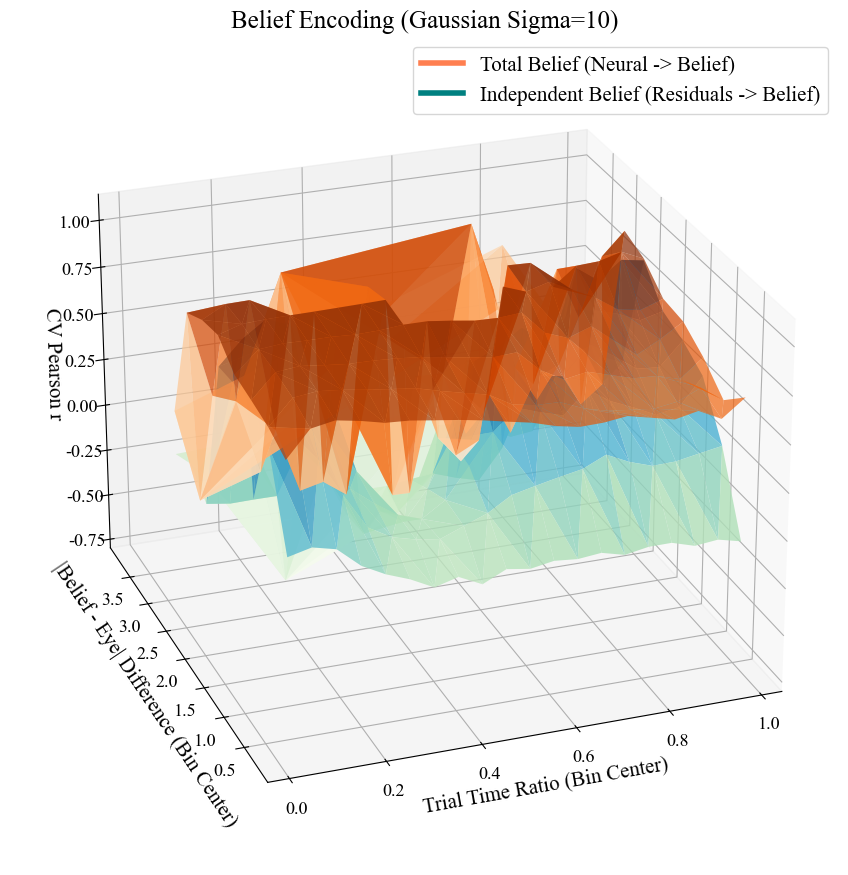


3D Surface Plot Analysis (Sigma=10) Complete.


In [97]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Import 3D plotting tool
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing
from matplotlib.lines import Line2D # For custom legend

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC', 'belief', 'eye', and 'timeratio'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     # Try to load placeholder if actual data not found
     print("Warning: DataFrame 'timedf' not found. Using placeholder data.")
     # --- Placeholder Data (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
     rng = np.random.default_rng(42)
     n_samples_orig = 100000 # Need more samples for 2D binning
     n_features = 50      # Number of channels/neurons
     sampling_rate = 166 # Hz

     samples_per_trial = 100
     n_trials = n_samples_orig // samples_per_trial
     n_samples_orig = n_trials * samples_per_trial
     timeratio_signal = np.tile(np.linspace(0, 1, samples_per_trial, endpoint=False), n_trials)

     belief_signal_true = normalize_z(rng.random(n_samples_orig) * 10)
     eye_signal_true = normalize_z(rng.random(n_samples_orig) * 5)
     # Make correlation vary with time ratio (stronger in middle)
     correlation_factor = 0.3 + 0.4 * np.sin(timeratio_signal * np.pi)
     belief_signal_correlated = normalize_z( (1-correlation_factor) * belief_signal_true + correlation_factor * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     eye_signal_correlated = normalize_z( correlation_factor * belief_signal_true + (1-correlation_factor) * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))

     voltage_noise = rng.normal(0, 1.0, (n_samples_orig, n_features))
     belief_mod = belief_signal_correlated[:, np.newaxis] * 0.1
     eye_mod = eye_signal_correlated[:, np.newaxis] * 0.3
     neural_data_raw_voltage_sim = voltage_noise + belief_mod + eye_mod

     timedf = pd.DataFrame({
         'PPC': list(neural_data_raw_voltage_sim),
         'belief': belief_signal_correlated,
         'eye': eye_signal_correlated,
         'timeratio': timeratio_signal
     })
     # --- End Placeholder Data ---
else:
    print("Using provided 'timedf' DataFrame.")


# --- Parameters ---
sampling_rate = 166 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers
gaussian_sigma_samples = 10 # <<< INCREASED SMOOTHING >>> Std deviation of Gaussian kernel in SAMPLES
n_time_bins = 20 # Number of bins for timeratio
n_diff_bins = 10 # Number of bins for belief-eye difference
diff_cutoff = 4.0 # Maximum absolute difference to include before binning
min_samples_per_bin = 50 # Minimum samples required in a 2D bin for analysis

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
try:
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy())
    belief_data_present_raw = timedf['belief'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    timeratio_raw = timedf['timeratio'].to_numpy() # Extract timeratio
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, Belief={belief_data_present_raw.shape}, Eye={eye_data_present_raw.shape}, TimeRatio={timeratio_raw.shape}")

    if not (neural_data_raw_voltage.shape[0] == belief_data_present_raw.shape[0] == eye_data_present_raw.shape[0] == timeratio_raw.shape[0]):
        raise ValueError("Mismatch in number of samples between neural ('PPC'), belief, eye, or timeratio data.")

except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'belief', 'eye', and 'timeratio' exist.")
except Exception as e:
    raise TypeError(f"Error processing data columns. Ensure they contain stackable numerical data. Error: {e}")


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0) # Replace NaN/Inf with 0 before scaling
    scaler = StandardScaler()
    if np.std(data) < 1e-9:
        print("Warning: Standard deviation is zero during normalization. Returning zeros.")
        return np.zeros_like(data)
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

# --- Normalize Behavioral Data Globally ---
print("\n--- Normalizing Behavioral Data (Globally) ---")
belief_data_normalized = normalize_z(belief_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)

# --- Outlier Removal (Based on Normalized Belief & Eye) ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev for Belief & Eye) ---")
task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized]).T
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

# Apply mask to all data types that need to stay aligned
neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
belief_data_present = belief_data_normalized[mask_outliers]
eye_data_present = eye_data_normalized[mask_outliers]
timeratio_present = timeratio_raw[mask_outliers] # Keep timeratio aligned

n_removed = len(belief_data_present_raw) - len(belief_data_present)
print(f"Removed {n_removed} outlier trials/samples ({n_removed / len(belief_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, Belief={belief_data_present.shape}, Eye={eye_data_present.shape}, TimeRatio={timeratio_present.shape}")

if len(belief_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")

# =============================================================================
# Calculate Belief-Eye Difference & Apply Cutoff
# =============================================================================
print("\n--- Calculating Absolute Belief-Eye Difference & Applying Cutoff ---")
belief_eye_diff_all = np.abs(belief_data_present - eye_data_present)
# Create mask for difference cutoff
diff_mask_cutoff = belief_eye_diff_all <= diff_cutoff
print(f"  Applying cutoff: Keeping differences <= {diff_cutoff:.2f}")

# Apply cutoff mask to all data
neural_data_raw_voltage_cutoff = neural_data_raw_voltage_cleaned[diff_mask_cutoff, :]
belief_data_cutoff = belief_data_present[diff_mask_cutoff]
eye_data_cutoff = eye_data_present[diff_mask_cutoff]
timeratio_cutoff = timeratio_present[diff_mask_cutoff]
belief_eye_diff_cutoff = belief_eye_diff_all[diff_mask_cutoff]

n_diff_removed = len(belief_data_present) - len(belief_data_cutoff)
print(f"  Removed {n_diff_removed} samples due to difference cutoff ({n_diff_removed / len(belief_data_present) * 100:.2f}% of cleaned data).")
print(f"Data shape after difference cutoff: Neural={neural_data_raw_voltage_cutoff.shape}, Belief={belief_data_cutoff.shape}, Eye={eye_data_cutoff.shape}, TimeRatio={timeratio_cutoff.shape}")

if len(belief_data_cutoff) == 0:
    raise ValueError("All data removed after difference cutoff. Check cutoff value.")


# =============================================================================
# Gaussian Smoothing of Cutoff Raw Voltage Data
# =============================================================================
print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---") # Sigma is now 10
neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_cutoff,
                                         sigma=gaussian_sigma_samples,
                                         axis=0,
                                         mode='reflect')
print("Gaussian smoothing complete.")

# =============================================================================
# Z-score Smoothed Data Per Channel Globally
# =============================================================================
print("Z-scoring smoothed data per channel (Globally)...")
scaler_smooth = StandardScaler()
neural_data_processed = np.zeros_like(neural_data_smoothed)
for i in range(neural_data_smoothed.shape[1]):
    channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9:
        neural_data_processed[:, i] = scaler_smooth.fit_transform(channel_data).flatten()
    else:
        print(f"Warning: Channel {i} has zero standard deviation after smoothing. Outputting zeros.")
print("Z-scoring complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")


# =============================================================================
# 2D Binned Analysis (Time x Difference) - Storing results for 3D plot
# =============================================================================
print(f"\n--- 2D Binned Analysis for 3D Plot (Time: {n_time_bins} bins, Difference: {n_diff_bins} bins) ---")

# Define bins based on data *after* cutoff
time_bin_edges = np.linspace(0, 1, n_time_bins + 1)
time_bin_centers = (time_bin_edges[:-1] + time_bin_edges[1:]) / 2

# Use 0 to diff_cutoff for difference bins
diff_bin_edges = np.linspace(0, diff_cutoff, n_diff_bins + 1)
diff_bin_centers = (diff_bin_edges[:-1] + diff_bin_edges[1:]) / 2

# Lists to store valid results for plotting
plot_data_total = [] # Stores (time_center, diff_center, r_total)
plot_data_independent = [] # Stores (time_center, diff_center, r_independent)

# Initialize the base model and CV strategy
lr_model = LinearRegression()
n_splits = 5 # CV folds within each bin

# Loop through time bins
for i in range(n_time_bins):
    time_bin_start = time_bin_edges[i]
    time_bin_end = time_bin_edges[i+1]
    is_last_time_bin = (i == n_time_bins - 1)
    if is_last_time_bin:
        time_mask = (timeratio_cutoff >= time_bin_start) & (timeratio_cutoff <= time_bin_end)
    else:
        time_mask = (timeratio_cutoff >= time_bin_start) & (timeratio_cutoff < time_bin_end)

    # Loop through difference bins
    for j in range(n_diff_bins):
        diff_bin_start = diff_bin_edges[j]
        diff_bin_end = diff_bin_edges[j+1]
        # Use the pre-calculated difference array after cutoff
        diff_mask = (belief_eye_diff_cutoff >= diff_bin_start) & (belief_eye_diff_cutoff < diff_bin_end)

        # Combine masks
        bin_mask = time_mask & diff_mask

        # Select data for the current 2D bin
        neural_bin = neural_data_processed[bin_mask]
        belief_bin = belief_data_cutoff[bin_mask]
        eye_bin = eye_data_cutoff[bin_mask]
        n_samples_in_bin = len(belief_bin)

        # Check if enough samples for analysis and CV
        if n_samples_in_bin < max(min_samples_per_bin, n_splits):
            continue # Skip to next bin

        print(f"Processing Bin (T={i+1},D={j+1})... N={n_samples_in_bin}")

        # --- Perform CV analyses within the bin ---
        eye_bin_2d = eye_bin.reshape(-1, 1)
        current_n_splits = n_splits
        if n_samples_in_bin < current_n_splits: current_n_splits = max(2, n_samples_in_bin)
        cv_bin = KFold(n_splits=current_n_splits, shuffle=True, random_state=42)

        # --- 1. Total Belief Encoding (Neural -> Belief) ---
        r_total_bin = np.nan # Default to NaN
        try:
            predicted_belief_total_cv_bin = cross_val_predict(lr_model, neural_bin, belief_bin, cv=cv_bin)
            valid_indices_total = np.isfinite(belief_bin) & np.isfinite(predicted_belief_total_cv_bin)
            if np.sum(valid_indices_total) >= 2:
                r_total_bin, _ = pearsonr(belief_bin[valid_indices_total], predicted_belief_total_cv_bin[valid_indices_total])
        except ValueError: pass # Keep NaN if error

        # --- 2. Independent Belief Encoding (Residuals -> Belief) ---
        r_independent_bin = np.nan # Default to NaN
        try:
            predicted_neural_from_eye_cv_bin = cross_val_predict(lr_model, eye_bin_2d, neural_bin, cv=cv_bin)
            residuals_bin = neural_bin - predicted_neural_from_eye_cv_bin
            predicted_belief_independent_cv_bin = cross_val_predict(lr_model, residuals_bin, belief_bin, cv=cv_bin)
            valid_indices_independent = np.isfinite(belief_bin) & np.isfinite(predicted_belief_independent_cv_bin)
            if np.sum(valid_indices_independent) >= 2:
                r_independent_bin, _ = pearsonr(belief_bin[valid_indices_independent], predicted_belief_independent_cv_bin[valid_indices_independent])
        except ValueError: pass # Keep NaN if error

        # Store results if they are valid numbers
        if not np.isnan(r_total_bin):
            plot_data_total.append((time_bin_centers[i], diff_bin_centers[j], r_total_bin))
        if not np.isnan(r_independent_bin):
            plot_data_independent.append((time_bin_centers[i], diff_bin_centers[j], r_independent_bin))


# =============================================================================
# Plotting the 3D Surface Plot using plot_trisurf
# =============================================================================
print("\n--- Plotting 3D Surface Plot ---")

fig_3d_surf = plt.figure(figsize=(12, 9))
ax_3d_surf = fig_3d_surf.add_subplot(111, projection='3d')

# Plot surface for Total Belief Encoding
if plot_data_total:
    try:
        time_total, diff_total, r_total = zip(*plot_data_total)
        if len(time_total) >= 3: # Need at least 3 points for triangulation
            surf_total = ax_3d_surf.plot_trisurf(time_total, diff_total, r_total, cmap='Oranges', alpha=0.7,
                                                 linewidth=0.1, antialiased=True)
            print(f"Plotting Total Belief surface with {len(time_total)} points.")
        else:
            print("Not enough valid data points (>=3) to plot Total Belief surface.")
    except Exception as e:
        print(f"Error plotting Total Belief surface: {e}")
else:
    print("No valid data points computed for 'Total Belief'.")


# Plot surface for Independent Belief Encoding
if plot_data_independent:
    try:
        time_indep, diff_indep, r_indep = zip(*plot_data_independent)
        if len(time_indep) >= 3: # Need at least 3 points for triangulation
            surf_indep = ax_3d_surf.plot_trisurf(time_indep, diff_indep, r_indep, cmap='GnBu', alpha=0.8,
                                                 linewidth=0.1, antialiased=True)
            print(f"Plotting Independent Belief surface with {len(time_indep)} points.")
        else:
            print("Not enough valid data points (>=3) to plot Independent Belief surface.")
    except Exception as e:
        print(f"Error plotting Independent Belief surface: {e}")
else:
    print("No valid data points computed for 'Independent Belief'.")


# Setting labels and title
ax_3d_surf.set_xlabel('Trial Time Ratio (Bin Center)')
ax_3d_surf.set_ylabel('|Belief - Eye| Difference (Bin Center)')
ax_3d_surf.set_zlabel('CV Pearson r')
ax_3d_surf.set_title(f'Belief Encoding (Gaussian Sigma={gaussian_sigma_samples})')

# Adjust Z limit if needed
all_r_values = []
if 'plot_data_total' in locals() and plot_data_total: all_r_values.extend([r for _,_,r in plot_data_total])
if 'plot_data_independent' in locals() and plot_data_independent: all_r_values.extend([r for _,_,r in plot_data_independent])

if all_r_values:
    all_r = np.array(all_r_values)
    min_z = min(0, np.nanmin(all_r) - 0.1) if not np.all(np.isnan(all_r)) else 0
    max_z = max(0.1, np.nanmax(all_r) + 0.1) if not np.all(np.isnan(all_r)) else 0.1
    ax_3d_surf.set_zlim(min_z, max_z)
else:
     ax_3d_surf.set_zlim(0, 0.1) # Default limits if no data


# Create proxy artists for legend
legend_elements = [Line2D([0], [0], color='coral', lw=4, label='Total Belief (Neural -> Belief)'),
                   Line2D([0], [0], color='teal', lw=4, label='Independent Belief (Residuals -> Belief)')]
ax_3d_surf.legend(handles=legend_elements)


ax_3d_surf.view_init(elev=25., azim=-110) # Adjust viewing angle
plt.tight_layout()
plt.show()

print(f"\n3D Surface Plot Analysis (Sigma={gaussian_sigma_samples}) Complete.")


Using provided 'timedf' DataFrame.
--- Extracting Raw Data from DataFrame ---
Initial shapes: Neural=(400117, 112), Belief=(400117,), Eye=(400117,)

--- Normalizing Behavioral Data (Globally) ---

--- Removing Outliers (Threshold: +/- 4 std dev for Belief & Eye) ---
Removed 607 outlier trials/samples (0.15%).
Data shape after cleaning: Neural=(399510, 112), Belief=(399510,), Eye=(399510,)

--- Calculating Derivatives and Absolute Difference ---
  Range of derivative difference: 0.000 to 3.307

--- Applying Gaussian Smoothing (sigma = 10 samples) ---
Gaussian smoothing complete.
Z-scoring smoothed data per channel (Globally)...
Z-scoring complete.
Processed neural data shape: (399510, 112)

--- Derivative Difference Binned Analysis Comparison (25 bins using Log Spacing) ---
Using 25 bins (including near-zero bin).

Processing Bin 1/25 (Deriv Diff: 0.000E+00 to 3.119E-08)...
  Samples in bin: 0
  Skipping bin 1 due to insufficient samples (required: 50).

Processing Bin 2/25 (Deriv Diff:

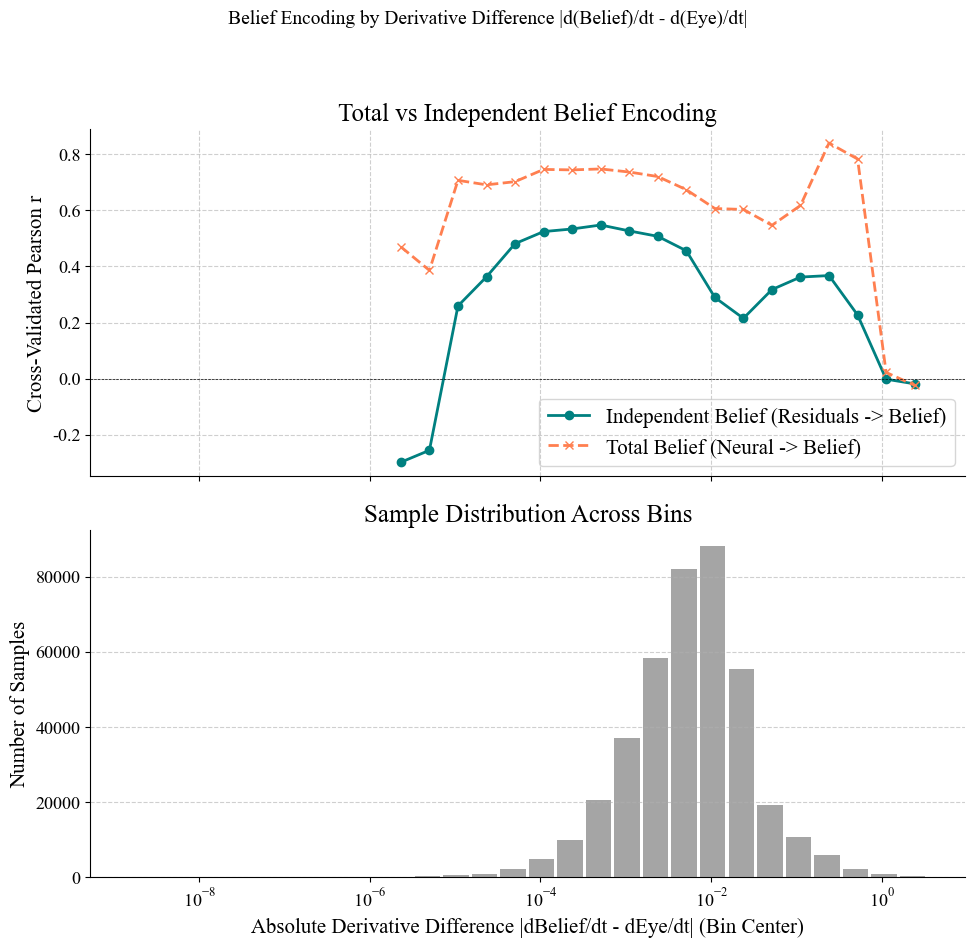


Derivative Difference Binned Analysis (Log Bins) Complete.


In [101]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC', 'belief', and 'eye'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     # Try to load placeholder if actual data not found
     print("Warning: DataFrame 'timedf' not found. Using placeholder data.")
     # --- Placeholder Data (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
     rng = np.random.default_rng(42)
     n_samples_orig = 100000 # Use a decent number of samples
     n_features = 50      # Number of channels/neurons
     sampling_rate = 166 # Hz

     belief_signal_true = normalize_z(rng.random(n_samples_orig) * 10)
     eye_signal_true = normalize_z(rng.random(n_samples_orig) * 5)
     # Simulate varying correlation - let's make it random per sample for simplicity here
     correlation_factor = rng.uniform(0.1, 0.8, n_samples_orig)
     belief_signal_correlated = normalize_z( (1-correlation_factor) * belief_signal_true + correlation_factor * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     eye_signal_correlated = normalize_z( correlation_factor * belief_signal_true + (1-correlation_factor) * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))

     voltage_noise = rng.normal(0, 1.0, (n_samples_orig, n_features))
     belief_mod = belief_signal_correlated[:, np.newaxis] * 0.1
     eye_mod = eye_signal_correlated[:, np.newaxis] * 0.3
     neural_data_raw_voltage_sim = voltage_noise + belief_mod + eye_mod

     timedf = pd.DataFrame({
         'PPC': list(neural_data_raw_voltage_sim),
         'belief': belief_signal_correlated,
         'eye': eye_signal_correlated
         # No timeratio needed for this version
     })
     # --- End Placeholder Data ---
else:
    print("Using provided 'timedf' DataFrame.")


# --- Parameters ---
sampling_rate = 166 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers
gaussian_sigma_samples = 10 # Std deviation of Gaussian kernel in SAMPLES (using the value from the last run)
n_deriv_diff_bins = 25 # Number of bins for derivative difference (Adjust as needed)
min_samples_per_bin = 50 # Minimum samples required in a bin for analysis
log_bin_start_offset = 1e-4 # Small offset to avoid log(0) for geomspace start

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
try:
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy())
    belief_data_present_raw = timedf['belief'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, Belief={belief_data_present_raw.shape}, Eye={eye_data_present_raw.shape}")

    if not (neural_data_raw_voltage.shape[0] == belief_data_present_raw.shape[0] == eye_data_present_raw.shape[0]):
        raise ValueError("Mismatch in number of samples between neural ('PPC'), belief, or eye data.")

except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'belief', 'eye' exist.")
except Exception as e:
    raise TypeError(f"Error processing data columns. Ensure they contain stackable numerical data. Error: {e}")


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    data = np.asarray(data) # Ensure numpy array
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0) # Replace NaN/Inf with 0 before scaling
    scaler = StandardScaler()
    if data.ndim == 1:
        if np.std(data) < 1e-9:
            # print("Warning: Standard deviation is zero during normalization. Returning zeros.") # Reduce verbosity
            return np.zeros_like(data)
        return scaler.fit_transform(data.reshape(-1, 1)).flatten()
    elif data.ndim == 0:
         return np.array([0.0])
    else:
        print(f"Warning: normalize_z received data with unexpected shape {data.shape}. Returning original data.")
        return data


# --- Normalize Behavioral Data Globally ---
print("\n--- Normalizing Behavioral Data (Globally) ---")
belief_data_normalized = normalize_z(belief_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)

# --- Outlier Removal (Based on Normalized Belief & Eye) ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev for Belief & Eye) ---")
task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized]).T
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

# Apply mask to all data types that need to stay aligned
neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
belief_data_present = belief_data_normalized[mask_outliers]
eye_data_present = eye_data_normalized[mask_outliers]

n_removed = len(belief_data_present_raw) - len(belief_data_present)
print(f"Removed {n_removed} outlier trials/samples ({n_removed / len(belief_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, Belief={belief_data_present.shape}, Eye={eye_data_present.shape}")

if len(belief_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")

# =============================================================================
# Calculate Derivatives and their Absolute Difference
# =============================================================================
print("\n--- Calculating Derivatives and Absolute Difference ---")
# Use np.gradient which handles boundaries and maintains array size
belief_deriv = np.gradient(belief_data_present)
eye_deriv = np.gradient(eye_data_present)
deriv_diff = np.abs(belief_deriv - eye_deriv)
print(f"  Range of derivative difference: {np.min(deriv_diff):.3f} to {np.max(deriv_diff):.3f}")

# =============================================================================
# Gaussian Smoothing of Cleaned Raw Voltage Data
# =============================================================================
print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---")
neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_cleaned,
                                         sigma=gaussian_sigma_samples,
                                         axis=0,
                                         mode='reflect')
print("Gaussian smoothing complete.")

# =============================================================================
# Z-score Smoothed Data Per Channel Globally
# =============================================================================
print("Z-scoring smoothed data per channel (Globally)...")
scaler_smooth = StandardScaler()
neural_data_processed = np.zeros_like(neural_data_smoothed)
for i in range(neural_data_smoothed.shape[1]):
    channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9:
        neural_data_processed[:, i] = scaler_smooth.fit_transform(channel_data).flatten()
    else:
        # print(f"Warning: Channel {i} has zero standard deviation after smoothing. Outputting zeros.") # Reduce verbosity
        pass
print("Z-scoring complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")


# =============================================================================
# Derivative Difference Binned Analysis Comparison
# =============================================================================
print(f"\n--- Derivative Difference Binned Analysis Comparison ({n_deriv_diff_bins} bins using Log Spacing) ---")

# *** MODIFIED: Define difference bins using LOGARITHMIC spacing ***
min_diff_val = np.min(deriv_diff[deriv_diff > 0]) # Find smallest non-zero difference
if min_diff_val < log_bin_start_offset:
    log_bin_start_offset = min_diff_val * 0.9 # Adjust offset if needed
max_diff_val = np.max(deriv_diff)

if max_diff_val <= log_bin_start_offset:
     raise ValueError(f"Maximum derivative difference ({max_diff_val:.3E}) is too small for log binning with offset {log_bin_start_offset:.3E}.")

# Create log-spaced bins from offset up to max value
log_bin_edges = np.geomspace(log_bin_start_offset, max_diff_val + 1e-9, n_deriv_diff_bins)
# Add a bin for the near-zero values (0 to offset)
bin_edges = np.concatenate(([0.0], log_bin_edges))
# *** END MODIFIED SECTION ***

# Recalculate number of bins (now n_deriv_diff_bins + 1 potentially)
n_deriv_diff_bins_actual = len(bin_edges) - 1
print(f"Using {n_deriv_diff_bins_actual} bins (including near-zero bin).")


bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# For the first bin (0 to offset), the linear center might not be representative
# Optionally, use a different representation like the median value within the bin later
first_bin_center_approx = log_bin_start_offset / 2
bin_centers[0] = first_bin_center_approx # Adjust first bin center representation


results_r_independent = [] # Pearson r for Residuals -> Belief
results_r_total = []       # Pearson r for Neural -> Belief
actual_bin_centers = []    # Store centers only for bins with enough data
samples_in_bins = []       # Store sample count per bin

# Initialize the base model and CV strategy
lr_model = LinearRegression()
n_splits = 5 # CV folds within each bin

for i in range(n_deriv_diff_bins_actual): # Use the actual number of bins
    bin_start = bin_edges[i]
    bin_end = bin_edges[i+1]
    # Mask based on derivative difference
    bin_mask = (deriv_diff >= bin_start) & (deriv_diff < bin_end)
    # Ensure the last bin includes the maximum value exactly
    if i == n_deriv_diff_bins_actual - 1:
         bin_mask = (deriv_diff >= bin_start) & (deriv_diff <= bin_end)


    print(f"\nProcessing Bin {i+1}/{n_deriv_diff_bins_actual} (Deriv Diff: {bin_start:.3E} to {bin_end:.3E})...") # Use scientific notation

    # Select data for the current bin
    neural_bin = neural_data_processed[bin_mask]
    belief_bin = belief_data_present[bin_mask]
    eye_bin = eye_data_present[bin_mask]
    n_samples_in_bin = len(belief_bin)
    samples_in_bins.append(n_samples_in_bin)
    print(f"  Samples in bin: {n_samples_in_bin}")

    # Check if enough samples for analysis and CV
    if n_samples_in_bin < max(min_samples_per_bin, n_splits):
        print(f"  Skipping bin {i+1} due to insufficient samples (required: {max(min_samples_per_bin, n_splits)}).")
        results_r_independent.append(np.nan)
        results_r_total.append(np.nan)
        continue # Skip to next bin

    # --- Perform CV analyses within the bin ---
    eye_bin_2d = eye_bin.reshape(-1, 1)

    # Adjust n_splits if samples < 5 but >= 2
    current_n_splits = n_splits
    if n_samples_in_bin < current_n_splits:
        current_n_splits = max(2, n_samples_in_bin)
        # print(f"  Adjusting CV folds to {current_n_splits} for this bin.") # Reduce verbosity
    cv_bin = KFold(n_splits=current_n_splits, shuffle=True, random_state=42)

    # --- 1. Total Belief Encoding (Neural -> Belief) ---
    # print("  Calculating Total Belief Encoding (Neural -> Belief)...") # Reduce verbosity
    r_total_bin = np.nan # Default to NaN
    try:
        predicted_belief_total_cv_bin = cross_val_predict(lr_model, neural_bin, belief_bin, cv=cv_bin)
        valid_indices_total = np.isfinite(belief_bin) & np.isfinite(predicted_belief_total_cv_bin)
        if np.sum(valid_indices_total) >= 2:
            r_total_bin, _ = pearsonr(belief_bin[valid_indices_total], predicted_belief_total_cv_bin[valid_indices_total])
    except ValueError: pass
    print(f"    CV Pearson r (Total): {r_total_bin:.4f}")
    results_r_total.append(r_total_bin)


    # --- 2. Independent Belief Encoding (Residuals -> Belief) ---
    # print("  Calculating Independent Belief Encoding (Residuals -> Belief)...") # Reduce verbosity
    r_independent_bin = np.nan # Default to NaN
    try:
        predicted_neural_from_eye_cv_bin = cross_val_predict(lr_model, eye_bin_2d, neural_bin, cv=cv_bin)
        residuals_bin = neural_bin - predicted_neural_from_eye_cv_bin
        predicted_belief_independent_cv_bin = cross_val_predict(lr_model, residuals_bin, belief_bin, cv=cv_bin)
        valid_indices_independent = np.isfinite(belief_bin) & np.isfinite(predicted_belief_independent_cv_bin)
        if np.sum(valid_indices_independent) >= 2:
            r_independent_bin, _ = pearsonr(belief_bin[valid_indices_independent], predicted_belief_independent_cv_bin[valid_indices_independent])
    except ValueError: pass
    print(f"    CV Pearson r (Independent): {r_independent_bin:.4f}")
    results_r_independent.append(r_independent_bin)

    # Store bin center only if both calculations were successful (not NaN)
    if not np.isnan(r_total_bin) and not np.isnan(r_independent_bin):
        actual_bin_centers.append(bin_centers[i])
    else:
        # Ensure consistency if one failed
        if np.isnan(r_total_bin) and not np.isnan(r_independent_bin): results_r_independent[-1] = np.nan
        if not np.isnan(r_total_bin) and np.isnan(r_independent_bin): results_r_total[-1] = np.nan


# =============================================================================
# Plotting the Derivative Difference Binned Comparison (Separate Plots)
# =============================================================================
print("\n--- Plotting Derivative Difference Binned Comparison (Separate Plots) ---")
# Create figure with 2 subplots, sharing the x-axis
fig_derivdiff_sep, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
fig_derivdiff_sep.suptitle('Belief Encoding by Derivative Difference |d(Belief)/dt - d(Eye)/dt|', fontsize=14)

# --- Plot 1: Correlation Curves ---
ax_corr = axes[0]

# Filter out NaN results from skipped or failed bins for plotting
plot_centers = np.array(actual_bin_centers)
# Filter results based on actual_bin_centers length, assuming NaNs were handled correctly when appending
plot_r_independent = np.array(results_r_independent)[~np.isnan(results_r_independent)]
plot_r_total = np.array(results_r_total)[~np.isnan(results_r_total)]

# Ensure lengths match after filtering potential NaNs from calculation errors
min_len = min(len(plot_centers), len(plot_r_independent), len(plot_r_total))
plot_centers = plot_centers[:min_len]
plot_r_independent = plot_r_independent[:min_len]
plot_r_total = plot_r_total[:min_len]


if len(plot_centers) > 0:
    # Plot Independent Belief Encoding (Residuals -> Belief)
    ax_corr.plot(plot_centers, plot_r_independent, marker='o', linestyle='-', color='teal', label='Independent Belief (Residuals -> Belief)')
    # Plot Total Belief Encoding (Neural -> Belief)
    ax_corr.plot(plot_centers, plot_r_total, marker='x', linestyle='--', color='coral', label='Total Belief (Neural -> Belief)')

    ax_corr.set_ylabel('Cross-Validated Pearson r')
    ax_corr.set_title('Total vs Independent Belief Encoding')
    # Adjust y-limits based on the range of both plots
    min_y = min(0, np.nanmin(plot_r_independent) - 0.05, np.nanmin(plot_r_total) - 0.05) if len(plot_r_independent)>0 and len(plot_r_total)>0 else 0
    max_y = max(0.1, np.nanmax(plot_r_independent) + 0.05, np.nanmax(plot_r_total) + 0.05) if len(plot_r_independent)>0 and len(plot_r_total)>0 else 0.1
    ax_corr.set_ylim(bottom=min_y, top=max_y)
    ax_corr.grid(True, linestyle='--', alpha=0.6)
    ax_corr.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax_corr.legend()
    # Set x-axis to log scale for better visualization of bins near zero
    ax_corr.set_xscale('log')


else:
    ax_corr.text(0.5, 0.5, 'No valid data bins found for plotting correlations.',
                    horizontalalignment='center', verticalalignment='center', transform=ax_corr.transAxes)
    ax_corr.set_ylabel('Cross-Validated Pearson r')
    ax_corr.set_title('Total vs Independent Belief Encoding')


# --- Plot 2: Sample Count Histogram ---
ax_hist = axes[1]

if len(samples_in_bins) > 0:
    # Use bin_edges for accurate bar placement with log bins
    bar_widths = bin_edges[1:] - bin_edges[:-1]
    # Plot bars on a log scale x-axis
    ax_hist.bar(bin_centers, samples_in_bins, width=bar_widths * 0.9, color='gray', alpha=0.7) # Adjust width relative to bin size
    ax_hist.set_xlabel('Absolute Derivative Difference |dBelief/dt - dEye/dt| (Bin Center)')
    ax_hist.set_ylabel('Number of Samples')
    ax_hist.set_title('Sample Distribution Across Bins')
    ax_hist.set_ylim(bottom=0)
    ax_hist.grid(True, axis='y', linestyle='--', alpha=0.6)
    # Set x-axis to log scale
    ax_hist.set_xscale('log')


else:
     ax_hist.text(0.5, 0.5, 'No bins processed.',
                    horizontalalignment='center', verticalalignment='center', transform=ax_hist.transAxes)
     ax_hist.set_xlabel('Absolute Derivative Difference |dBelief/dt - dEye/dt| (Bin Center)')
     ax_hist.set_ylabel('Number of Samples')
     ax_hist.set_title('Sample Distribution Across Bins')


plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout
plt.show()

print("\nDerivative Difference Binned Analysis (Log Bins) Complete.")


Using provided 'timedf' DataFrame.
--- Extracting Raw Data from DataFrame ---
Initial shapes: Neural=(400117, 112), Belief=(400117,), Eye=(400117,)

--- Normalizing Behavioral Data (Globally) ---

--- Removing Outliers (Threshold: +/- 4 std dev for Belief & Eye) ---
Removed 607 outlier trials/samples (0.15%).
Data shape after cleaning: Neural=(399510, 112), Belief=(399510,), Eye=(399510,)

--- Calculating Derivatives and SIGNED Difference ---
  Full range of SIGNED derivative difference: -3.307 to 2.615

--- Filtering data for SIGNED derivative difference in range [-1.0, 1.0] ---
  Removed 641 samples outside range (0.16% of cleaned data).
Data shape after range filtering: Neural=(398869, 112), Belief=(398869,), Eye=(398869,)

--- Applying Gaussian Smoothing (sigma = 10 samples) ---
Gaussian smoothing complete.
Z-scoring smoothed data per channel...
Z-scoring complete.
Processed neural data shape: (398869, 112)

--- SIGNED Derivative Difference Binned Analysis Comparison (20 target bin

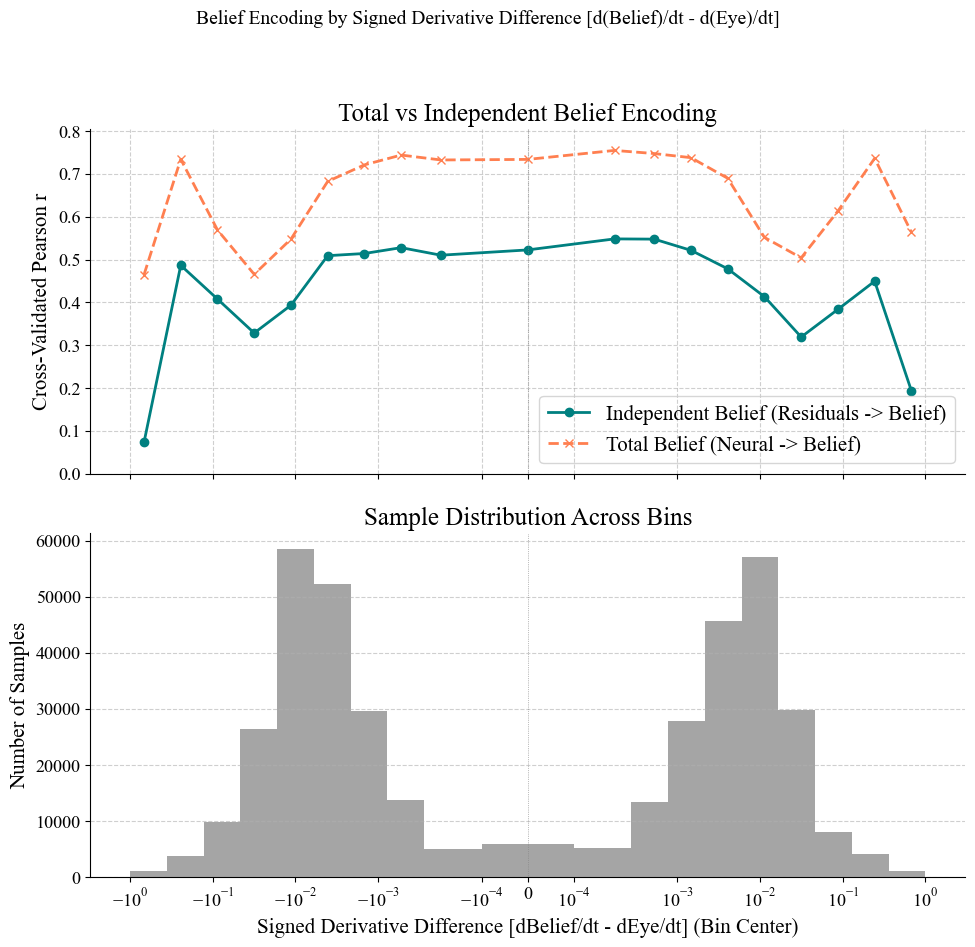


SIGNED Derivative Difference Binned Analysis (Symlog Bins) Complete.


In [103]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC', 'belief', and 'eye'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     # Try to load placeholder if actual data not found
     print("Warning: DataFrame 'timedf' not found. Using placeholder data.")
     # --- Placeholder Data (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
     rng = np.random.default_rng(42)
     n_samples_orig = 100000 # Use a decent number of samples
     n_features = 50      # Number of channels/neurons
     sampling_rate = 166 # Hz

     belief_signal_true = normalize_z(rng.random(n_samples_orig) * 10)
     eye_signal_true = normalize_z(rng.random(n_samples_orig) * 5)
     # Simulate varying correlation - let's make it random per sample for simplicity here
     correlation_factor = rng.uniform(0.1, 0.8, n_samples_orig)
     belief_signal_correlated = normalize_z( (1-correlation_factor) * belief_signal_true + correlation_factor * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     eye_signal_correlated = normalize_z( correlation_factor * belief_signal_true + (1-correlation_factor) * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))

     voltage_noise = rng.normal(0, 1.0, (n_samples_orig, n_features))
     belief_mod = belief_signal_correlated[:, np.newaxis] * 0.1
     eye_mod = eye_signal_correlated[:, np.newaxis] * 0.3
     neural_data_raw_voltage_sim = voltage_noise + belief_mod + eye_mod

     timedf = pd.DataFrame({
         'PPC': list(neural_data_raw_voltage_sim),
         'belief': belief_signal_correlated,
         'eye': eye_signal_correlated
         # No timeratio needed for this version
     })
     # --- End Placeholder Data ---
else:
    print("Using provided 'timedf' DataFrame.")


# --- Parameters ---
sampling_rate = 166 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers
gaussian_sigma_samples = 10 # Std deviation of Gaussian kernel in SAMPLES (using the value from the last run)
n_target_bins = 20 # Target number of bins for SIGNED derivative difference
min_samples_per_bin = 50 # Minimum samples required in a bin for analysis
deriv_diff_range_limit = 1.0 # Focus on range [-1, 1]
symlog_epsilon = 1e-4 # Small value defining the central linear region for binning

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
try:
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy())
    belief_data_present_raw = timedf['belief'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, Belief={belief_data_present_raw.shape}, Eye={eye_data_present_raw.shape}")

    if not (neural_data_raw_voltage.shape[0] == belief_data_present_raw.shape[0] == eye_data_present_raw.shape[0]):
        raise ValueError("Mismatch in number of samples between neural ('PPC'), belief, or eye data.")

except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'belief', 'eye' exist.")
except Exception as e:
    raise TypeError(f"Error processing data columns. Ensure they contain stackable numerical data. Error: {e}")


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    data = np.asarray(data) # Ensure numpy array
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0) # Replace NaN/Inf with 0 before scaling
    scaler = StandardScaler()
    if data.ndim == 1:
        if np.std(data) < 1e-9:
            # print("Warning: Standard deviation is zero during normalization. Returning zeros.") # Reduce verbosity
            return np.zeros_like(data)
        return scaler.fit_transform(data.reshape(-1, 1)).flatten()
    elif data.ndim == 0:
         return np.array([0.0])
    else:
        print(f"Warning: normalize_z received data with unexpected shape {data.shape}. Returning original data.")
        return data


# --- Normalize Behavioral Data Globally ---
print("\n--- Normalizing Behavioral Data (Globally) ---")
belief_data_normalized = normalize_z(belief_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)

# --- Outlier Removal (Based on Normalized Belief & Eye) ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev for Belief & Eye) ---")
task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized]).T
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

# Apply mask to all data types that need to stay aligned
neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
belief_data_present = belief_data_normalized[mask_outliers]
eye_data_present = eye_data_normalized[mask_outliers]

n_removed = len(belief_data_present_raw) - len(belief_data_present)
print(f"Removed {n_removed} outlier trials/samples ({n_removed / len(belief_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, Belief={belief_data_present.shape}, Eye={eye_data_present.shape}")

if len(belief_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")

# =============================================================================
# Calculate Derivatives and their SIGNED Difference
# =============================================================================
print("\n--- Calculating Derivatives and SIGNED Difference ---")
belief_deriv = np.gradient(belief_data_present)
eye_deriv = np.gradient(eye_data_present)
deriv_diff_signed_all = belief_deriv - eye_deriv
print(f"  Full range of SIGNED derivative difference: {np.min(deriv_diff_signed_all):.3f} to {np.max(deriv_diff_signed_all):.3f}")

# =============================================================================
# Filter Data based on Derivative Difference Range [-1, 1]
# =============================================================================
print(f"\n--- Filtering data for SIGNED derivative difference in range [{-deriv_diff_range_limit}, {deriv_diff_range_limit}] ---")
range_mask = (deriv_diff_signed_all >= -deriv_diff_range_limit) & (deriv_diff_signed_all <= deriv_diff_range_limit)

neural_data_raw_voltage_range = neural_data_raw_voltage_cleaned[range_mask, :]
belief_data_range = belief_data_present[range_mask]
eye_data_range = eye_data_present[range_mask]
deriv_diff_signed_range = deriv_diff_signed_all[range_mask]

n_range_removed = len(belief_data_present) - len(belief_data_range)
print(f"  Removed {n_range_removed} samples outside range ({n_range_removed / len(belief_data_present) * 100:.2f}% of cleaned data).")
print(f"Data shape after range filtering: Neural={neural_data_raw_voltage_range.shape}, Belief={belief_data_range.shape}, Eye={eye_data_range.shape}")

if len(belief_data_range) == 0:
    raise ValueError("All data removed after derivative difference range filtering. Check range limits.")


# =============================================================================
# Gaussian Smoothing of Range-Filtered Raw Voltage Data
# =============================================================================
print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---")
neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_range,
                                         sigma=gaussian_sigma_samples,
                                         axis=0,
                                         mode='reflect')
print("Gaussian smoothing complete.")

# =============================================================================
# Z-score Smoothed Data Per Channel Globally (using stats from range-filtered data)
# =============================================================================
print("Z-scoring smoothed data per channel...")
scaler_smooth = StandardScaler()
neural_data_processed = np.zeros_like(neural_data_smoothed)
for i in range(neural_data_smoothed.shape[1]):
    channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9:
        neural_data_processed[:, i] = scaler_smooth.fit_transform(channel_data).flatten()
    else:
        # print(f"Warning: Channel {i} has zero standard deviation after smoothing. Outputting zeros.") # Reduce verbosity
        pass
print("Z-scoring complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")


# =============================================================================
# SIGNED Derivative Difference Binned Analysis Comparison (Symlog Bins)
# =============================================================================
print(f"\n--- SIGNED Derivative Difference Binned Analysis Comparison ({n_target_bins} target bins using Symlog Spacing) ---")

# *** MODIFIED: Define bins using SYMMETRIC LOG spacing ***
n_pos_bins = (n_target_bins - 1) // 2 # Number of bins for positive side
n_neg_bins = n_pos_bins # Number of bins for negative side
n_bins_total_actual = 1 + n_pos_bins + n_neg_bins # Actual total bins

print(f"Creating {n_bins_total_actual} bins: {n_neg_bins} negative, 1 central, {n_pos_bins} positive.")

# Positive log-spaced bins (from epsilon to limit)
pos_edges = np.geomspace(symlog_epsilon, deriv_diff_range_limit, n_pos_bins + 1)
# Negative log-spaced bins (mirror of positive)
neg_edges = -np.flip(pos_edges) # Flip to go from -limit to -epsilon

# Combine edges: [-limit, ..., -eps, +eps, ..., +limit]
# Note the central gap between -eps and +eps
bin_edges = np.concatenate((neg_edges[:-1], [neg_edges[-1], pos_edges[0]], pos_edges[1:]))
# *** END MODIFIED SECTION ***

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# Manually set center for the middle bin [-eps, +eps]
bin_centers[n_neg_bins] = 0.0

results_r_independent = [] # Pearson r for Residuals -> Belief
results_r_total = []       # Pearson r for Neural -> Belief
actual_bin_centers = []    # Store centers only for bins with enough data
samples_in_bins = []       # Store sample count per bin

# Initialize the base model and CV strategy
lr_model = LinearRegression()
n_splits = 5 # CV folds within each bin

for i in range(n_bins_total_actual): # Use the actual number of bins created
    bin_start = bin_edges[i]
    bin_end = bin_edges[i+1]
    # Mask based on SIGNED derivative difference using the range-filtered data
    bin_mask = (deriv_diff_signed_range >= bin_start) & (deriv_diff_signed_range < bin_end)
    # Ensure the last bin includes the maximum value exactly
    if i == n_bins_total_actual - 1:
         bin_mask = (deriv_diff_signed_range >= bin_start) & (deriv_diff_signed_range <= bin_end)


    print(f"\nProcessing Bin {i+1}/{n_bins_total_actual} (Signed Deriv Diff: {bin_start:.3E} to {bin_end:.3E})...")

    # Select data for the current bin
    neural_bin = neural_data_processed[bin_mask]
    belief_bin = belief_data_range[bin_mask] # Use range-filtered data
    eye_bin = eye_data_range[bin_mask]       # Use range-filtered data
    n_samples_in_bin = len(belief_bin)
    samples_in_bins.append(n_samples_in_bin)
    print(f"  Samples in bin: {n_samples_in_bin}")

    # Check if enough samples for analysis and CV
    if n_samples_in_bin < max(min_samples_per_bin, n_splits):
        print(f"  Skipping bin {i+1} due to insufficient samples (required: {max(min_samples_per_bin, n_splits)}).")
        results_r_independent.append(np.nan)
        results_r_total.append(np.nan)
        continue # Skip to next bin

    # --- Perform CV analyses within the bin ---
    eye_bin_2d = eye_bin.reshape(-1, 1)

    # Adjust n_splits if samples < 5 but >= 2
    current_n_splits = n_splits
    if n_samples_in_bin < current_n_splits:
        current_n_splits = max(2, n_samples_in_bin)
        # print(f"  Adjusting CV folds to {current_n_splits} for this bin.")
    cv_bin = KFold(n_splits=current_n_splits, shuffle=True, random_state=42)

    # --- 1. Total Belief Encoding (Neural -> Belief) ---
    # print("  Calculating Total Belief Encoding (Neural -> Belief)...")
    r_total_bin = np.nan # Default to NaN
    try:
        predicted_belief_total_cv_bin = cross_val_predict(lr_model, neural_bin, belief_bin, cv=cv_bin)
        valid_indices_total = np.isfinite(belief_bin) & np.isfinite(predicted_belief_total_cv_bin)
        if np.sum(valid_indices_total) >= 2:
            r_total_bin, _ = pearsonr(belief_bin[valid_indices_total], predicted_belief_total_cv_bin[valid_indices_total])
    except ValueError: pass
    print(f"    CV Pearson r (Total): {r_total_bin:.4f}")
    results_r_total.append(r_total_bin)


    # --- 2. Independent Belief Encoding (Residuals -> Belief) ---
    # print("  Calculating Independent Belief Encoding (Residuals -> Belief)...")
    r_independent_bin = np.nan # Default to NaN
    try:
        predicted_neural_from_eye_cv_bin = cross_val_predict(lr_model, eye_bin_2d, neural_bin, cv=cv_bin)
        residuals_bin = neural_bin - predicted_neural_from_eye_cv_bin
        predicted_belief_independent_cv_bin = cross_val_predict(lr_model, residuals_bin, belief_bin, cv=cv_bin)
        valid_indices_independent = np.isfinite(belief_bin) & np.isfinite(predicted_belief_independent_cv_bin)
        if np.sum(valid_indices_independent) >= 2:
            r_independent_bin, _ = pearsonr(belief_bin[valid_indices_independent], predicted_belief_independent_cv_bin[valid_indices_independent])
    except ValueError: pass
    print(f"    CV Pearson r (Independent): {r_independent_bin:.4f}")
    results_r_independent.append(r_independent_bin)

    # Store bin center only if both calculations were successful (not NaN)
    if not np.isnan(r_total_bin) and not np.isnan(r_independent_bin):
        actual_bin_centers.append(bin_centers[i])
    else:
        # Ensure consistency if one failed
        if np.isnan(r_total_bin) and not np.isnan(r_independent_bin): results_r_independent[-1] = np.nan
        if not np.isnan(r_total_bin) and np.isnan(r_independent_bin): results_r_total[-1] = np.nan


# =============================================================================
# Plotting the SIGNED Derivative Difference Binned Comparison (Separate Plots)
# =============================================================================
print("\n--- Plotting SIGNED Derivative Difference Binned Comparison (Separate Plots - Symlog Bins) ---")
# Create figure with 2 subplots, sharing the x-axis
fig_signed_derivdiff_sep, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
fig_signed_derivdiff_sep.suptitle('Belief Encoding by Signed Derivative Difference [d(Belief)/dt - d(Eye)/dt]', fontsize=14)

# --- Plot 1: Correlation Curves ---
ax_corr = axes[0]

# Filter out NaN results from skipped or failed bins for plotting
plot_centers = np.array(actual_bin_centers)
# Filter results based on actual_bin_centers length, assuming NaNs were handled correctly when appending
plot_r_independent = np.array(results_r_independent)[~np.isnan(results_r_independent)]
plot_r_total = np.array(results_r_total)[~np.isnan(results_r_total)]

# Ensure lengths match after filtering potential NaNs from calculation errors
min_len = min(len(plot_centers), len(plot_r_independent), len(plot_r_total))
plot_centers = plot_centers[:min_len]
plot_r_independent = plot_r_independent[:min_len]
plot_r_total = plot_r_total[:min_len]


if len(plot_centers) > 0:
    # Plot Independent Belief Encoding (Residuals -> Belief)
    ax_corr.plot(plot_centers, plot_r_independent, marker='o', linestyle='-', color='teal', label='Independent Belief (Residuals -> Belief)')
    # Plot Total Belief Encoding (Neural -> Belief)
    ax_corr.plot(plot_centers, plot_r_total, marker='x', linestyle='--', color='coral', label='Total Belief (Neural -> Belief)')

    ax_corr.set_ylabel('Cross-Validated Pearson r')
    ax_corr.set_title('Total vs Independent Belief Encoding')
    # Adjust y-limits based on the range of both plots
    min_y = min(0, np.nanmin(plot_r_independent) - 0.05, np.nanmin(plot_r_total) - 0.05) if len(plot_r_independent)>0 and len(plot_r_total)>0 else 0
    max_y = max(0.1, np.nanmax(plot_r_independent) + 0.05, np.nanmax(plot_r_total) + 0.05) if len(plot_r_independent)>0 and len(plot_r_total)>0 else 0.1
    ax_corr.set_ylim(bottom=min_y, top=max_y)
    ax_corr.grid(True, linestyle='--', alpha=0.6)
    ax_corr.axhline(0, color='black', linewidth=0.5, linestyle='--') # Line at y=0
    ax_corr.axvline(0, color='gray', linewidth=0.5, linestyle=':') # Line at x=0
    ax_corr.legend()
    # *** Use symlog scale on x-axis ***
    ax_corr.set_xscale('symlog', linthresh=symlog_epsilon*2) # Set linear threshold slightly larger than epsilon


else:
    ax_corr.text(0.5, 0.5, 'No valid data bins found for plotting correlations.',
                    horizontalalignment='center', verticalalignment='center', transform=ax_corr.transAxes)
    ax_corr.set_ylabel('Cross-Validated Pearson r')
    ax_corr.set_title('Total vs Independent Belief Encoding')


# --- Plot 2: Sample Count Histogram ---
ax_hist = axes[1]

if len(samples_in_bins) > 0:
    # Use bin_edges for accurate bar placement with potentially uneven bins
    bar_widths = bin_edges[1:] - bin_edges[:-1]
    ax_hist.bar(bin_centers, samples_in_bins, width=bar_widths, color='gray', alpha=0.7, align='center') # Width based on bin edges
    ax_hist.set_xlabel('Signed Derivative Difference [dBelief/dt - dEye/dt] (Bin Center)')
    ax_hist.set_ylabel('Number of Samples')
    ax_hist.set_title('Sample Distribution Across Bins')
    ax_hist.set_ylim(bottom=0)
    ax_hist.grid(True, axis='y', linestyle='--', alpha=0.6)
    ax_hist.axvline(0, color='gray', linewidth=0.5, linestyle=':') # Line at x=0
    # *** Use symlog scale on x-axis ***
    ax_hist.set_xscale('symlog', linthresh=symlog_epsilon*2)


else:
     ax_hist.text(0.5, 0.5, 'No bins processed.',
                    horizontalalignment='center', verticalalignment='center', transform=ax_hist.transAxes)
     ax_hist.set_xlabel('Signed Derivative Difference [dBelief/dt - dEye/dt] (Bin Center)')
     ax_hist.set_ylabel('Number of Samples')
     ax_hist.set_title('Sample Distribution Across Bins')


plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout
plt.show()

print("\nSIGNED Derivative Difference Binned Analysis (Symlog Bins) Complete.")
